In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
!pip install kagglehub

import kagglehub
swaptr_fifa_wc_2026_players_path = kagglehub.dataset_download('swaptr/fifa-wc-2026-players')
swaptr_fifa_wc_2026_teams_path = kagglehub.dataset_download('swaptr/fifa-wc-2026-teams')
swaptr_fifa_wc_2026_matches_path = kagglehub.dataset_download('swaptr/fifa-wc-2026-matches')

print('Data source import complete.')


/home/yisusxd/uni/KDBE_9B_IDGS_PRACTICES_220076/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source import complete.


In [4]:
# Diccionario para traducir nombres de selecciones únicamente en las visualizaciones
traduccion_equipos = {
    "Canada": "Canadá",
    "Mexico": "México",
    "United States": "Estados Unidos",
    "Curacao": "Curazao",
    "Haiti": "Haití",
    "Panama": "Panamá",

    "Argentina": "Argentina",
    "Brazil": "Brasil",
    "Colombia": "Colombia",
    "Ecuador": "Ecuador",
    "Paraguay": "Paraguay",
    "Uruguay": "Uruguay",

    "Austria": "Austria",
    "Belgium": "Bélgica",
    "Bosnia and Herzegovina": "Bosnia y Herzegovina",
    "Croatia": "Croacia",
    "Czechia": "Chequia",
    "Czech Republic": "Chequia",
    "England": "Inglaterra",
    "France": "Francia",
    "Germany": "Alemania",
    "Netherlands": "Países Bajos",
    "Norway": "Noruega",
    "Portugal": "Portugal",
    "Scotland": "Escocia",
    "Spain": "España",
    "Sweden": "Suecia",
    "Switzerland": "Suiza",
    "Turkey": "Turquía",
    "Türkiye": "Turquía",

    "Algeria": "Argelia",
    "Cape Verde": "Cabo Verde",
    "DR Congo": "República Democrática del Congo",
    "Democratic Republic of the Congo": "República Democrática del Congo",
    "Ivory Coast": "Costa de Marfil",
    "Cote d'Ivoire": "Costa de Marfil",
    "Côte d'Ivoire": "Costa de Marfil",
    "Egypt": "Egipto",
    "Ghana": "Ghana",
    "Morocco": "Marruecos",
    "Senegal": "Senegal",
    "South Africa": "Sudáfrica",
    "Tunisia": "Túnez",

    "Australia": "Australia",
    "Iran": "Irán",
    "Japan": "Japón",
    "Jordan": "Jordania",
    "South Korea": "Corea del Sur",
    "Korea Republic": "Corea del Sur",
    "Republic of Korea": "Corea del Sur",
    "Qatar": "Catar",
    "Saudi Arabia": "Arabia Saudita",
    "Uzbekistan": "Uzbekistán",
    "Iraq": "Irak",

    "New Zealand": "Nueva Zelanda",
}

# **Copa Mundial de la FIFA 2026: Análisis Exploratorio de Datos**

La primera Copa Mundial con **48 selecciones** y la primera organizada por **tres países** (Estados Unidos, Canadá y México) comenzó el **11 de junio de 2026** en el renovado **Estadio Azteca** (actualmente con el nombre comercial **Estadio Banorte**). Este cuaderno realiza un seguimiento del torneo a medida que avanza: en cada ejecución vuelve a cargar las tablas de partidos, equipos y jugadores, y recalcula todas las métricas y visualizaciones a partir de los datos, garantizando que el análisis se mantenga actualizado desde la fase inicial hasta la final.

El análisis se basa en tres tablas principales:

* **`matches`**: contiene un registro por cada partido disputado, incluyendo marcador, posesión del balón, tiros, tarjetas, faltas, jugadas a balón parado, formaciones, entrenadores, capitanes, estadio, árbitro y asistencia. Los encuentros programados que aún no se han jugado aparecen con estadísticas vacías y se excluyen automáticamente de las gráficas basadas en resultados.
* **`teams`**: contiene un registro por cada selección nacional, con estadísticas acumuladas siguiendo el formato de **FBref**, además de un conjunto de métricas del rival (identificadas con el sufijo **`_against`**) para cada estadística.
* **`players`**: contiene un registro por cada jugador, con estadísticas individuales estándar. Los porteros incluyen un bloque específico de métricas identificado con el prefijo **`gk_*`**.

**Nota sobre la procedencia de los datos:** El esquema de la base de datos sigue las convenciones de **FBref** (Opta / Stats Perform). No incluye métricas avanzadas como **goles esperados (xG)** ni **pases progresivos**, ya que estas estadísticas dejaron de estar disponibles en FBref a partir de **enero de 2026**. Por ello, el conjunto de datos se limita a estadísticas básicas de conteo. Durante las primeras jornadas del torneo, cuando cada selección ha disputado solo uno o dos partidos, las tasas y métricas **por 90 minutos (per90)** deben interpretarse como indicios preliminares y no como tendencias definitivas.


## 1. ¿Por qué este conjunto de datos?

Una Copa Mundial concentra en apenas un mes toda la narrativa que normalmente se desarrolla a lo largo de una temporada: selecciones anfitrionas bajo presión, equipos debutantes que buscan sorprender y planteamientos tácticos enfrentándose a la realidad del campo. Gracias a la información detallada sobre **posesión del balón, remates, disciplina, jugadas a balón parado y rendimiento de los porteros** para cada selección, además de las estadísticas completas de cada jugador, este conjunto de datos permite responder preguntas concretas, tales como:

* ¿La posesión del balón se traduce en más goles?
* ¿Qué jugadores son más eficientes al momento de definir?
* ¿Qué porteros soportan una mayor carga de trabajo?
* ¿Qué tan profunda es la rotación de las plantillas?
* ¿Qué selecciones presentan estilos de juego similares?

Además, como el conjunto de datos **se actualiza diariamente**, estas mismas preguntas pueden volver a analizarse conforme aumenta la cantidad de información disponible, pasando de la primera jornada hasta la conclusión del torneo.

Durante las primeras fases del campeonato, cuando aún se han disputado pocos encuentros, resulta especialmente interesante observar la diferencia entre el **dominio mostrado en el juego** y los **resultados obtenidos**, ya que esa brecha suele ser más evidente con muestras de datos reducidas.


## **2. Setup**

In [5]:
%pip install numpy pandas matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.


In [6]:
import warnings; warnings.filterwarnings("ignore")
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

sns.set_theme(style="whitegrid", context="notebook")
pio.templates.default = "plotly_white"
pio.renderers.default = "notebook_connected"   # load plotly.js from a CDN so figures render in the published notebook
PLOTLY_KW = dict(template="plotly_white")

DATA_DIR = "dataset"
def _find(fname):
    bases = [DATA_DIR, "dataset", "."] + sorted(glob.glob("/kaggle/input/*"))
    for b in bases:
        hits = glob.glob(os.path.join(b, "**", fname), recursive=True)
        if hits:
            return sorted(hits, key=len)[0]
    raise FileNotFoundError(f"{fname} not found. Set DATA_DIR to the folder holding matches/players/teams.")
MATCHES_PATH, PLAYERS_PATH, TEAMS_PATH = _find("matches.csv"), _find("players.csv"), _find("teams.csv")

matches = pd.read_csv(MATCHES_PATH)
players = pd.read_csv(PLAYERS_PATH)
teams   = pd.read_csv(TEAMS_PATH)

# --- Numeric coercion. The feed is refreshed daily and adds upcoming fixtures
#     with blank stats, so never assume a column is fully populated. ---
def _num(s):
    """Coerce a possibly comma-grouped / blank string column to float; blanks -> NaN."""
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False).str.replace("–", "-", regex=False),
        errors="coerce")

for c in ["home_score", "away_score"]:
    if c in matches:
        matches[c] = _num(matches[c])
matches["attendance_n"] = _num(matches["attendance"]) if "attendance" in matches else np.nan
# A fixture is "played" once both scores are present. Result-based charts use this subset.
matches["is_played"] = matches["home_score"].notna() & matches["away_score"].notna()
played_matches = matches[matches["is_played"]].copy()

# --- Derived player fields ---
def parse_age(a):
    """FBref stores age as 'YY-DDD' (years-days). Return float years."""
    if pd.isna(a): return np.nan
    s = str(a)
    if "-" in s:
        y, d = s.split("-"); return int(y) + int(d) / 365.0
    try: return float(s)
    except ValueError: return np.nan
players["age_years"] = players["age"].map(parse_age)
players["pos_main"]  = players["position"].str.split(",").str[0]            # primary position token
players["played"]    = players["games"].fillna(0) > 0                       # featured in any match so far
players["young_player_eligible"] = players["birth_year"] >= 2005            # FIFA Young Player Award: born >= 1 Jan 2005
played = players[players["played"]].copy()                                  # players who have appeared
gks    = players[players["gk_minutes"].notna()].copy()                      # goalkeepers with minutes

# Captains, read off the match sheets (blanks from unplayed fixtures dropped)
CAPTAINS = set(matches["home_captain"].dropna()) | set(matches["away_captain"].dropna())
players["is_captain"] = players["player"].isin(CAPTAINS)

# --- Stable team colours, derived from the teams file so new teams auto-colour ---
TEAM_ORDER = sorted(teams["team"].dropna().unique())
_pal = px.colors.qualitative.Dark24 + px.colors.qualitative.Light24   # 48 distinct hues
TEAM_COLOR = {t: _pal[i % len(_pal)] for i, t in enumerate(TEAM_ORDER)}

# --- Group draw (reference map). Lookups are TOLERANT: a team missing from the
#     map resolves to "?" and drops out of group-only views, so the notebook
#     never crashes as the squad list grows toward all 48 teams. Extend GROUP
#     with the official draw when you have it. ---
GROUP = {
    "Mexico": "A", "South Africa": "A", "Korea Republic": "A", "Czechia": "A",
    "Canada": "B", "Switzerland": "B", "Qatar": "B", "Bosnia-Herzegovina": "B",
    "Brazil": "C", "Morocco": "C", "Haiti": "C", "Scotland": "C",
    "United States": "D", "Paraguay": "D", "Australia": "D", "Türkiye": "D",
}
def group_of(team):
    return GROUP.get(team, "?")
teams["group"]   = teams["team"].map(group_of)
players["group"] = players["team"].map(group_of)
GROUP_ORDER = sorted(g for g in teams["group"].unique() if g != "?")
_ungrouped = sorted(set(teams["team"]) - set(GROUP))
if _ungrouped:
    print(
        f"Nota: {len(_ungrouped)} selección(es) no están en el mapa de grupos "
        f"(se excluirán de las visualizaciones por grupos):\n"
        + ", ".join(_ungrouped)
    )

# --- Host-city coordinates for the venue map. TOLERANT lookup: an unmapped city
#     yields (nan, nan) and is simply dropped from the map instead of raising a
#     KeyError. Covers all 16 FIFA WC 2026 host cities so the map stays complete
#     as the schedule moves between venues. ---
CITY_GEO = {
    # Mexico
    "Coyoacán": (19.350, -99.162), "Zapopan": (20.681, -103.462),
    "Guadalupe": (25.669, -100.244), "Monterrey": (25.686, -100.316),
    "Mexico City": (19.433, -99.133), "Guadalajara": (20.659, -103.349),
    # Canada
    "Toronto": (43.633, -79.418), "Vancouver": (49.277, -123.112),
    # United States
    "Inglewood": (33.953, -118.339), "Los Angeles": (34.052, -118.244),
    "Santa Clara": (37.403, -121.970), "East Rutherford": (40.814, -74.074),
    "Foxborough": (42.091, -71.264), "Atlanta": (33.755, -84.401),
    "Arlington": (32.747, -97.094), "Dallas": (32.777, -96.797),
    "Houston": (29.685, -95.411), "Kansas City": (39.049, -94.484),
    "Miami Gardens": (25.958, -80.239), "Miami": (25.762, -80.192),
    "Philadelphia": (39.901, -75.168), "Seattle": (47.595, -122.332),
}
def city_latlon(city):
    """Return (lat, lon) for a venue city, or (nan, nan) if unmapped. Never raises."""
    return CITY_GEO.get(city, (np.nan, np.nan))

# --- One row per team-per-match, built from the wide match table.
#     Only played fixtures contribute, and stats are read with .get so a missing
#     column degrades to NaN rather than a KeyError. ---
def matches_long(m):
    rows = []
    for _, r in m[m["is_played"]].iterrows():
        for side, opp in [("home", "away"), ("away", "home")]:
            d = {"team": r[f"{side}_team"], "opponent": r[f"{opp}_team"], "side": side,
                 "gf": int(r[f"{side}_score"]), "ga": int(r[f"{opp}_score"])}
            for st in ["possession", "sot", "total_shots", "saves", "cards_yellow",
                       "cards_red", "fouls", "corners", "crosses", "interceptions", "offsides"]:
                d[st] = r.get(f"{side}_{st}", np.nan)
            d["result"] = "W" if d["gf"] > d["ga"] else "L" if d["gf"] < d["ga"] else "D"
            d["points"] = 3 if d["result"] == "W" else 1 if d["result"] == "D" else 0
            d["attendance"] = r.get("attendance_n", np.nan)
            d["venue"] = r.get("venue"); d["referee"] = r.get("referee"); d["date"] = r.get("date")
            d["round"] = r.get("round"); d["gameweek"] = r.get("gameweek")
            rows.append(d)
    cols = ["team", "opponent", "side", "gf", "ga", "possession", "sot", "total_shots",
            "saves", "cards_yellow", "cards_red", "fouls", "corners", "crosses",
            "interceptions", "offsides", "result", "points", "attendance", "venue",
            "referee", "date", "round", "gameweek"]
    return pd.DataFrame(rows, columns=cols)   # typed-empty when no match is played yet
team_match = matches_long(matches)
team_match["group"] = team_match["team"].map(group_of)

# --- One row per team, aggregated across every match played so far. Correct
#     whether a team has 1 game or many, so downstream joins never assume a
#     single match per team. ---
def aggregate_team_match(tmf):
    cols = ["team", "P", "W", "D", "L", "points", "gf", "ga", "gd", "group"]
    if tmf.empty:
        return pd.DataFrame(columns=cols)
    g = (tmf.assign(W=lambda d: (d["result"] == "W").astype(int),
                    D=lambda d: (d["result"] == "D").astype(int),
                    L=lambda d: (d["result"] == "L").astype(int))
            .groupby("team")
            .agg(P=("result", "size"), W=("W", "sum"), D=("D", "sum"), L=("L", "sum"),
                 points=("points", "sum"), gf=("gf", "sum"), ga=("ga", "sum"))
            .reset_index())
    g["gd"] = g["gf"] - g["ga"]
    g["group"] = g["team"].map(group_of)
    return g[["team", "P", "W", "D", "L", "points", "gf", "ga", "gd", "group"]]
team_agg = aggregate_team_match(team_match)

# --- Dynamic scope counts. Titles below interpolate these so the notebook
#     re-labels itself automatically on every daily refresh. ---
N_MATCHES_TOTAL  = int(matches.shape[0])
N_MATCHES_PLAYED = int(played_matches.shape[0])
N_TEAMS   = int(teams.shape[0])
N_PLAYERS = int(players.shape[0])
N_PLAYED  = int(played.shape[0])
N_GK      = int(gks.shape[0])
N_TEAM_MATCH = int(team_match.shape[0])
ROUNDS = [r for r in played_matches["round"].dropna().unique()] if "round" in played_matches else []
MAX_GAMES = int(team_agg["P"].max()) if not team_agg.empty else 0
SCOPE = f"{N_MATCHES_PLAYED} matches played"   # short slice label reused in chart titles

# Traducción de las rondas
ROUND_TRANSLATIONS = {
    "Group stage": "Fase de grupos",
    "Round of 32": "Dieciseisavos de final",
    "Round of 16": "Octavos de final",
    "Quarter-finals": "Cuartos de final",
    "Semi-finals": "Semifinales",
    "Third-place match": "Partido por el tercer lugar",
    "Final": "Final"
}

ROUNDS_ES = [ROUND_TRANSLATIONS.get(r, r) for r in ROUNDS]

print(
    f"Partidos: {matches.shape} "
    f"({N_MATCHES_PLAYED} disputados, {N_MATCHES_TOTAL - N_MATCHES_PLAYED} programados) | "
    f"Jugadores: {players.shape} | Selecciones: {teams.shape}"
)

print(
    f"{N_PLAYED} jugadores han participado, "
    f"{N_GK} porteros, "
    f"{N_TEAM_MATCH} registros equipo-partido, "
    f"hasta {MAX_GAMES} partido(s) por selección"
)

print(
    "Rondas disputadas hasta el momento:",
    ", ".join(ROUNDS_ES) if ROUNDS_ES else "Ninguna"
)

Nota: 33 selección(es) no están en el mapa de grupos (se excluirán de las visualizaciones por grupos):
Algeria, Argentina, Austria, Belgium, Bosnia–Herz, Cabo Verde, Colombia, Congo DR, Croatia, Curaçao, Côte d'Ivoire, Ecuador, Egypt, England, France, Germany, Ghana, IR Iran, Iraq, Japan, Jordan, Netherlands, New Zealand, Norway, Panama, Portugal, Saudi Arabia, Senegal, Spain, Sweden, Tunisia, Uruguay, Uzbekistan
Partidos: (104, 44) (100 disputados, 4 programados) | Jugadores: (1248, 78) | Selecciones: (48, 137)
1039 jugadores han participado, 62 porteros, 200 registros equipo-partido, hasta 8 partido(s) por selección
Rondas disputadas hasta el momento: Fase de grupos, Dieciseisavos de final, Octavos de final, Cuartos de final, Semifinales, Partido por el tercer lugar, Final


## **3. Carga y vista previa de los datos**

El conjunto de datos está compuesto por **tres tablas**, cada una con un nivel de detalle diferente. La tabla **`matches`** es una tabla amplia que contiene **un registro por cada partido**; la tabla **`players`** corresponde al **plantel de jugadores**, con **un registro por cada futbolista**; y la tabla **`teams`** reúne las **estadísticas agregadas de cada selección**.

Como primer paso, observa las **dimensiones (shape)** de cada tabla para conocer la cantidad de registros y columnas disponibles. Posteriormente, utiliza el método **`head()`** para visualizar las primeras filas de cada conjunto de datos y notar cómo cada tabla ofrece una perspectiva distinta sobre el mismo torneo y los mismos encuentros.


In [7]:
print("=== Dimensiones de las tres tablas principales ===")

shape_tbl = pd.DataFrame(
    {
        "Filas": [matches.shape[0], players.shape[0], teams.shape[0]],
        "Columnas": [matches.shape[1], players.shape[1], teams.shape[1]],
        "Nivel de detalle": [
            "Un registro por partido",
            "Un registro por jugador",
            "Un registro por selección",
        ],
    },
    index=["Partidos", "Jugadores", "Selecciones"],
)

display(shape_tbl)

print("--- Primeras filas de la tabla de partidos ---")
display(
    matches[
        [
            "date",
            "home_team",
            "away_team",
            "score",
            "venue",
            "attendance_n",
        ]
    ]
    .rename(
        columns={
            "date": "Fecha",
            "home_team": "Selección local",
            "away_team": "Selección visitante",
            "score": "Marcador",
            "venue": "Estadio",
            "attendance_n": "Asistencia",
        }
    )
    .head()
)

print("--- Primeras filas de la tabla de jugadores ---")
display(
    players[
        [
            "player",
            "team",
            "pos_main",
            "age_years",
            "minutes",
            "goals",
            "played",
        ]
    ]
    .rename(
        columns={
            "player": "Jugador",
            "team": "Selección",
            "pos_main": "Posición",
            "age_years": "Edad",
            "minutes": "Minutos",
            "goals": "Goles",
            "played": "Participó",
        }
    )
    .head()
)

print("--- Primeras filas de la tabla de selecciones ---")
display(
    teams[
        [
            "team",
            "group",
            "players_used",
            "possession",
            "goals",
            "goals_against",
            "points_per_game",
        ]
    ]
    .rename(
        columns={
            "team": "Selección",
            "group": "Grupo",
            "players_used": "Jugadores utilizados",
            "possession": "Posesión (%)",
            "goals": "Goles a favor",
            "goals_against": "Goles en contra",
            "points_per_game": "Puntos por partido",
        }
    )
    .head()
)

=== Dimensiones de las tres tablas principales ===


,Filas,Columnas,Nivel de detalle
Partidos,104,44,Un registro por partido
Jugadores,1248,78,Un registro por jugador
Selecciones,48,137,Un registro por selección


--- Primeras filas de la tabla de partidos ---


,Fecha,Selección local,Selección visitante,Marcador,Estadio,Asistencia
0,2026-06-11,Mexico,South Africa,2–0,"Estadio Banorte, Coyoacán",80824
1,2026-06-11,Korea Republic,Czechia,2–1,"Estadio Akron, Zapopan",44985
2,2026-06-12,Canada,Bosnia–Herz,1–1,"BMO Field, Toronto",43002
3,2026-06-12,United States,Paraguay,4–1,"SoFi Stadium, Inglewood",70492
4,2026-06-13,Qatar,Switzerland,1–1,"Levi's Stadium, Santa Clara",67966


--- Primeras filas de la tabla de jugadores ---


,Jugador,Selección,Posición,Edad,Minutos,Goles,Participó
0,Achref Abada,Algeria,DF,26.0,NaN,NaN,False
1,Adil Boulbina,Algeria,FW,23.0,19.0,0.0,True
2,Amine Gouiri,Algeria,FW,26.0,251.0,1.0,True
3,Anis Hadj Moussa,Algeria,MF,24.0,98.0,0.0,True
4,Aïssa Mandi,Algeria,DF,34.0,360.0,0.0,True


--- Primeras filas de la tabla de selecciones ---


,Selección,Grupo,Jugadores utilizados,Posesión (%),Goles a favor,Goles en contra,Puntos por partido
0,Algeria,?,22,61.0,5,9,1.00
1,Argentina,?,24,57.6,18,8,2.63
2,Australia,D,23,41.0,2,2,1.25
3,Austria,?,20,45.0,5,9,1.00
4,Belgium,?,23,51.2,13,7,1.83


## **4. Esquema y tipos de datos**

En esta sección se presenta, para cada tabla, el **esquema completo de sus columnas**, incluyendo el **tipo de dato (dtype)**, la **cantidad de valores no nulos** y el **número de valores distintos (únicos)**.

La tabla **`teams`** es la más extensa del conjunto de datos, por lo que se divide en **tres bloques** para facilitar su análisis:

* **Estadísticas propias de cada selección.**
* **Estadísticas del equipo rival** (columnas con el sufijo **`_against`**).
* **Estadísticas de los porteros**.

Presta especial atención a la columna **`n_unique`** (número de valores únicos), ya que permite identificar aquellas variables que **no presentan variación** y, por tanto, podrían aportar poca información para el análisis exploratorio o para la construcción de modelos posteriores.


In [8]:
def tabla_esquema(df):
    return pd.DataFrame({
        "Tipo de dato": df.dtypes.astype(str),
        "Valores no nulos": df.notna().sum(),
        "Valores únicos": df.nunique(dropna=True),
    })

print(f"=== Esquema de la tabla de partidos ({matches.shape[1]} columnas) ===")
display(tabla_esquema(matches))

print(f"=== Esquema de la tabla de jugadores ({players.shape[1]} columnas) ===")
display(tabla_esquema(players))

# La tabla de selecciones es la más amplia, por lo que se divide en bloques
tcols = list(teams.columns)

against = [c for c in tcols if c.endswith("_against")]
gk = [c for c in tcols if c.startswith("gk_") and c not in against]
base = [c for c in tcols if c not in against and c not in gk]

teams_schema = tabla_esquema(teams)

teams_schema["Bloque"] = np.where(
    teams_schema.index.isin(against),
    "Estadísticas del rival",
    np.where(
        teams_schema.index.isin(gk),
        "Portería",
        "Estadísticas de la selección"
    )
)

print(f"=== Esquema de la tabla de selecciones ({teams.shape[1]} columnas) ===")

print("Tamaño de cada bloque:")
print(teams_schema["Bloque"].value_counts().to_dict())

print("--- Bloque: Estadísticas de la selección ---")
display(
    teams_schema[
        teams_schema["Bloque"] == "Estadísticas de la selección"
    ].drop(columns="Bloque")
)

=== Esquema de la tabla de partidos (44 columnas) ===


,Tipo de dato,Valores no nulos,Valores únicos
round,str,104,7
gameweek,float64,72,3
dayofweek,str,104,7
date,str,104,34
start_time,str,104,14
home_team,str,104,48
away_team,str,104,48
score,str,104,31
home_score,float64,100,8
away_score,float64,100,7


=== Esquema de la tabla de jugadores (78 columnas) ===


,Tipo de dato,Valores no nulos,Valores únicos
player,str,1248,1247
team,str,1248,48
team_country,str,1248,48
position,str,1248,9
age,int64,1248,26
...,...,...,...
pos_main,object,1248,4
played,bool,1248,2
young_player_eligible,bool,1248,2
is_captain,bool,1248,2


=== Esquema de la tabla de selecciones (137 columnas) ===
Tamaño de cada bloque:
{'Estadísticas del rival': 70, 'Estadísticas de la selección': 51, 'Portería': 16}
--- Bloque: Estadísticas de la selección ---


,Tipo de dato,Valores no nulos,Valores únicos
team,str,48,48
team_country,str,48,48
players_used,int64,48,9
avg_age,float64,48,34
possession,float64,48,42
games,int64,48,5
games_starts,int64,48,5
minutes,int64,48,10
minutes_90s,float64,48,10
goals,int64,48,16


## 5. Resumen de valores faltantes

Proporción de valores nulos por columna, comparando lado a lado los conjuntos de datos de jugadores (players) y equipos (teams).

Estos valores faltantes son **estructurales**, no aleatorios: las columnas relacionadas con penales se registran con poca frecuencia, y el bloque de estadísticas de portería (goalkeeping) aparece mayormente vacío porque normalmente solo un jugador por equipo desempeña el rol de portero. En este caso, hay pocos indicios de que los datos estén sucios o sean de mala calidad.

In [9]:
# Install/upgrade (only needed once)
%pip install -U nbformat

import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Render Plotly figures correctly in VS Code
pio.renderers.default = "vscode"

# -----------------------------------------------------------------------------
# Translation dictionary
# -----------------------------------------------------------------------------
COLUMN_TRANSLATIONS = {
    # Goalkeeping
    "gk_games": "Partidos del portero",
    "gk_games_starts": "Titularidades del portero",
    "gk_minutes": "Minutos del portero",
    "gk_goals_against": "Goles recibidos",
    "gk_goals_against_per90": "Goles recibidos por 90 min",
    "gk_shots_on_target_against": "Tiros a puerta recibidos",
    "gk_saves": "Atajadas",
    "gk_save_pct": "% de atajadas",
    "gk_wins": "Victorias del portero",
    "gk_ties": "Empates del portero",
    "gk_losses": "Derrotas del portero",
    "gk_clean_sheets": "Porterías a cero",
    "gk_clean_sheets_pct": "% de porterías a cero",
    "gk_pens_att": "Penales enfrentados",
    "gk_pens_allowed": "Penales recibidos",
    "gk_pens_saved": "Penales atajados",
    "gk_pens_missed": "Penales fallados por el rival",
    "gk_pens_save_pct": "% de penales atajados",

    # Penalties
    "pens_won": "Penales ganados",
    "pens_conceded": "Penales concedidos",
    "pens_won_against": "Penales recibidos por el rival",
    "pens_conceded_against": "Penales concedidos al rival",

    # Goalkeeping (opponent)
    "gk_pens_att_against": "Penales enfrentados por el rival",
    "gk_pens_allowed_against": "Penales recibidos por el rival",
    "gk_pens_saved_against": "Penales atajados por el rival",
    "gk_pens_save_pct_against": "% de penales atajados por el rival",

    # Shooting
    "shots_on_target_pct": "% de tiros a puerta",
    "goals_per_shot": "Goles por disparo",
    "goals_per_shot_on_target": "Goles por tiro a puerta",

    # Minutes
    "minutes_per_start": "Minutos por titularidad",
    "minutes_per_sub": "Minutos por sustitución",
}

# -----------------------------------------------------------------------------
# Automatic translator for any remaining English labels
# -----------------------------------------------------------------------------
def translate_column(col):
    if col in COLUMN_TRANSLATIONS:
        return COLUMN_TRANSLATIONS[col]

    text = col

    replacements = [
        ("gk_", "Portero "),
        ("pens_", "Penales "),
        ("shots_on_target", "Tiros a puerta"),
        ("shots", "Tiros"),
        ("goals", "Goles"),
        ("minutes", "Minutos"),
        ("games_starts", "Titularidades"),
        ("games", "Partidos"),
        ("clean_sheets", "Porterías a cero"),
        ("save_pct", "% de atajadas"),
        ("saved", "Atajados"),
        ("allowed", "Recibidos"),
        ("against_per90", "del rival por 90 min"),
        ("against", "del rival"),
        ("per90", "por 90 min"),
        ("per_shot_on_target", "por tiro a puerta"),
        ("per_shot", "por disparo"),
        ("wins", "Victorias"),
        ("losses", "Derrotas"),
        ("ties", "Empates"),
        ("won", "Ganados"),
        ("conceded", "Concedidos"),
        ("att", "Intentados"),
        ("pct", "%"),
        ("_", " "),
    ]

    for eng, esp in replacements:
        text = text.replace(eng, esp)

    return text.strip().capitalize()

# -----------------------------------------------------------------------------
# Calculate null percentages
# -----------------------------------------------------------------------------
def null_pct(df):
    return df.isna().mean().mul(100).round(1)

pn = null_pct(players).sort_values(ascending=False)
pn = pn[pn > 0].head(25)
pn.index = [translate_column(c) for c in pn.index]

tn = null_pct(teams).sort_values(ascending=False)
tn = tn[tn > 0]
tn.index = [translate_column(c) for c in tn.index]

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------
fig = make_subplots(
    rows=1,
    cols=2,
    horizontal_spacing=0.22,
    subplot_titles=(
        "Jugadores: 25 columnas con mayor porcentaje de valores nulos",
        "Equipos: todas las columnas con valores nulos",
    ),
)

fig.add_trace(
    go.Bar(
        x=pn.values[::-1],
        y=pn.index[::-1],
        orientation="h",
        marker_color="#636EFA",
        name="Jugadores",
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Bar(
        x=tn.values[::-1],
        y=tn.index[::-1],
        orientation="h",
        marker_color="#EF553B",
        name="Equipos",
    ),
    row=1,
    col=2,
)

fig.update_xaxes(
    title_text="% de valores nulos",
    range=[0, 100],
    row=1,
    col=1,
)

fig.update_xaxes(
    title_text="% de valores nulos",
    range=[0, 100],
    row=1,
    col=2,
)

fig.update_layout(
    title="Porcentaje de valores nulos por columna: faltantes estructurales, no aleatorios",
    height=650,
    showlegend=False,
    **PLOTLY_KW,
)

fig.show()

Note: you may need to restart the kernel to use updated packages.


## 6. La estructura de los jugadores que no participaron

Muchos jugadores convocados no disputaron ningún partido (`games == 0`) y, por ello, casi todas sus estadísticas aparecen como valores nulos (`NaN`). Las barras apiladas muestran esta situación: aunque cada selección cuenta con una plantilla amplia, solo una parte de los jugadores participa en los encuentros. Por ello, antes de calcular métricas o tasas de rendimiento a nivel de jugador, es recomendable filtrar el conjunto de datos utilizando la variable `played`.

In [10]:
counts = (
    players.assign(
        estado=np.where(players["played"], "Participó", "No participó")
    )
    .groupby(["team", "estado"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Participó", "No participó"], fill_value=0)
)

counts = counts.reindex(counts.sum(axis=1).sort_values().index)

overall = players["played"].value_counts()

print(
    f"Total: {int(overall.get(True, 0))} participaron, "
    f"{int(overall.get(False, 0))} no participaron"
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        y=counts.index,
        x=counts["Participó"],
        orientation="h",
        name="Participó",
        marker_color="#2ca02c",
    )
)

fig.add_trace(
    go.Bar(
        y=counts.index,
        x=counts["No participó"],
        orientation="h",
        name="No participó",
        marker_color="#d62728",
    )
)

fig.update_layout(
    barmode="stack",
    title=f"Uso de la plantilla: {N_PLAYED} jugadores participaron, {N_PLAYERS - N_PLAYED} aún no han jugado",
    xaxis_title="Jugadores",
    yaxis_title="Selección",
    height=max(420, 24 * len(counts)),
    legend_title="Estado",
    **PLOTLY_KW,
)

fig.show()

Total: 1039 participaron, 209 no participaron


## 7. Verificación del procesamiento de la edad

FBref almacena la edad con el formato **YY-DDD**, el cual no es adecuado para realizar cálculos o análisis numéricos. El proceso de conversión transforma este formato en una edad expresada en años como valor decimal (`float`). La tabla compara ambos formatos en los casos extremos, mostrando a un portero de más de 40 años y a un adolescente, lo que permite apreciar el amplio rango de edades presente en el conjunto de datos.

In [11]:
aged = players.dropna(subset=["age_years"]).copy()

oldest = aged.nlargest(5, "age_years")[["player", "team", "pos_main", "age", "age_years"]]
youngest = aged.nsmallest(5, "age_years")[["player", "team", "pos_main", "age", "age_years"]]

extremes = pd.concat([oldest.assign(end="más antiguos"),
                      youngest.assign(end="más jóvenes")], ignore_index=True)

extremes["age_years"] = extremes["age_years"].round(2)

print("Cadena original 'YY-DDD' vs años calculados como número decimal:")

# Only for visualization, does not modify the dataframe
display(
    extremes[["end", "player", "team", "pos_main", "age", "age_years"]]
    .rename(columns={
        "end": "clasificación",
        "player": "jugador",
        "team": "equipo",
        "pos_main": "posición_principal",
        "age": "edad",
        "age_years": "edad_en_años"
    })
)

fig = px.histogram(
    aged,
    x="age_years",
    nbins=28,
    color_discrete_sequence=["#636EFA"]
)

o = oldest.iloc[0]
y = youngest.iloc[0]

fig.add_vline(
    x=o["age_years"],
    line_dash="dash",
    line_color="#d62728",
    annotation_text=f"{o['player']} {o['age_years']:.1f}",
    annotation_position="top left"
)

fig.add_vline(
    x=y["age_years"],
    line_dash="dash",
    line_color="#2ca02c",
    annotation_text=f"{y['player']} {y['age_years']:.1f}",
    annotation_position="top right"
)

fig.update_layout(
    title="Edad calculada en años, mostrando los dos extremos identificados",
    xaxis_title="edad (años, calculada desde YY-DDD)",
    yaxis_title="jugadores",
    **PLOTLY_KW
)

fig.show()

Cadena original 'YY-DDD' vs años calculados como número decimal:


,clasificación,jugador,equipo,posición_principal,edad,edad_en_años
0,más antiguos,Craig Gordon,Scotland,GK,43,43.0
1,más antiguos,Cristiano Ronaldo,Portugal,FW,41,41.0
2,más antiguos,Edin Džeko,Bosnia–Herz,FW,40,40.0
3,más antiguos,Vozinha,Cabo Verde,GK,40,40.0
4,más antiguos,Luka Modrić,Croatia,MF,40,40.0
5,más jóvenes,Gilberto Mora,Mexico,MF,17,17.0
6,más jóvenes,Lucas Herrington,Australia,DF,18,18.0
7,más jóvenes,Kerim Alajbegović,Bosnia–Herz,MF,18,18.0
8,más jóvenes,Mladen Jurkas,Bosnia–Herz,GK,18,18.0
9,más jóvenes,Hugo Sochůrek,Czechia,MF,18,18.0


## 8. Análisis de inflación de estadísticas por 90 minutos

Las métricas por 90 minutos se calculan dividiendo entre los minutos jugados, por lo que una breve aparición puede disparar sus valores. Un solo gol en pocos minutos puede representar cifras de dos dígitos. El gráfico de dispersión en relación con los minutos muestra que todos los puntos inflados se concentran en el extremo izquierdo. Es preferible utilizar totales o métricas por partido.

In [12]:
sub = played.dropna(subset=["minutes", "goals_per90"]).copy()
sub = sub[sub["goals_per90"] > 0]

fig = px.scatter(
    sub,
    x="minutes",
    y="goals_per90",
    hover_name="player",
    color="goals",
    color_continuous_scale="Reds",
    labels={
        "minutes": "minutos jugados",
        "goals_per90": "goles por 90 minutos"
    }
)

worst = sub.nlargest(4, "goals_per90")

for _, r in worst.iterrows():
    fig.add_annotation(
        x=r["minutes"],
        y=r["goals_per90"],
        text=f"{r['player']} ({int(r['goals'])}g/{int(r['minutes'])}min)",
        showarrow=True,
        arrowhead=2,
        font=dict(size=10)
    )

med = played["goals_per90"].replace([np.inf], np.nan).dropna()

if len(med):
    fig.add_hline(
        y=med.median(),
        line_dash="dot",
        line_color="grey"
    )

fig.update_layout(
    title="El rendimiento por 90 minutos se dispara con muestras pequeñas: un breve cameo puede mostrar cifras de dos dígitos",
    **PLOTLY_KW
)

fig.show()

print("máximo de goles_por_90:", float(played["goals_per90"].max()))

máximo de goles_por_90: 30.0


## 9. Auditoría de columnas degeneradas

Algunas columnas no contienen información útil en este subconjunto de datos y se eliminan del análisis. Las estadísticas de penales ganados/concedidos, expulsiones por doble amarilla y penales atajados por porteros suelen estar vacías o no presentar variación, mientras que la jornada o ronda puede mantenerse constante. La auditoría identifica cada columna y explica el motivo de su eliminación.

In [13]:
def degeneracy(df, cols, frame):
    rows = []

    for c in cols:
        s = df[c]
        nun = int(s.nunique(dropna=True))

        if s.isna().all():
            kind, val = "todos nulos", "(vacío)"
        elif nun <= 1:
            kind, val = "constante", str(s.dropna().unique()[:1])
        else:
            kind, val = "varía", "-"

        rows.append({
            "conjunto": frame,
            "columna": c,
            "tipo": kind,
            "valores_únicos": nun,
            "valor_único": val
        })

    return pd.DataFrame(rows)


audit = pd.concat([
    degeneracy(players, ["pens_won", "pens_conceded", "cards_yellow_red"], "jugadores"),
    degeneracy(teams, ["pens_won", "pens_conceded", "cards_yellow_red",
                       "gk_pens_saved", "gk_pens_missed"], "equipos"),
    degeneracy(matches, ["gameweek", "round", "notes"], "partidos"),
], ignore_index=True)


# Traducción de nombres de columnas originales solo para visualización
audit_display = audit.copy()

audit_display["columna"] = audit_display["columna"].replace({
    "pens_won": "penales_ganados",
    "pens_conceded": "penales_concedidos",
    "cards_yellow_red": "tarjetas_rojas_por_doble_amarilla",
    "gk_pens_saved": "penales_atrapados_por_portero",
    "gk_pens_missed": "penales_fallados_por_portero",
    "gameweek": "jornada",
    "round": "ronda",
    "notes": "notas"
})

display(audit_display)

,conjunto,columna,tipo,valores_únicos,valor_único
0,jugadores,penales_ganados,todos nulos,0,(vacío)
1,jugadores,penales_concedidos,todos nulos,0,(vacío)
2,jugadores,tarjetas_rojas_por_doble_amarilla,varía,2,-
3,equipos,penales_ganados,todos nulos,0,(vacío)
4,equipos,penales_concedidos,todos nulos,0,(vacío)
5,equipos,tarjetas_rojas_por_doble_amarilla,varía,2,-
6,equipos,penales_atrapados_por_portero,varía,3,-
7,equipos,penales_fallados_por_portero,varía,2,-
8,partidos,jornada,varía,3,-
9,partidos,ronda,varía,7,-


## 10. Cobertura y tamaños de plantilla

Cada equipo registra una plantilla amplia, pero solo utiliza una parte de sus jugadores en cada partido. Las barras apiladas separan cada plantilla entre jugadores que participaron y jugadores que permanecieron en el banquillo. La diferencia entre ambos grupos recuerda que las filas correspondientes a suplentes contienen muy poca información útil.

In [14]:
squad = players.groupby("team").size().rename("plantilla_registrada")

used = teams.set_index("team")["players_used"].rename("jugadores_utilizados")

cov = pd.concat([squad, used], axis=1).reindex(TEAM_ORDER)

cov["sin_utilizar"] = cov["plantilla_registrada"] - cov["jugadores_utilizados"]

covs = cov.sort_values("jugadores_utilizados")

fig = go.Figure()

fig.add_trace(
    go.Bar(
        y=covs.index,
        x=covs["jugadores_utilizados"],
        orientation="h",
        name="jugadores utilizados",
        marker_color="#1f77b4"
    )
)

fig.add_trace(
    go.Bar(
        y=covs.index,
        x=covs["sin_utilizar"],
        orientation="h",
        name="banquillo / sin utilizar",
        marker_color="#c7c7c7"
    )
)

fig.update_layout(
    barmode="stack",
    title=f"Jugadores utilizados vs tamaño de plantilla registrada ({N_TEAMS} equipos)",
    xaxis_title="jugadores",
    yaxis_title="equipo",
    height=max(420, 24 * len(covs)),
    legend_title="",
    **PLOTLY_KW
)

fig.show()

print(
    "rango de jugadores utilizados:",
    int(used.min()),
    int(used.max()),
    "| rango de plantilla:",
    int(squad.min()),
    int(squad.max())
)

rango de jugadores utilizados: 17 25 | rango de plantilla: 26 26


## 11. Tamaño de muestra

¿Cuánta información de fútbol respalda cada métrica? La tabla muestra la cantidad de partidos por equipo, mientras que el histograma de minutos evidencia qué tan poco volumen de datos puede ser suficiente para estabilizar los valores iniciales de rendimiento por 90 minutos. Mantén esta precaución en todos los gráficos posteriores: interpreta tendencias, no certezas.

In [15]:
mm = played.dropna(subset=["minutes_90s"]).copy()

gp = team_agg["P"] if not team_agg.empty else pd.Series([0])

caveat = pd.DataFrame({
    "hecho": [
        "partidos jugados",
        "equipos observados",
        "partidos por equipo (mínimo/mediana/máximo)",
        "filas de partidos por equipo",
        "jugadores destacados",
        "mediana de minutos_90s por jugador",
        "proporción de destacados con un partido completo"
    ],
    "valor": [
        N_MATCHES_PLAYED,
        N_TEAMS,
        f"{int(gp.min())}/{int(gp.median())}/{int(gp.max())}",
        N_TEAM_MATCH,
        N_PLAYED,
        round(float(mm["minutes_90s"].median()), 3) if len(mm) else np.nan,
        round(float((mm["minutes_90s"] >= 1.0).mean()), 3) if len(mm) else np.nan,
    ],
})

display(caveat)

fig = px.histogram(
    mm,
    x="minutes_90s",
    nbins=20,
    color_discrete_sequence=["#9467bd"]
)

fig.add_vline(
    x=1.0,
    line_dash="dash",
    line_color="#d62728",
    annotation_text="un partido completo = 1.0",
    annotation_position="top left"
)

fig.update_layout(
    title="Minutos por jugador destacado en unidades de 90 minutos: comprobación de estabilidad de las métricas",
    xaxis_title="minutes_90s (unidades de 90 minutos jugadas)",
    yaxis_title="jugadores",
    **PLOTLY_KW
)

fig.show()

,hecho,valor
0,partidos jugados,100
1,equipos observados,48
2,partidos por equipo (mínimo/mediana/máximo),3/4/8
3,filas de partidos por equipo,200
4,jugadores destacados,1039
5,mediana de minutos_90s por jugador,2.0
6,proporción de destacados con un partido completo,0.715


## 12. Resultados y calendario

Cada partido en orden de inicio: equipo local, marcador cuando ya se disputó, sede y qué tan llenas estuvieron las gradas. Las celdas más oscuras destacan las mayores asistencias. Revisa la columna de resultados para observar cómo se desarrolla el torneo; los marcadores vacíos corresponden a partidos que todavía están pendientes de jugarse.

In [16]:
sb = matches.copy()

sb["inicio_partido"] = pd.to_datetime(
    sb["date"].astype(str) + " " + sb["start_time"].astype(str),
    errors="coerce"
)

sb = sb.sort_values("inicio_partido")

marcador = pd.DataFrame({
    "Fecha": sb["date"],
    "Día": sb.get("dayofweek"),
    "Inicio": sb.get("start_time"),
    "Local": sb["home_team"],
    "Marcador": sb["score"].astype(str).str.replace("–", "-", regex=False).replace("nan", ""),
    "Visitante": sb["away_team"],
    "Ronda": sb.get("round"),
    "Estadio": sb["venue"],
    "Asistencia": sb["attendance_n"],
}).reset_index(drop=True)

estilo = (
    marcador.style
    .format({"Asistencia": "{:,.0f}"}, na_rep="-")
    .background_gradient(subset=["Asistencia"], cmap="Blues")
    .set_caption(f"Resultados y calendario ({N_MATCHES_PLAYED} de {N_MATCHES_TOTAL} partidos jugados)")
    .hide(axis="index")
)

estilo

Fecha,Día,Inicio,Local,Marcador,Visitante,Ronda,Estadio,Asistencia
2026-06-11,Thu,13:00,Mexico,2-0,South Africa,Group stage,"Estadio Banorte, Coyoacán","80,824"
2026-06-11,Thu,20:00,Korea Republic,2-1,Czechia,Group stage,"Estadio Akron, Zapopan","44,985"
2026-06-12,Fri,15:00,Canada,1-1,Bosnia–Herz,Group stage,"BMO Field, Toronto","43,002"
2026-06-12,Fri,18:00,United States,4-1,Paraguay,Group stage,"SoFi Stadium, Inglewood","70,492"
2026-06-13,Sat,12:00,Qatar,1-1,Switzerland,Group stage,"Levi's Stadium, Santa Clara","67,966"
2026-06-13,Sat,18:00,Brazil,1-1,Morocco,Group stage,"MetLife Stadium, East Rutherford","80,663"
2026-06-13,Sat,21:00,Australia,2-0,Türkiye,Group stage,"BC Place Stadium, Vancouver","52,497"
2026-06-13,Sat,21:00,Haiti,0-1,Scotland,Group stage,"Gillette Stadium, Foxborough","64,146"
2026-06-14,Sun,12:00,Germany,7-1,Curaçao,Group stage,"Reliant Stadium, Houston","68,021"
2026-06-14,Sun,15:00,Netherlands,2-2,Japan,Group stage,"AT&T Stadium, Arlington","69,285"


## 13. Goles por partido

Total de goles en los partidos disputados, desglosado por encuentro y comparado contra la media de goles por partido. Observa la distribución: cuántos partidos se concentran en valores bajos frente a los encuentros extremos que elevan el promedio.

In [17]:
gpm = (played_matches["home_score"] + played_matches["away_score"]).rename("goles")

labels = played_matches["home_team"] + " v " + played_matches["away_team"]

total_goles = int(gpm.sum())

fig = px.bar(
    x=gpm.values,
    y=labels,
    orientation="h",
    labels={
        "x": "Goles en el partido",
        "y": ""
    },
    title=f"Goles por partido: {total_goles} goles en {len(gpm)} partidos "
          f"({gpm.mean():.2f} por partido)",
    text=gpm.values,
    **PLOTLY_KW
)

fig.update_traces(
    marker_color="#2c7fb8",
    textposition="outside"
)

fig.add_vline(
    x=gpm.mean(),
    line_dash="dash",
    line_color="crimson",
    annotation_text=f"media {gpm.mean():.2f}"
)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    xaxis=dict(dtick=1),
    showlegend=False,
    height=max(420, 24 * len(gpm))
)

fig.show()

## 14. Goles como local vs visitante

*   Elemento de lista
*   Elemento de lista

Agrega los goles según el rol de local o visitante, agrupando todos los equipos que jugaron como anfitriones y como visitantes. Interpreta la diferencia entre goles de local y visitante como una señal inicial de ventaja de campo antes de que las siguientes secciones evalúen si los datos de juego respaldan esta tendencia.

In [18]:
hs, as_ = int(played_matches["home_score"].sum()), int(played_matches["away_score"].sum())

agg = pd.DataFrame({
    "Rol": ["Local", "Visitante"],
    "Goles": [hs, as_]
})

fig = px.bar(
    agg,
    x="Rol",
    y="Goles",
    color="Rol",
    text="Goles",
    color_discrete_map={
        "Local": "#1b9e77",
        "Visitante": "#d95f02"
    },
    title=f"Goles como local vs visitante: {hs} de local, {as_} de visitante "
          f"(equipos anfitriones y locales incluidos)",
    labels={
        "Goles": "Goles totales"
    },
    **PLOTLY_KW
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False,
    yaxis=dict(dtick=2)
)

fig.show()

## 15. Frecuencia de marcadores

Con qué frecuencia aparece cada tipo de marcador entre ganador y perdedor, agrupando los partidos según la diferencia de goles sin importar si fue local o visitante. Observa qué patrones dominan el torneo: resultados ajustados por un gol y porterías a cero, o algunos marcadores amplios que se separan del resto.

In [19]:
norm = played_matches.apply(
    lambda r: f"{int(max(r.home_score, r.away_score))}-{int(min(r.home_score, r.away_score))}",
    axis=1
)

freq = norm.value_counts().rename_axis("Marcador").reset_index(name="Partidos")

fig = px.bar(
    freq,
    x="Marcador",
    y="Partidos",
    text="Partidos",
    title=f"Frecuencia de marcadores (forma ganador-perdedor) en {N_MATCHES_PLAYED} partidos",
    labels={
        "Partidos": "Número de partidos"
    },
    **PLOTLY_KW
)

fig.update_traces(
    marker_color="#756bb1",
    textposition="outside"
)

fig.update_layout(
    showlegend=False,
    yaxis=dict(dtick=1),
    xaxis=dict(categoryorder="total descending")
)

fig.show()

## 16. División por tipo de resultado

Proporción de partidos que terminaron en victoria local, victoria visitante o empate. Observa la proporción de empates y cómo las victorias visitantes pueden ser menos frecuentes cuando la muestra es pequeña y la ventaja de jugar como local es más marcada.

In [20]:
def resultado(r):
    if r.home_score > r.away_score:
        return "Victoria local"
    if r.home_score < r.away_score:
        return "Victoria visitante"
    return "Empate"


rt = played_matches.apply(resultado, axis=1).value_counts()

n_empates = int((played_matches["home_score"] == played_matches["away_score"]).sum())

orden = ["Victoria local", "Victoria visitante", "Empate"]

rt = rt.reindex(orden).fillna(0).astype(int)

fig = px.pie(
    values=rt.values,
    names=rt.index,
    hole=0.45,
    color=rt.index,
    color_discrete_map={
        "Victoria local": "#1b9e77",
        "Victoria visitante": "#d95f02",
        "Empate": "#7570b3"
    },
    title=f"Distribución por tipo de resultado - {n_empates} de {N_MATCHES_PLAYED} partidos terminaron en empate"
)

fig.update_traces(
    textinfo="label+value+percent",
    sort=False
)

fig.update_layout(
    **PLOTLY_KW
)

fig.show()

## 17. Posesión local vs visitante

Distribución de la posesión por partido, con el equipo local avanzando hacia la derecha y el visitante hacia la izquierda desde un centro del 50%. Las barras más largas representan un mayor control del balón. Busca partidos donde el equipo visitante dominó la posesión, anticipando el giro de la relación entre posesión y resultado que se analizará más adelante.

In [21]:
pm = played_matches.copy()

# Traducción de nombres de países/equipos solo para visualización
country_translation = {
    "Argentina": "Argentina",
    "Brazil": "Brasil",
    "Canada": "Canadá",
    "Colombia": "Colombia",
    "Ecuador": "Ecuador",
    "Egypt": "Egipto",
    "England": "Inglaterra",
    "France": "Francia",
    "Germany": "Alemania",
    "Japan": "Japón",
    "Mexico": "México",
    "Morocco": "Marruecos",
    "Norway": "Noruega",
    "Paraguay": "Paraguay",
    "Portugal": "Portugal",
    "Spain": "España",
    "Sweden": "Suecia",
    "Switzerland": "Suiza",
    "United States": "Estados Unidos",
    "Belgium": "Bélgica",
    "South Africa": "Sudáfrica",
    "Austria": "Austria",
    "Croatia": "Croacia",
    "Algeria": "Argelia",
    "Bosnia and Herzegovina": "Bosnia y Herzegovina",
    "Ghana": "Ghana",
    "Australia": "Australia",
    "Ivory Coast": "Costa de Marfil",
    "Cape Verde": "Cabo Verde",
    "DR Congo": "República Democrática del Congo"
}

pm["local"] = pm["home_team"].replace(country_translation)
pm["visitante"] = pm["away_team"].replace(country_translation)

pm["partido"] = pm["local"] + " v " + pm["visitante"]

fig = go.Figure()

fig.add_bar(
    y=pm["partido"],
    x=pm["home_possession"],
    name="Local",
    orientation="h",
    marker_color="#1b9e77",
    text=pm["home_possession"].astype(str) + "%",
    textposition="inside"
)

fig.add_bar(
    y=pm["partido"],
    x=-pm["away_possession"],
    name="Visitante",
    orientation="h",
    marker_color="#d95f02",
    text=pm["away_possession"].astype(str) + "%",
    textposition="inside"
)

fig.update_layout(
    barmode="relative",
    title="Distribución de posesión por partido: local (derecha) vs visitante (izquierda)",
    xaxis=dict(
        title="Posesión % (visitante ← 0 → local)",
        tickvals=[-75, -50, -25, 0, 25, 50, 75],
        ticktext=["75", "50", "25", "0", "25", "50", "75"]
    ),
    yaxis=dict(
        title="",
        autorange="reversed"
    ),
    height=max(420, 26 * len(pm)),
    legend=dict(
        orientation="h",
        y=1.08
    ),
    **PLOTLY_KW
)

fig.show()

## 18. Posesión vs resultado

Posesión agrupada según el resultado obtenido por cada equipo, con cada participación equipo-partido representada en el gráfico. La línea discontinua marca una posesión equilibrada. Observa si los equipos ganadores realmente dominaron el balón o si la mayor posesión frecuentemente perteneció a equipos que empataron o perdieron.

In [22]:
orden_resultado = ["W", "D", "L"]

fig = px.box(
    team_match,
    x="result",
    y="possession",
    category_orders={"result": orden_resultado},
    color="result",
    color_discrete_map={
        "W": "#1b9e77",
        "D": "#7570b3",
        "L": "#d95f02"
    },
    points="all",
    title="Posesión según resultado del partido: ¿tener el balón genera ventaja?",
    labels={
        "result": "Resultado",
        "possession": "Posesión %"
    },
    **PLOTLY_KW
)

fig.update_traces(
    pointpos=0,
    jitter=0.3
)

fig.add_hline(
    y=50,
    line_dash="dash",
    line_color="grey",
    annotation_text="50% (posesión equilibrada)"
)

fig.update_layout(
    showlegend=False
)

fig.show()

## 19. Posesión vs tiros totales

Cada participación equipo-partido representada por su posesión y cantidad de tiros realizados, incluyendo una línea de ajuste OLS y la correlación. Una pendiente positiva fuerte indica que tener más balón suele generar más tiros. La línea vertical marca una posesión equilibrada del 50%.

In [23]:
import numpy as np

tm = team_match.dropna(subset=["possession", "total_shots"]).copy()

# Traducción de nombres de equipos solo para visualización
team_translation = {
    "Argentina": "Argentina",
    "Brazil": "Brasil",
    "Canada": "Canadá",
    "Colombia": "Colombia",
    "Ecuador": "Ecuador",
    "Egypt": "Egipto",
    "England": "Inglaterra",
    "France": "Francia",
    "Germany": "Alemania",
    "Japan": "Japón",
    "Mexico": "México",
    "Morocco": "Marruecos",
    "Norway": "Noruega",
    "Portugal": "Portugal",
    "Spain": "España",
    "Sweden": "Suecia",
    "Switzerland": "Suiza",
    "United States": "Estados Unidos",
    "Belgium": "Bélgica",
    "South Africa": "Sudáfrica",
    "Austria": "Austria",
    "Croatia": "Croacia",
    "Ghana": "Ghana",
    "Australia": "Australia",
    "Ivory Coast": "Costa de Marfil",
    "Cape Verde": "Cabo Verde",
    "DR Congo": "República Democrática del Congo"
}

tm["equipo_es"] = tm["team"].replace(team_translation)
tm["oponente_es"] = tm["opponent"].replace(team_translation)

# Correlación de Pearson sin scipy
r = np.corrcoef(tm["possession"], tm["total_shots"])[0, 1]

slope, intercept = np.polyfit(
    tm["possession"],
    tm["total_shots"],
    1
)

xs = np.array([
    tm["possession"].min(),
    tm["possession"].max()
])

fig = px.scatter(
    tm,
    x="possession",
    y="total_shots",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,
    hover_name="equipo_es",
    hover_data={
        "oponente_es": True,
        "result": True,
        "equipo_es": False
    },
    title=f"Posesión vs tiros totales (por equipo-partido) - r = {r:.2f}",
    labels={
        "possession": "Posesión %",
        "total_shots": "Tiros totales",
        "equipo_es": "Equipo"
    },
    **PLOTLY_KW
)

fig.update_traces(
    marker=dict(
        size=11,
        line=dict(width=1, color="white")
    )
)

fig.add_trace(
    go.Scatter(
        x=xs,
        y=slope * xs + intercept,
        mode="lines",
        name="Ajuste OLS",
        line=dict(color="black", dash="dash")
    )
)

fig.add_vline(
    x=50,
    line_dash="dash",
    line_color="grey"
)

fig.update_layout(
    legend_title_text="Equipo"
)

fig.show()

## 20. Posesión vs goles

Posesión comparada con los goles anotados, donde el tamaño de los puntos representa el volumen de tiros realizados. La correlación evalúa si dominar el territorio se traduce en goles. Las anotaciones destacan los casos más relevantes: equipos con poca posesión que lograron marcar y equipos con mucha posesión que no consiguieron anotar.

In [24]:
tm = team_match.copy()

# Traducción de nombres de equipos solo para visualización
team_translation = {
    "Argentina": "Argentina",
    "Brazil": "Brasil",
    "Canada": "Canadá",
    "Colombia": "Colombia",
    "Ecuador": "Ecuador",
    "Egypt": "Egipto",
    "England": "Inglaterra",
    "France": "Francia",
    "Germany": "Alemania",
    "Japan": "Japón",
    "Mexico": "México",
    "Morocco": "Marruecos",
    "Norway": "Noruega",
    "Portugal": "Portugal",
    "Spain": "España",
    "Sweden": "Suecia",
    "Switzerland": "Suiza",
    "United States": "Estados Unidos",
    "Belgium": "Bélgica",
    "South Africa": "Sudáfrica",
    "Austria": "Austria",
    "Croatia": "Croacia",
    "Ghana": "Ghana",
    "Australia": "Australia",
    "Ivory Coast": "Costa de Marfil",
    "Cape Verde": "Cabo Verde",
    "DR Congo": "República Democrática del Congo"
}

tm["equipo_es"] = tm["team"].replace(team_translation)
tm["oponente_es"] = tm["opponent"].replace(team_translation)

fig = px.scatter(
    tm,
    x="possession",
    y="gf",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,
    hover_name="equipo_es",
    hover_data={
        "oponente_es": True,
        "result": True,
        "equipo_es": False
    },
    size="total_shots",
    size_max=22,
    title="Posesión vs goles anotados (por equipo-partido): dominio territorial vs resultado final",
    labels={
        "possession": "Posesión %",
        "gf": "Goles anotados",
        "equipo_es": "Equipo"
    },
    **PLOTLY_KW
)

fig.add_vline(
    x=50,
    line_dash="dash",
    line_color="grey"
)

# Anotar equipos con poca posesión que marcaron y equipos con mucha posesión que no marcaron
flag = tm[
    ((tm["possession"] < 45) & (tm["gf"] >= 2)) |
    ((tm["possession"] > 60) & (tm["gf"] == 0))
]

for _, rr in flag.iterrows():
    fig.add_annotation(
        x=rr["possession"],
        y=rr["gf"],
        text=rr["equipo_es"],
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-25,
        font=dict(size=10)
    )

fig.update_layout(
    legend_title_text="Equipo",
    yaxis=dict(dtick=1)
)

fig.show()

## 21. Tiros totales y tiros a puerta por equipo-partido

Tiros totales comparados con tiros a puerta para cada participación equipo-partido, ordenados por volumen. Observa la diferencia entre las barras claras y oscuras: una separación amplia significa que muchos disparos terminaron fuera del objetivo.

In [25]:
d = team_match.copy()

# Traducción de nombres de equipos solo para visualización
team_translation = {
    "Argentina": "Argentina",
    "Brazil": "Brasil",
    "Canada": "Canadá",
    "Colombia": "Colombia",
    "Ecuador": "Ecuador",
    "Egypt": "Egipto",
    "England": "Inglaterra",
    "France": "Francia",
    "Germany": "Alemania",
    "Japan": "Japón",
    "Mexico": "México",
    "Morocco": "Marruecos",
    "Norway": "Noruega",
    "Portugal": "Portugal",
    "Spain": "España",
    "Sweden": "Suecia",
    "Switzerland": "Suiza",
    "United States": "Estados Unidos",
    "Belgium": "Bélgica",
    "South Africa": "Sudáfrica",
    "Austria": "Austria",
    "Croatia": "Croacia",
    "Ghana": "Ghana",
    "Australia": "Australia",
    "Ivory Coast": "Costa de Marfil",
    "Cape Verde": "Cabo Verde",
    "DR Congo": "República Democrática del Congo"
}

d["equipo_es"] = d["team"].replace(team_translation)
d["oponente_es"] = d["opponent"].replace(team_translation)

d["etiqueta"] = d["equipo_es"] + " vs " + d["oponente_es"]

d = d.sort_values("total_shots", ascending=True)

fig = go.Figure()

fig.add_bar(
    y=d["etiqueta"],
    x=d["total_shots"],
    name="Tiros totales",
    orientation="h",
    marker_color="#9ecae1",
    text=d["total_shots"],
    textposition="outside"
)

fig.add_bar(
    y=d["etiqueta"],
    x=d["sot"],
    name="Tiros a puerta",
    orientation="h",
    marker_color="#08519c",
    text=d["sot"],
    textposition="outside"
)

fig.update_layout(
    barmode="group",
    title="Tiros totales y tiros a puerta por equipo-partido (ordenado por tiros totales)",
    xaxis_title="Tiros",
    yaxis_title="Equipo (vs rival)",
    height=620,
    legend_title="",
    **PLOTLY_KW
)

fig.show()

## 22. Precisión de tiros por equipo-partido

Porcentaje de tiros a puerta respecto al total de disparos de cada equipo: los equipos más precisos frente a los más imprecisos. Compáralo con la línea de media y recuerda que son tasas basadas en muestras pequeñas al inicio del torneo.

In [26]:
id="7m4q9x"
d = team_match.copy()

# Traducción de nombres de equipos solo para visualización
team_translation = {
    "Argentina": "Argentina",
    "Brazil": "Brasil",
    "Canada": "Canadá",
    "Colombia": "Colombia",
    "Ecuador": "Ecuador",
    "Egypt": "Egipto",
    "England": "Inglaterra",
    "France": "Francia",
    "Germany": "Alemania",
    "Japan": "Japón",
    "Mexico": "México",
    "Morocco": "Marruecos",
    "Norway": "Noruega",
    "Portugal": "Portugal",
    "Spain": "España",
    "Sweden": "Suecia",
    "Switzerland": "Suiza",
    "United States": "Estados Unidos",
    "Belgium": "Bélgica",
    "South Africa": "Sudáfrica",
    "Austria": "Austria",
    "Croatia": "Croacia",
    "Ghana": "Ghana",
    "Australia": "Australia",
    "Ivory Coast": "Costa de Marfil",
    "Cape Verde": "Cabo Verde",
    "DR Congo": "República Democrática del Congo"
}

d["equipo_es"] = d["team"].replace(team_translation)
d["oponente_es"] = d["opponent"].replace(team_translation)

d["precision_tiros"] = np.where(
    d["total_shots"] > 0,
    d["sot"] / d["total_shots"] * 100,
    np.nan
)

d["etiqueta"] = d["equipo_es"] + " vs " + d["oponente_es"]

d = d.sort_values("precision_tiros", ascending=True)

fig = px.bar(
    d,
    x="precision_tiros",
    y="etiqueta",
    orientation="h",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,
    custom_data=["sot", "total_shots"],
    title="Precisión de tiros: porcentaje de disparos a puerta por equipo-partido",
    labels={
        "precision_tiros": "Porcentaje de tiros a puerta del total de disparos",
        "etiqueta": "Equipo (vs rival)",
        "equipo_es": "Equipo"
    }
)

fig.update_traces(
    hovertemplate="%{y}<br>Tiros a puerta %{customdata[0]} de %{customdata[1]} disparos<br>%{x:.0f}%<extra></extra>"
)

fig.add_vline(
    x=d["precision_tiros"].mean(),
    line_dash="dash",
    line_color="grey",
    annotation_text="media",
    annotation_position="top"
)

fig.update_layout(
    showlegend=False,
    height=620,
    **PLOTLY_KW
)

fig.show()

## 23. Tiros vs goles: contexto de definición

Cada participación equipo-partido comparando tiros realizados con goles anotados, donde el tamaño del punto representa los tiros a puerta. El color verde identifica a los equipos más efectivos que marcaron con pocos intentos; el color rojo señala a los equipos poco eficientes que realizaron muchos disparos pero no consiguieron anotar.

In [27]:
d = team_match.copy()

# Traducción de nombres de equipos solo para visualización
team_translation = {
    "Argentina": "Argentina",
    "Brazil": "Brasil",
    "Canada": "Canadá",
    "Colombia": "Colombia",
    "Ecuador": "Ecuador",
    "Egypt": "Egipto",
    "England": "Inglaterra",
    "France": "Francia",
    "Germany": "Alemania",
    "Japan": "Japón",
    "Mexico": "México",
    "Morocco": "Marruecos",
    "Norway": "Noruega",
    "Portugal": "Portugal",
    "Spain": "España",
    "Sweden": "Suecia",
    "Switzerland": "Suiza",
    "United States": "Estados Unidos",
    "Belgium": "Bélgica",
    "South Africa": "Sudáfrica",
    "Austria": "Austria",
    "Croatia": "Croacia",
    "Ghana": "Ghana",
    "Australia": "Australia",
    "Ivory Coast": "Costa de Marfil",
    "Cape Verde": "Cabo Verde",
    "DR Congo": "República Democrática del Congo"
}

d["equipo_es"] = d["team"].replace(team_translation)
d["oponente_es"] = d["opponent"].replace(team_translation)

d["etiqueta"] = d["equipo_es"] + " vs " + d["oponente_es"]

clinico = (
    (d["total_shots"] <= d["total_shots"].median()) &
    (d["gf"] >= 2)
)

poco_efectivo = (
    (d["total_shots"] >= 15) &
    (d["gf"] == 0)
)

d["etiqueta_resultado"] = np.where(
    clinico,
    "Efectivo (pocos tiros, marcó)",
    np.where(
        poco_efectivo,
        "Poco efectivo (muchos tiros, sin goles)",
        "Otro"
    )
)

fig = px.scatter(
    d,
    x="total_shots",
    y="gf",
    color="etiqueta_resultado",
    size="sot",
    size_max=22,
    text="equipo_es",
    color_discrete_map={
        "Efectivo (pocos tiros, marcó)": "#2ca2ca",
        "Poco efectivo (muchos tiros, sin goles)": "#d62728",
        "Otro": "#9e9e9e"
    },
    title="Tiros vs goles: contexto de definición (tamaño del punto = tiros a puerta)",
    labels={
        "total_shots": "Tiros totales",
        "gf": "Goles anotados",
        "etiqueta_resultado": ""
    }
)

fig.update_traces(
    textposition="top center",
    textfont_size=9
)

fig.update_layout(
    height=560,
    **PLOTLY_KW
)

fig.show()

## 24. Carga de trabajo del portero por partido

Carga de trabajo del portero representada como una combinación de atajadas y goles recibidos, que en conjunto equivalen a los tiros a puerta enfrentados. Las barras más altas representan a los porteros con mayor actividad durante los partidos.

In [28]:
id="8m4q7v"
d = team_match.copy()

# Traducción de nombres de equipos solo para visualización
team_translation = {
    "Argentina": "Argentina",
    "Brazil": "Brasil",
    "Canada": "Canadá",
    "Colombia": "Colombia",
    "Ecuador": "Ecuador",
    "Egypt": "Egipto",
    "England": "Inglaterra",
    "France": "Francia",
    "Germany": "Alemania",
    "Japan": "Japón",
    "Mexico": "México",
    "Morocco": "Marruecos",
    "Norway": "Noruega",
    "Portugal": "Portugal",
    "Spain": "España",
    "Sweden": "Suecia",
    "Switzerland": "Suiza",
    "United States": "Estados Unidos",
    "Belgium": "Bélgica",
    "South Africa": "Sudáfrica",
    "Austria": "Austria",
    "Croatia": "Croacia",
    "Ghana": "Ghana",
    "Australia": "Australia",
    "Ivory Coast": "Costa de Marfil",
    "Cape Verde": "Cabo Verde",
    "DR Congo": "República Democrática del Congo"
}

d["equipo_es"] = d["team"].replace(team_translation)
d["oponente_es"] = d["opponent"].replace(team_translation)

d["etiqueta"] = d["equipo_es"] + " (portero) vs " + d["oponente_es"]

d["tiros_puerta_recibidos"] = d["saves"] + d["ga"]

d = d.sort_values("saves", ascending=True)

fig = go.Figure()

fig.add_bar(
    y=d["etiqueta"],
    x=d["saves"],
    name="Atajadas",
    orientation="h",
    marker_color="#238b45",
    text=d["saves"],
    textposition="inside"
)

fig.add_bar(
    y=d["etiqueta"],
    x=d["ga"],
    name="Goles recibidos",
    orientation="h",
    marker_color="#cb181d",
    text=d["ga"],
    textposition="inside"
)

fig.update_layout(
    barmode="stack",
    title="Carga del portero: atajadas y goles recibidos (la barra representa tiros a puerta enfrentados)",
    xaxis_title="Tiros a puerta enfrentados",
    yaxis_title="Portero (equipo vs rival)",
    height=620,
    legend_title="",
    **PLOTLY_KW
)

fig.show()

## 25. Corners per match

Corners won, home against away, fixture by fixture. Corner counts loosely track sustained attacking pressure rather than goals; watch whether set-piece volume travels with results.

In [29]:
# Copia para visualización
partidos = played_matches.copy()

rows = []
for _, r in partidos.iterrows():
    equipo_local_es = traduccion_equipos.get(r["home_team"], r["home_team"])
    equipo_visitante_es = traduccion_equipos.get(r["away_team"], r["away_team"])

    partido = f"{equipo_local_es} vs {equipo_visitante_es}"

    rows.append({
        "partido": partido,
        "condición": "Local",
        "equipo": equipo_local_es,
        "corners": r["home_corners"]
    })

    rows.append({
        "partido": partido,
        "condición": "Visitante",
        "equipo": equipo_visitante_es,
        "corners": r["away_corners"]
    })

d = pd.DataFrame(rows)

order = (
    partidos.assign(
        tot=partidos["home_corners"] + partidos["away_corners"]
    )
    .sort_values("tot")
)

orden_partidos = [
    f"{traduccion_equipos.get(r['home_team'], r['home_team'])} vs "
    f"{traduccion_equipos.get(r['away_team'], r['away_team'])}"
    for _, r in order.iterrows()
]

fig = px.bar(
    d,
    x="corners",
    y="partido",
    color="condición",
    orientation="h",
    barmode="group",
    category_orders={"partido": orden_partidos},
    color_discrete_map={
        "Local": "#3182bd",
        "Visitante": "#fd8d3c",
    },
    title="Tiros de esquina obtenidos por partido: local vs visitante",
    labels={
        "corners": "Tiros de esquina",
        "partido": "Partido",
        "condición": ""
    },
    hover_data={
        "equipo": True,
        "corners": True,
        "partido": False,
        "condición": False,
    },
    hover_name="equipo",
)

fig.update_layout(
    height=max(420, 30 * len(orden_partidos)),
    **PLOTLY_KW
)

fig.show()

## 26. Volumen de centros y su efectividad

El gráfico de la izquierda muestra la cantidad de centros realizados por cada equipo en cada partido, mientras que el de la derecha compara el número de centros con los goles anotados. La correlación indicada en el título permite evaluar si realizar más centros se asocia con una mayor cantidad de goles.

In [30]:
# Copia para visualización
d = team_match.dropna(subset=["crosses"]).copy()

# Columnas traducidas únicamente para la visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)
d["oponente_es"] = d["opponent"].replace(traduccion_equipos)
d["etiqueta"] = d["equipo_es"] + " vs " + d["oponente_es"]

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.55, 0.45],
    subplot_titles=(
        "Centros por equipo en cada partido",
        "Centros vs goles"
    )
)

ds = d.sort_values("crosses")

fig.add_bar(
    y=ds["etiqueta"],
    x=ds["crosses"],
    orientation="h",
    marker_color="#756bb1",
    text=ds["crosses"],
    textposition="outside",
    showlegend=False,
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=d["crosses"],
        y=d["gf"],
        mode="markers+text",
        text=d["equipo_es"],
        textposition="top center",
        textfont_size=8,
        marker=dict(size=10, color="#54278f"),
        showlegend=False
    ),
    row=1,
    col=2
)

fig.update_xaxes(
    title_text="Centros",
    row=1,
    col=1
)

fig.update_xaxes(
    title_text="Centros",
    row=1,
    col=2
)

fig.update_yaxes(
    title_text="Equipo (vs rival)",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Goles anotados",
    row=1,
    col=2
)

dd = d.dropna(subset=["crosses", "gf"])
r = np.corrcoef(dd["crosses"], dd["gf"])[0, 1] if len(dd) > 1 else float("nan")

fig.update_layout(
    title=f"Volumen de centros y su efectividad (r entre centros y goles = {r:.2f})",
    height=max(520, 26 * len(d)),
    **PLOTLY_KW
)

fig.show()

## 27. Intercepciones por partido

Las intercepciones se ordenan para cada equipo en cada partido, ofreciendo una medida de qué tan bien un equipo anticipa y corta las líneas de pase del rival. Un mayor número de intercepciones suele estar asociado con un bloque defensivo más retrasado y reactivo, en lugar de una presión alta y agresiva.

In [31]:
# Copia para visualización
d = team_match.copy()

# Columnas traducidas únicamente para la visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)
d["oponente_es"] = d["opponent"].replace(traduccion_equipos)
d["etiqueta"] = d["equipo_es"] + " vs " + d["oponente_es"]

d = d.sort_values("interceptions", ascending=True)

fig = px.bar(
    d,
    x="interceptions",
    y="etiqueta",
    orientation="h",
    color="team",  # Se mantiene la columna original para conservar TEAM_COLOR
    color_discrete_map=TEAM_COLOR,
    text="interceptions",
    title="Intercepciones por equipo en cada partido: lectura defensiva del juego",
    labels={
        "interceptions": "Intercepciones",
        "etiqueta": "Equipo (vs rival)"
    },
    hover_data={
        "equipo_es": True,
        "oponente_es": True,
        "team": False,
        "etiqueta": False
    },
    hover_name="equipo_es"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    showlegend=False,
    height=620,
    **PLOTLY_KW
)

fig.show()

## 28. Fueras de juego por partido

Se muestra la cantidad de fueras de juego cometidos por cada equipo en cada partido, utilizando una mayor intensidad de color para representar valores más altos. Un número elevado de fueras de juego puede indicar una línea ofensiva que intenta atacar constantemente al espacio, aunque es sorprendida con frecuencia adelantándose a la jugada. En contraste, algunos equipos no incurrieron en ningún fuera de juego durante sus partidos.

In [32]:
# Copia para visualización
d = team_match.copy()

# Columnas traducidas únicamente para la visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)
d["oponente_es"] = d["opponent"].replace(traduccion_equipos)
d["etiqueta"] = d["equipo_es"] + " vs " + d["oponente_es"]

d = d.sort_values("offsides", ascending=True)

fig = px.bar(
    d,
    x="offsides",
    y="etiqueta",
    orientation="h",
    color="offsides",
    color_continuous_scale="OrRd",
    text="offsides",
    title="Fueras de juego por equipo en cada partido: riesgo de la línea ofensiva",
    labels={
        "offsides": "Fueras de juego",
        "etiqueta": "Equipo (vs rival)"
    },
    hover_data={
        "equipo_es": True,
        "oponente_es": True,
        "offsides": True,
        "etiqueta": False
    },
    hover_name="equipo_es"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    coloraxis_showscale=False,
    height=620,
    **PLOTLY_KW
)

fig.show()

## 29. Faltas y tarjetas

El gráfico de la izquierda muestra la cantidad de faltas cometidas por cada equipo en cada partido, mientras que el de la derecha compara las faltas cometidas con las tarjetas amarillas recibidas. La correlación indicada en el título permite evaluar si las amonestaciones son simplemente una consecuencia del número de faltas o si existe variabilidad en el criterio disciplinario aplicado por los árbitros.

In [33]:
# Copia para visualización
d = team_match.dropna(subset=["fouls", "cards_yellow"]).copy()

# Columnas traducidas únicamente para la visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)
d["oponente_es"] = d["opponent"].replace(traduccion_equipos)
d["etiqueta"] = d["equipo_es"] + " vs " + d["oponente_es"]

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.55, 0.45],
    subplot_titles=(
        "Faltas cometidas por equipo en cada partido",
        "Faltas vs tarjetas amarillas"
    )
)

ds = d.sort_values("fouls")

fig.add_bar(
    y=ds["etiqueta"],
    x=ds["fouls"],
    orientation="h",
    marker_color="#e6550d",
    text=ds["fouls"],
    textposition="outside",
    showlegend=False,
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=d["fouls"],
        y=d["cards_yellow"],
        mode="markers+text",
        text=d["equipo_es"],
        textposition="top center",
        textfont_size=8,
        marker=dict(size=10, color="#a63603"),
        showlegend=False
    ),
    row=1,
    col=2
)

fig.update_xaxes(
    title_text="Faltas",
    row=1,
    col=1
)

fig.update_xaxes(
    title_text="Faltas",
    row=1,
    col=2
)

fig.update_yaxes(
    title_text="Equipo (vs rival)",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Tarjetas amarillas",
    row=1,
    col=2
)

r = np.corrcoef(d["fouls"], d["cards_yellow"])[0, 1] if len(d) > 1 else float("nan")

fig.update_layout(
    title=f"Faltas y amonestaciones (r entre faltas y tarjetas amarillas = {r:.2f})",
    height=max(520, 26 * len(d)),
    **PLOTLY_KW
)

fig.show()

## 30. Disciplina por partido

Las tarjetas amarillas y rojas se muestran apiladas para cada partido. Esta visualización permite identificar qué encuentros fueron especialmente intensos en términos disciplinarios, acumulando un gran número de tarjetas, y cuáles se desarrollaron de manera mucho más limpia y con pocas sanciones.

In [34]:
# Copia para visualización
partidos = played_matches.copy()

rows = []
for _, r in partidos.iterrows():
    equipo_local_es = traduccion_equipos.get(r["home_team"], r["home_team"])
    equipo_visitante_es = traduccion_equipos.get(r["away_team"], r["away_team"])

    partido = f"{equipo_local_es} vs {equipo_visitante_es}"

    rows.append({
        "partido": partido,
        "tipo_tarjeta": "Amarillas",
        "n": int(r["home_cards_yellow"] + r["away_cards_yellow"])
    })

    rows.append({
        "partido": partido,
        "tipo_tarjeta": "Rojas",
        "n": int(r["home_cards_red"] + r["away_cards_red"])
    })

d = pd.DataFrame(rows)

tot = d.groupby("partido")["n"].sum().sort_values()

fig = px.bar(
    d,
    x="n",
    y="partido",
    color="tipo_tarjeta",
    orientation="h",
    category_orders={"partido": list(tot.index)},
    color_discrete_map={
        "Amarillas": "#fec44f",
        "Rojas": "#cb181d"
    },
    title="Disciplina por partido: tarjetas amarillas y rojas",
    labels={
        "n": "Tarjetas",
        "partido": "Partido",
        "tipo_tarjeta": ""
    },
    hover_data={
        "partido": False,
        "tipo_tarjeta": True,
        "n": True
    }
)

fig.update_layout(
    barmode="stack",
    height=max(420, 30 * len(tot)),
    **PLOTLY_KW
)

fig.show()

## 31. Asistencia por partido

Se muestra la asistencia de público en cada partido, ordenada de menor a mayor y comparada con una línea que representa el promedio de asistencia de la ronda. Esto permite identificar los encuentros con mayor convocatoria, especialmente aquellos disputados en grandes estadios con más de 80 000 espectadores, así como los partidos celebrados en recintos de menor capacidad que registraron una asistencia considerablemente inferior al promedio.

In [35]:
# Copia para visualización
df = played_matches.copy()

# Columnas traducidas únicamente para la visualización
df["equipo_local_es"] = df["home_team"].replace(traduccion_equipos)
df["equipo_visitante_es"] = df["away_team"].replace(traduccion_equipos)
df["partido"] = df["equipo_local_es"] + " vs " + df["equipo_visitante_es"]

df = df.sort_values("attendance_n", ascending=True)

total = int(df["attendance_n"].sum())
promedio = df["attendance_n"].mean()

fig = px.bar(
    df,
    x="attendance_n",
    y="partido",
    orientation="h",
    text="attendance_n",
    color="attendance_n",
    color_continuous_scale="Viridis",
    labels={
        "attendance_n": "Asistencia",
        "partido": ""
    },
    title=(
        f"Asistencia por partido "
        f"(total {total:,}, promedio {promedio:,.0f}; "
        f"{N_MATCHES_PLAYED} partidos)"
    ),
    **PLOTLY_KW,
)

fig.update_traces(
    texttemplate="%{text:,}",
    textposition="outside",
    cliponaxis=False
)

fig.add_vline(
    x=promedio,
    line_dash="dash",
    line_color="crimson",
    annotation_text=f"Promedio: {promedio:,.0f}",
    annotation_position="top"
)

fig.update_layout(
    coloraxis_showscale=False,
    height=max(420, 26 * len(df)),
    margin=dict(l=10, r=80)
)

fig.show()

## 32. Asistencia vs goles

Este diagrama de dispersión compara la asistencia de público con el total de goles anotados en cada partido, utilizando el tamaño de los marcadores para representar la cantidad de goles. Con un número reducido de encuentros, el coeficiente de correlación de Pearson suele estar más influenciado por la variabilidad de la muestra que por una relación real entre ambas variables, por lo que debe interpretarse únicamente como una referencia exploratoria y no como evidencia de una asociación significativa.

In [36]:
# Copia para visualización
df = played_matches.copy()

# Columnas traducidas únicamente para la visualización
df["equipo_local_es"] = df["home_team"].replace(traduccion_equipos)
df["equipo_visitante_es"] = df["away_team"].replace(traduccion_equipos)
df["partido"] = df["equipo_local_es"] + " vs " + df["equipo_visitante_es"]

# Cálculo original
df["total_goals"] = df["home_score"] + df["away_score"]
r = df["attendance_n"].corr(df["total_goals"])

fig = px.scatter(
    df,
    x="attendance_n",
    y="total_goals",
    text="partido",
    size="total_goals",
    size_max=26,
    color="total_goals",
    color_continuous_scale="Plasma",
    labels={
        "attendance_n": "Asistencia",
        "total_goals": "Goles en el partido"
    },
    title=f"Asistencia vs goles por partido (r de Pearson = {r:+.2f}, n = {len(df)})",
    hover_data={
        "partido": False,
        "attendance_n": ":,",
        "total_goals": True
    },
    hover_name="partido",
    **PLOTLY_KW,
)

fig.update_traces(
    textposition="top center",
    textfont_size=9
)

fig.update_layout(
    coloraxis_showscale=False,
    height=460,
    yaxis=dict(
        dtick=1,
        range=[-0.5, df["total_goals"].max() + 0.8]
    )
)

fig.show()

## 33. Mapa de las sedes anfitrionas

El calendario del torneo se desarrolla en tres países anfitriones. Este mapa geográfico muestra un marcador sobre la ciudad de cada estadio, cuyo tamaño es proporcional a la asistencia registrada en el partido. De esta forma, es posible visualizar la distribución de los encuentros desde México, pasando por Estados Unidos, hasta Canadá. Si alguna ciudad no puede ubicarse geográficamente, se omite y se informa mediante una nota, evitando que la visualización falle cuando cambian las sedes del torneo.

In [37]:
# Copia para visualización
df = played_matches.copy()

# Columnas traducidas únicamente para la visualización
df["equipo_local_es"] = df["home_team"].replace(traduccion_equipos)
df["equipo_visitante_es"] = df["away_team"].replace(traduccion_equipos)
df["partido"] = df["equipo_local_es"] + " vs " + df["equipo_visitante_es"]

df["estadio"] = df["venue"].astype(str).str.split(",").str[0].str.strip()
df["ciudad"] = df["venue"].astype(str).str.split(",").str[1].str.strip()

# Geocodificación tolerante: ciudades desconocidas quedan como NaN y se eliminan,
# evitando errores cuando no existe una coordenada.
latlon = df["ciudad"].map(city_latlon)

df["lat"] = [p[0] for p in latlon]
df["lon"] = [p[1] for p in latlon]

ciudades_faltantes = sorted(
    df.loc[df["lat"].isna(), "ciudad"].dropna().unique()
)

if ciudades_faltantes:
    print(
        f"Nota: {len(ciudades_faltantes)} ciudad(es) de sedes no tienen coordenadas "
        "y serán omitidas del mapa: "
        + ", ".join(ciudades_faltantes)
        + " (agrégalas a CITY_GEO)"
    )

geo = df.dropna(
    subset=["lat", "lon", "attendance_n"]
).copy()

if geo.empty:
    print("No hay sedes disponibles para mostrar en el mapa.")
else:
    fig = px.scatter_geo(
        geo,
        lat="lat",
        lon="lon",
        size="attendance_n",
        size_max=34,
        color="attendance_n",
        color_continuous_scale="YlOrRd",
        hover_name="estadio",
        hover_data={
            "ciudad": True,
            "partido": True,
            "attendance_n": ":,",
            "lat": False,
            "lon": False
        },
        scope="north america",
        title=(
            f"Sedes anfitrionas en Estados Unidos, Canadá y México "
            f"({len(geo)} partidos; tamaño de burbuja = asistencia)"
        ),
        **PLOTLY_KW,
    )

    fig.update_geos(
        showcountries=True,
        countrycolor="lightgray",
        showsubunits=True,
        subunitcolor="whitesmoke",
        lakecolor="aliceblue",
        showlakes=True
    )

    fig.update_layout(
        coloraxis_colorbar_title="Asistencia",
        height=560,
        margin=dict(l=0, r=0, t=60, b=0)
    )

    fig.show()

## 34. Árbitros

Se muestran las tarjetas registradas por cada árbitro, utilizando la intensidad del color para representar la cantidad de tarjetas rojas mostradas. Debajo se presenta el registro disciplinario detallado. Esta visualización permite identificar a los árbitros con un criterio más estricto y observar cómo se distribuye la carga de trabajo disciplinaria entre el equipo arbitral.

In [38]:
# Copia para visualización
df = played_matches.copy()

# Columnas traducidas únicamente para visualización
df["equipo_local_es"] = df["home_team"].replace(traduccion_equipos)
df["equipo_visitante_es"] = df["away_team"].replace(traduccion_equipos)
df["partido"] = df["equipo_local_es"] + " vs " + df["equipo_visitante_es"]

df["amarillas"] = _num(df["home_cards_yellow"]) + _num(df["away_cards_yellow"])
df["rojas"] = _num(df["home_cards_red"]) + _num(df["away_cards_red"])

agg = (
    df.groupby("referee")
    .agg(
        partidos=("partido", "size"),
        amarillas=("amarillas", "sum"),
        rojas=("rojas", "sum")
    )
    .reset_index()
)

agg["total_tarjetas"] = agg["amarillas"] + agg["rojas"]

agg = agg.sort_values(
    "total_tarjetas",
    ascending=False
).reset_index(drop=True)

fig = px.bar(
    agg.sort_values("total_tarjetas"),
    x="total_tarjetas",
    y="referee",
    orientation="h",
    color="rojas",
    color_continuous_scale="Reds",
    hover_data={
        "partidos": True,
        "amarillas": True,
        "rojas": True
    },
    labels={
        "total_tarjetas": "Total de tarjetas mostradas",
        "referee": "",
        "rojas": "Tarjetas rojas"
    },
    title=(
        f"Tarjetas mostradas por cada árbitro "
        f"({N_MATCHES_PLAYED} partidos); color = tarjetas rojas"
    ),
    **PLOTLY_KW,
)

fig.update_layout(
    height=max(360, 26 * len(agg) + 140),
    margin=dict(l=10, r=10)
)

fig.show()

# Tabla resumen traducida
tabla_arbitros = agg.rename(
    columns={
        "referee": "árbitro",
        "partidos": "partidos dirigidos",
        "amarillas": "tarjetas amarillas",
        "rojas": "tarjetas rojas",
        "total_tarjetas": "total de tarjetas"
    }
)

display(tabla_arbitros)

,árbitro,partidos dirigidos,tarjetas amarillas,tarjetas rojas,total de tarjetas
0,Michael Oliver,4,17,0,17
1,Slavko Vinčič,4,14,2,16
2,François Letexier,3,13,0,13
3,Ismail Elfath,4,12,1,13
4,João Pinheiro,3,10,2,12
5,Felix Zwayer,2,12,0,12
6,Iván Barton,3,9,1,10
7,Anthony Taylor,3,9,1,10
8,Maurizio Mariani,3,9,0,9
9,Danny Makkelie,3,9,0,9


## 35. Enfrentamientos de formaciones

Esta matriz contabiliza qué formación utilizada por el equipo local se enfrentó a qué formación del equipo visitante. Permite observar las estructuras defensivas más utilizadas, especialmente las variantes con línea de cuatro defensas, frente a los experimentos menos frecuentes con tres o cinco defensores que rompen el patrón predominante.

In [39]:
# Copia para visualización
df = played_matches.copy()

mat = pd.crosstab(
    df["home_formation"],
    df["away_formation"]
)

all_forms = sorted(
    set(df["home_formation"].dropna()) |
    set(df["away_formation"].dropna())
)

mat = mat.reindex(
    index=all_forms,
    columns=all_forms,
    fill_value=0
)

fig = px.imshow(
    mat,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="Blues",
    labels=dict(
        x="Formación visitante",
        y="Formación local",
        color="Partidos"
    ),
    title=(
        f"Enfrentamientos de formaciones: "
        f"estructura local vs estructura visitante "
        f"({N_MATCHES_PLAYED} partidos)"
    ),
    **PLOTLY_KW,
)

fig.update_xaxes(
    side="bottom",
    type="category"
)

fig.update_yaxes(
    type="category"
)

fig.update_layout(
    height=480,
    coloraxis_showscale=False
)

fig.show()

## 36. Formaciones y goles

Los goles se agrupan por formación y posteriormente se calcula el promedio entre los equipos que utilizan cada estructura táctica. Debido a que algunas formaciones cuentan con pocas observaciones, los resultados deben interpretarse únicamente como una referencia exploratoria. La visualización permite identificar qué esquemas ofensivos tienden a generar más goles en comparación con las estructuras más conservadoras de cinco defensas.

In [40]:
# Copia para visualización
m = played_matches.copy()

home = m[
    ["home_team", "home_formation", "home_score"]
].rename(
    columns={
        "home_team": "team",
        "home_formation": "formation",
        "home_score": "gf"
    }
)

away = m[
    ["away_team", "away_formation", "away_score"]
].rename(
    columns={
        "away_team": "team",
        "away_formation": "formation",
        "away_score": "gf"
    }
)

long = pd.concat(
    [home, away],
    ignore_index=True
).dropna(subset=["formation"])

agg = (
    long.groupby("formation")
    .agg(
        equipos_usando=("team", "count"),
        goles_totales=("gf", "sum"),
        goles_por_equipo=("gf", "mean")
    )
    .reset_index()
    .sort_values("goles_por_equipo", ascending=True)
)

fig = px.bar(
    agg,
    x="goles_por_equipo",
    y="formation",
    orientation="h",
    text="goles_por_equipo",
    color="goles_por_equipo",
    color_continuous_scale="Greens",
    hover_data={
        "equipos_usando": True,
        "goles_totales": True
    },
    labels={
        "goles_por_equipo": "Goles por equipo que utiliza la formación",
        "formation": "Formación"
    },
    title="Goles anotados por formación (promedio por equipo que utiliza la estructura)",
    **PLOTLY_KW,
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside",
    cliponaxis=False
)

fig.update_layout(
    coloraxis_showscale=False,
    height=max(420, 34 * len(agg)),
    margin=dict(l=10, r=60)
)

fig.show()

## 37. Efectos del horario de inicio

¿Los partidos con horarios más tardíos se desarrollaron de manera diferente? Las barras muestran la asistencia promedio para cada horario de inicio, mientras que la línea roja representa el promedio de goles. Dentro de cada barra se indica la cantidad de partidos disputados en ese horario. La visualización permite observar si las franjas de mayor audiencia atrajeron más público o si estuvieron asociadas con encuentros con más goles.

In [41]:
# Copia para visualización
df = played_matches.dropna(subset=["start_time"]).copy()

df["total_goals"] = df["home_score"] + df["away_score"]

df["hora"] = (
    df["start_time"]
    .astype(str)
    .str.split(":")
    .str[0]
    .astype(int)
)

def clasificar_horario(h):
    if h < 15:
        return "Temprano (antes de 15:00)"
    if h < 19:
        return "Tarde (15:00-18:59)"
    return "Noche (19:00+)"

df["horario"] = df["hora"].map(clasificar_horario)

orden = [
    "Temprano (antes de 15:00)",
    "Tarde (15:00-18:59)",
    "Noche (19:00+)"
]

agg = (
    df.groupby("horario")
    .agg(
        partidos=("score", "count"),
        promedio_goles=("total_goals", "mean"),
        promedio_asistencia=("attendance_n", "mean")
    )
    .reindex(orden)
    .reset_index()
)

fig = make_subplots(
    specs=[[{"secondary_y": True}]]
)

fig.add_bar(
    x=agg["horario"],
    y=agg["promedio_asistencia"],
    name="Asistencia promedio",
    marker_color="#9ecae1",
    text=agg["partidos"].map(
        lambda n: f"n={int(n)}" if pd.notna(n) else ""
    ),
    textposition="inside"
)

fig.add_scatter(
    x=agg["horario"],
    y=agg["promedio_goles"],
    name="Goles promedio por partido",
    mode="lines+markers+text",
    line=dict(color="crimson", width=3),
    marker=dict(size=11),
    text=agg["promedio_goles"].round(2),
    textposition="top center",
    secondary_y=True
)

fig.update_yaxes(
    title_text="Asistencia promedio",
    secondary_y=False
)

fig.update_yaxes(
    title_text="Goles promedio por partido",
    secondary_y=True,
    rangemode="tozero"
)

fig.update_layout(
    title="Horario de inicio: asistencia y goles (número de partidos por barra)",
    height=460,
    **PLOTLY_KW
)

fig.show()

## 38. Distribución del calendario

Se analiza cómo se distribuyen los partidos a lo largo del calendario del torneo: cantidad de encuentros disputados por día. La visualización permite observar el ritmo de la competición, identificando las jornadas con mayor concentración de partidos frente a los días iniciales con menor carga y los periodos con más descanso entre encuentros.

In [42]:
# Copia para visualización
df = matches.copy()

# Columnas traducidas únicamente para visualización
df["equipo_local_es"] = df["home_team"].replace(traduccion_equipos)
df["equipo_visitante_es"] = df["away_team"].replace(traduccion_equipos)
df["partido"] = df["equipo_local_es"] + " vs " + df["equipo_visitante_es"]

# Traducción de días de la semana
dias_es = {
    "Mon": "Lunes",
    "Tue": "Martes",
    "Wed": "Miércoles",
    "Thu": "Jueves",
    "Fri": "Viernes",
    "Sat": "Sábado",
    "Sun": "Domingo"
}

df["dia_semana_es"] = df["dayofweek"].replace(dias_es)

df["etiqueta"] = (
    df["date"].astype(str)
    + " "
    + df["dia_semana_es"].astype(str)
)

orden_dias = (
    df[["date", "dia_semana_es", "etiqueta"]]
    .drop_duplicates()
    .sort_values("date")["etiqueta"]
    .tolist()
)

fecha_min = str(df["date"].min())
fecha_max = str(df["date"].max())

fig = px.histogram(
    df,
    x="etiqueta",
    color="dia_semana_es",
    category_orders={"etiqueta": orden_dias},
    hover_data={
        "partido": True,
        "start_time": True
    },
    labels={
        "etiqueta": "Día del partido",
        "count": "Partidos",
        "dia_semana_es": "Día de la semana"
    },
    title=(
        f"Distribución del calendario: partidos por día "
        f"({fecha_min} a {fecha_max})"
    ),
    **PLOTLY_KW,
)

fig.update_layout(
    height=440,
    bargap=0.25,
    yaxis_title="Partidos",
    legend_title="Día de la semana"
)

fig.show()

## 39. Entrenadores y capitanes

Una vista general de los entrenadores y los jugadores que portaron el brazalete de capitán, tanto en partidos como locales como visitantes. Permite identificar a los principales estrategas desde los banquillos y a los referentes de cada selección que asumieron el liderazgo dentro del campo.

In [43]:
# Copia para visualización
df = played_matches.copy()

# Columnas traducidas únicamente para visualización
df["equipo_local_es"] = df["home_team"].replace(traduccion_equipos)
df["equipo_visitante_es"] = df["away_team"].replace(traduccion_equipos)

df["partido"] = (
    df["equipo_local_es"] +
    " vs " +
    df["equipo_visitante_es"]
)

rows = []

for _, r in df.iterrows():
    rows.append({
        "partido": r["partido"],
        "fecha": r["date"],
        "equipo": r["equipo_local_es"],
        "condición": "Local",
        "entrenador": r["home_manager"],
        "capitán": r["home_captain"]
    })

    rows.append({
        "partido": r["partido"],
        "fecha": r["date"],
        "equipo": r["equipo_visitante_es"],
        "condición": "Visitante",
        "entrenador": r["away_manager"],
        "capitán": r["away_captain"]
    })

roster = pd.DataFrame(rows)[
    [
        "fecha",
        "partido",
        "condición",
        "equipo",
        "entrenador",
        "capitán"
    ]
]

fig = go.Figure(
    go.Table(
        header=dict(
            values=[
                "Fecha",
                "Partido",
                "Condición",
                "Equipo",
                "Entrenador",
                "Capitán"
            ],
            fill_color="#2c3e50",
            font=dict(color="white"),
            align="left"
        ),
        cells=dict(
            values=[
                roster[c]
                for c in [
                    "fecha",
                    "partido",
                    "condición",
                    "equipo",
                    "entrenador",
                    "capitán"
                ]
            ],
            fill_color=[
                ["#f7f9fb", "#eaeff4"] * (len(roster) // 2 + 1)
            ],
            align="left",
            font_size=11,
            height=24
        )
    )
)

fig.update_layout(
    title="Banquillos y brazaletes: entrenadores y capitanes en las alineaciones",
    height=max(320, 26 * len(roster) + 80),
    margin=dict(l=8, r=8, t=50, b=8)
)

fig.show()

display(roster)

,fecha,partido,condición,equipo,entrenador,capitán
0,2026-06-11,México vs Sudáfrica,Local,México,Javier Aguirre,César Montes
1,2026-06-11,México vs Sudáfrica,Visitante,Sudáfrica,Hugo Broos,Ronwen Williams
2,2026-06-11,Corea del Sur vs Chequia,Local,Corea del Sur,Hong Myung-bo,Son Heung-min
3,2026-06-11,Corea del Sur vs Chequia,Visitante,Chequia,Miroslav Koubek,Ladislav Krejčí
4,2026-06-12,Canadá vs Bosnia–Herz,Local,Canadá,Jesse Marsch,Stephen Eustáquio
...,...,...,...,...,...,...
195,2026-07-15,Inglaterra vs Argentina,Visitante,Argentina,Lionel Scaloni,Lionel Messi
196,2026-07-18,Francia vs Inglaterra,Local,Francia,Didier Deschamps,Kylian Mbappé
197,2026-07-18,Francia vs Inglaterra,Visitante,Inglaterra,Thomas Tuchel,Declan Rice
198,2026-07-19,España vs Argentina,Local,España,Luis de la Fuente,Rodri


## 40. Goles a favor vs goles en contra

Cada equipo se representa según los goles anotados y los goles recibidos. Las líneas punteadas indican los promedios generales del torneo; el eje Y está invertido para que la zona superior izquierda represente la situación ideal: muchos goles marcados y pocos goles concedidos. Observa las esquinas para identificar a los equipos dominantes y aquellos que lograron avanzar o competir sin una gran producción ofensiva.

In [44]:
# Copia para visualización
d = teams[["team", "goals", "goals_against", "group"]].copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)

fig = px.scatter(
    d,
    x="goals",
    y="goals_against",
    text="equipo_es",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,
    labels={
        "goals": "Goles a favor",
        "goals_against": "Goles en contra"
    },
    title=(
        "Goles a favor vs goles en contra "
        "(arriba a la izquierda = dominante, abajo a la izquierda = supervivencia)"
    ),
    **PLOTLY_KW,
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=12)
)

fig.add_vline(
    x=d["goals"].mean(),
    line_dash="dot",
    line_color="grey"
)

fig.add_hline(
    y=d["goals_against"].mean(),
    line_dash="dot",
    line_color="grey"
)

fig.update_layout(
    showlegend=False,
    height=620,
    xaxis=dict(dtick=1),
    yaxis=dict(
        dtick=1,
        autorange="reversed"
    )
)

fig.show()

## 41. Clasificación de grupos

Se muestran las tablas de posiciones de cada grupo hasta el momento, con una clasificación independiente para cada zona. El orden se determina primero por puntos; en caso de empate, se utilizan como criterios de desempate la diferencia de goles y posteriormente los goles a favor. Observa qué grupos tienen un líder claramente definido y cuáles permanecen más cerrados y disputados. Los equipos que no tengan un grupo asignado correctamente serán omitidos de la visualización.

In [45]:
# Copia para visualización
st = team_agg[team_agg["group"] != "?"].copy()

# Traducción únicamente para visualización
st["equipo_es"] = st["team"].replace(traduccion_equipos)

st = st.sort_values(
    ["group", "points", "gd", "gf"],
    ascending=[True, False, False, False]
)

if st.empty:
    print(
        "Aún no hay equipos con grupo conocido; "
        "amplía el diccionario GROUP para generar la clasificación."
    )
else:
    fig = px.bar(
        st,
        x="points",
        y="equipo_es",
        color="group",
        orientation="h",
        facet_row="group",
        text="points",
        category_orders={"group": GROUP_ORDER},
        color_discrete_sequence=px.colors.qualitative.Set2,
        labels={
            "points": "Puntos",
            "equipo_es": "",
            "group": "Grupo"
        },
        title=(
            f"Clasificación de grupos ({SCOPE}); "
            "desempates por diferencia de goles y luego goles a favor"
        ),
        hover_data={
            "P": True,
            "W": True,
            "D": True,
            "L": True,
            "gf": True,
            "ga": True,
            "gd": True
        },
        **PLOTLY_KW,
    )

    fig.update_yaxes(
        matches=None,
        autorange="reversed"
    )

    fig.for_each_annotation(
        lambda a: a.update(
            text=a.text.split("=")[-1]
        )
    )

    fig.update_layout(
        height=max(420, 150 * len(GROUP_ORDER)),
        showlegend=False
    )

    fig.show()

    tabla_clasificacion = (
        st[
            [
                "group",
                "equipo_es",
                "P",
                "W",
                "D",
                "L",
                "points",
                "gf",
                "ga",
                "gd"
            ]
        ]
        .rename(
            columns={
                "group": "grupo",
                "equipo_es": "equipo",
                "P": "PJ",
                "W": "PG",
                "D": "PE",
                "L": "PP",
                "points": "puntos",
                "gf": "goles a favor",
                "ga": "goles en contra",
                "gd": "diferencia de goles"
            }
        )
        .reset_index(drop=True)
    )

    display(tabla_clasificacion)

,grupo,equipo,PJ,PG,PE,PP,puntos,goles a favor,goles en contra,diferencia de goles
0,A,México,5,4,0,1,12,10,3,7
1,A,Sudáfrica,4,1,1,2,4,2,4,-2
2,A,Corea del Sur,3,1,0,2,3,2,3,-1
3,A,Chequia,3,0,1,2,1,2,6,-4
4,B,Suiza,5,3,1,1,10,10,6,4
5,B,Canadá,5,2,1,2,7,9,6,3
6,B,Catar,3,0,1,2,1,2,10,-8
7,C,Brasil,5,3,1,1,10,10,4,6
8,C,Marruecos,5,3,1,1,10,9,5,4
9,C,Escocia,3,1,0,2,3,1,4,-3


## 42. Ranking de posesión

Se muestra el porcentaje de posesión de cada equipo ordenado de mayor a menor, con una marca de referencia en el 50 %, que representa un reparto equilibrado del balón. Los equipos con mayor dominio de la posesión aparecen hacia la derecha del gráfico. Observa cómo mantener más tiempo la pelota no siempre se traduce directamente en mejores resultados.

In [46]:
# Copia para visualización
d = teams[["team", "possession"]].copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)

d = d.sort_values(
    "possession",
    ascending=True
)

fig = px.bar(
    d,
    x="possession",
    y="equipo_es",
    orientation="h",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,
    text="possession",
    labels={
        "possession": "Posesión (%)",
        "equipo_es": ""
    },
    title="Porcentaje de posesión por equipo (50 % = reparto equilibrado)",
    **PLOTLY_KW,
)

fig.add_vline(
    x=50,
    line_dash="dot",
    line_color="grey",
    annotation_text="Equilibrio"
)

fig.update_traces(
    texttemplate="%{text:.0f}%"
)

fig.update_layout(
    showlegend=False,
    height=max(420, 26 * len(d)),
    xaxis=dict(range=[0, 80])
)

fig.show()

## 43. Tiros a favor vs tiros recibidos

Se comparan los tiros totales realizados por cada equipo frente a los tiros concedidos a sus rivales, utilizando una línea diagonal de equilibrio como referencia. Los equipos ubicados por debajo de la línea generaron más disparos que sus oponentes; aquellos situados por encima fueron sometidos a mayor presión ofensiva. Observa las esquinas del gráfico para identificar equipos con mayor control del juego frente a aquellos que resistieron bajo asedio.

In [47]:
# Copia para visualización
d = teams[["team", "shots", "shots_against", "group"]].copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)

lim = max(
    d["shots"].max(),
    d["shots_against"].max()
) * 1.08

fig = px.scatter(
    d,
    x="shots",
    y="shots_against",
    text="equipo_es",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,
    labels={
        "shots": "Tiros a favor",
        "shots_against": "Tiros en contra"
    },
    title="Tiros a favor vs tiros en contra: control del volumen de disparos",
    **PLOTLY_KW,
)

fig.add_shape(
    type="line",
    x0=0,
    y0=0,
    x1=lim,
    y1=lim,
    line=dict(
        dash="dash",
        color="grey"
    )
)

fig.add_annotation(
    x=lim * 0.78,
    y=lim * 0.86,
    text="Más tiros que el rival",
    showarrow=False,
    font=dict(color="grey")
)

fig.add_annotation(
    x=lim * 0.86,
    y=lim * 0.30,
    text="Dominio del volumen ofensivo",
    showarrow=False,
    font=dict(color="grey")
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=12)
)

fig.update_layout(
    showlegend=False,
    height=620,
    xaxis=dict(
        range=[0, lim]
    ),
    yaxis=dict(
        range=[0, lim]
    )
)

fig.show()

## 44. Calidad de los tiros a favor vs en contra

Se compara el porcentaje de tiros propios que terminan entre los tres palos frente al porcentaje de tiros concedidos al rival que también encuentran la portería. Las líneas punteadas representan el promedio general del torneo. La zona inferior derecha es el objetivo ideal: los propios disparos encuentran la portería con frecuencia, mientras que los intentos del rival terminan desviados o fuera del marco.

In [48]:
# Copia para visualización
d = teams[
    [
        "team",
        "shots_on_target_pct",
        "shots_on_target_pct_against",
        "group"
    ]
].copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)

fig = px.scatter(
    d,
    x="shots_on_target_pct",
    y="shots_on_target_pct_against",
    text="equipo_es",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,
    labels={
        "shots_on_target_pct": "Tiros propios a puerta (%)",
        "shots_on_target_pct_against": "Tiros concedidos a puerta (%)"
    },
    title="Precisión de tiros a favor vs en contra: efectividad en ambos extremos",
    **PLOTLY_KW,
)

fig.add_vline(
    x=d["shots_on_target_pct"].mean(),
    line_dash="dot",
    line_color="grey"
)

fig.add_hline(
    y=d["shots_on_target_pct_against"].mean(),
    line_dash="dot",
    line_color="grey"
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=12)
)

fig.update_layout(
    showlegend=False,
    height=620
)

fig.show()

## 45. Eficiencia de definición

Se muestran los goles anotados por cada disparo realizado, ordenados de mayor a menor. Los ataques más efectivos aparecen en la parte superior, mientras que los equipos con menor capacidad de finalización quedan en la parte inferior. Debido a que las muestras son pequeñas, un solo gol puede modificar considerablemente la métrica, por lo que debe interpretarse como una fotografía del momento y no como una conclusión definitiva.

In [49]:
# Copia para visualización
d = teams[
    [
        "team",
        "goals_per_shot",
        "shots",
        "goals"
    ]
].copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)

d = d.sort_values(
    "goals_per_shot",
    ascending=True
)

fig = px.bar(
    d,
    x="goals_per_shot",
    y="equipo_es",
    orientation="h",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,
    text="goals_per_shot",
    hover_data={
        "shots": True,
        "goals": True
    },
    labels={
        "goals_per_shot": "Goles por tiro",
        "equipo_es": ""
    },
    title=(
        "Eficiencia de definición: goles por tiro "
        "(muestras pequeñas al inicio, interpretar con precaución)"
    ),
    **PLOTLY_KW,
)

fig.update_traces(
    texttemplate="%{text:.2f}"
)

fig.update_layout(
    showlegend=False,
    height=max(420, 26 * len(d))
)

fig.show()

## 46. Solidez defensiva

Se muestran los tiros recibidos y las atajadas realizadas mediante barras, mientras que el porcentaje de atajadas aparece como una línea utilizando el eje derecho. Los equipos están ordenados según la presión ofensiva que soportaron. Observa cuáles recibieron mayor cantidad de disparos pero lograron mantener su portería protegida.

In [50]:
# Copia para visualización
d = teams[
    [
        "team",
        "shots_against",
        "gk_saves",
        "gk_save_pct"
    ]
].copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)

d = d.sort_values(
    "shots_against",
    ascending=True
)

fig = make_subplots(
    specs=[[{"secondary_y": True}]]
)

fig.add_trace(
    go.Bar(
        x=d["equipo_es"],
        y=d["shots_against"],
        name="Tiros recibidos",
        marker_color="#9ecae1"
    ),
    secondary_y=False
)

fig.add_trace(
    go.Bar(
        x=d["equipo_es"],
        y=d["gk_saves"],
        name="Atajadas del portero",
        marker_color="#3182bd"
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=d["equipo_es"],
        y=d["gk_save_pct"],
        name="Porcentaje de atajadas",
        mode="lines+markers",
        marker_color="#e6550d"
    ),
    secondary_y=True
)

fig.update_yaxes(
    title_text="Cantidad",
    secondary_y=False
)

fig.update_yaxes(
    title_text="Porcentaje de atajadas",
    secondary_y=True,
    range=[0, 105]
)

fig.update_layout(
    title="Solidez defensiva: tiros recibidos, atajadas y porcentaje de atajadas",
    barmode="group",
    height=620,
    xaxis_tickangle=-40,
    template="plotly_white"
)

fig.show()

## 47. Goles recibidos y porterías imbatidas

Se muestran los goles concedidos por cada equipo, utilizando verde cuando lograron mantener la portería imbatida y rojo cuando recibieron goles. Los equipos están ordenados desde las defensas más sólidas hasta las más vulnerables. Observa las líneas defensivas que todavía no han permitido goles.

In [51]:
# Copia para visualización
d = teams[
    [
        "team",
        "goals_against",
        "gk_clean_sheets"
    ]
].copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)

d["portería_imbatida"] = np.where(
    d["gk_clean_sheets"] > 0,
    "Portería imbatida",
    "Recibió goles"
)

d = d.sort_values(
    "goals_against",
    ascending=True
)

fig = px.bar(
    d,
    x="equipo_es",
    y="goals_against",
    color="portería_imbatida",
    text="goals_against",
    color_discrete_map={
        "Portería imbatida": "#31a354",
        "Recibió goles": "#de2d26"
    },
    category_orders={
        "equipo_es": d["equipo_es"].tolist()
    },
    labels={
        "goals_against": "Goles recibidos",
        "equipo_es": "",
        "portería_imbatida": ""
    },
    title="Goles recibidos por equipo (verde = mantuvo la portería imbatida)",
    **PLOTLY_KW,
)

fig.update_layout(
    height=560,
    xaxis_tickangle=-40
)

fig.show()

## 48. Impacto en el campo

Se muestran los goles anotados mientras un equipo estuvo en el campo acumulados hacia arriba, y los goles recibidos acumulados hacia abajo, con la diferencia neta de goles representada en el eje derecho. Los equipos están ordenados desde el peor rendimiento hasta el mejor. Observa los extremos para identificar a los equipos con mayor impacto positivo y aquellos que más sufrieron durante sus participaciones.

In [52]:
# Copia para visualización
d = teams[
    [
        "team",
        "plus_minus",
        "on_goals_for",
        "on_goals_against"
    ]
].copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)

d = d.sort_values(
    "plus_minus",
    ascending=True
)

fig = make_subplots(
    specs=[[{"secondary_y": True}]]
)

fig.add_trace(
    go.Bar(
        x=d["equipo_es"],
        y=d["on_goals_for"],
        name="Goles a favor en campo",
        marker_color="#74c476"
    ),
    secondary_y=False
)

fig.add_trace(
    go.Bar(
        x=d["equipo_es"],
        y=-d["on_goals_against"],
        name="Goles en contra en campo",
        marker_color="#fb6a4a"
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=d["equipo_es"],
        y=d["plus_minus"],
        name="Diferencia de goles",
        mode="lines+markers",
        marker_color="#08519c"
    ),
    secondary_y=True
)

fig.update_yaxes(
    title_text="Goles en campo (a favor arriba, en contra abajo)",
    secondary_y=False
)

fig.update_yaxes(
    title_text="Diferencia positiva/negativa",
    secondary_y=True
)

fig.update_layout(
    title="Impacto en el campo: goles a favor vs en contra y diferencia neta",
    barmode="relative",
    height=620,
    xaxis_tickangle=-40,
    template="plotly_white"
)

fig.show()

## 49. Mapa de estilos ofensivos y defensivos

Se comparan los tiros generados por cada equipo en el eje X frente a los tiros recibidos en el eje Y, dividiendo el gráfico en cuatro cuadrantes mediante los promedios generales del torneo. Los equipos proactivos atacan y defienden bien; los equipos abiertos intercambian golpes constantemente; los equipos controlados esperan más atrás; y los equipos pasivos no destacan en ninguna de las dos áreas. Observa en qué zona termina ubicado cada equipo.

In [53]:
# Copia para visualización
d = teams[
    [
        "team",
        "shots",
        "shots_against",
        "group"
    ]
].copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].replace(traduccion_equipos)

mx = d["shots"].mean()
my = d["shots_against"].mean()

xlim = d["shots"].max() * 1.08
ylim = d["shots_against"].max() * 1.08

fig = px.scatter(
    d,
    x="shots",
    y="shots_against",
    text="equipo_es",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,
    labels={
        "shots": "Tiros a favor",
        "shots_against": "Tiros en contra"
    },
    title=(
        "Mapa de estilo ofensivo y defensivo: "
        "tiros a favor (eje X) vs tiros en contra (eje Y)"
    ),
    **PLOTLY_KW,
)

fig.add_vline(
    x=mx,
    line_dash="dot",
    line_color="grey"
)

fig.add_hline(
    y=my,
    line_dash="dot",
    line_color="grey"
)

fig.add_annotation(
    x=xlim * 0.92,
    y=ylim * 0.08,
    text="Proactivo",
    showarrow=False,
    font=dict(color="grey", size=13)
)

fig.add_annotation(
    x=xlim * 0.92,
    y=ylim * 0.95,
    text="Abierto",
    showarrow=False,
    font=dict(color="grey", size=13)
)

fig.add_annotation(
    x=xlim * 0.10,
    y=ylim * 0.08,
    text="Controlado",
    showarrow=False,
    font=dict(color="grey", size=13)
)

fig.add_annotation(
    x=xlim * 0.10,
    y=ylim * 0.95,
    text="Pasivo",
    showarrow=False,
    font=dict(color="grey", size=13)
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=12)
)

fig.update_layout(
    showlegend=False,
    height=640,
    xaxis=dict(
        range=[0, xlim]
    ),
    yaxis=dict(
        range=[0, ylim]
    )
)

fig.show()

## 50. Disciplina por equipo

Se muestran dos barras horizontales que clasifican a cada equipo según las faltas cometidas y el total de tarjetas recibidas. Los equipos están ordenados por cantidad de faltas. Observa dónde una alta cantidad de infracciones también genera una acumulación de tarjetas y dónde los árbitros permiten más contacto sin castigar con la misma frecuencia.

In [54]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

d = teams.copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].map(traduccion_equipos).fillna(d["team"])

d["cards_total"] = d["cards_yellow"] + d["cards_red"]
d = d.sort_values("fouls", ascending=True)

colors = [TEAM_COLOR.get(t) for t in d["team"]]

fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    subplot_titles=("Faltas cometidas", "Tarjetas (amarillas + rojas)")
)

fig.add_trace(
    go.Bar(
        y=d["equipo_es"],
        x=d["fouls"],
        orientation="h",
        marker_color=colors,
        text=d["fouls"],
        name="Faltas",
        hovertemplate="%{y}: %{x} faltas<extra></extra>"
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        y=d["equipo_es"],
        x=d["cards_total"],
        orientation="h",
        marker_color=colors,
        text=d["cards_total"],
        name="Tarjetas",
        customdata=np.stack(
            [d["cards_yellow"], d["cards_red"]],
            axis=-1
        ),
        hovertemplate=(
            "%{y}: %{x} tarjetas "
            "(%{customdata[0]} amarillas, %{customdata[1]} rojas)"
            "<extra></extra>"
        )
    ),
    row=1,
    col=2
)

fig.update_xaxes(
    title_text="Faltas",
    row=1,
    col=1
)

fig.update_xaxes(
    title_text="Tarjetas",
    row=1,
    col=2
)

fig.update_layout(
    title="Disciplina por equipo: faltas y tarjetas",
    showlegend=False,
    height=max(420, 26 * len(d)),
    **PLOTLY_KW
)

fig.show()

## 51. Faltas cometidas vs faltas recibidas

Cada equipo se representa según las faltas cometidas frente a las veces que recibió una falta, incluyendo una línea de referencia de igualdad. Los equipos por encima de la línea son los que más sufren faltas; los equipos por debajo son los que tienen un estilo más agresivo. Observa los valores atípicos que se alejan considerablemente de la igualdad.

In [55]:
import plotly.graph_objects as go

d = teams.copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].map(traduccion_equipos).fillna(d["team"])

mx = max(d["fouls"].max(), d["fouled"].max()) + 2

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=[0, mx],
        y=[0, mx],
        mode="lines",
        line=dict(dash="dash", color="grey"),
        name="igualdad (faltas = faltas recibidas)",
        hoverinfo="skip"
    )
)

for t in d["team"]:
    r = d[d["team"] == t].iloc[0]

    fig.add_trace(
        go.Scatter(
            x=[r["fouls"]],
            y=[r["fouled"]],
            mode="markers+text",
            marker=dict(
                size=13,
                color=TEAM_COLOR[t]
            ),
            text=[r["equipo_es"]],
            textposition="top center",
            name=r["equipo_es"],
            hovertemplate=(
                f"{r['equipo_es']}<br>"
                "faltas cometidas=%{x}<br>"
                "faltas recibidas=%{y}"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Equipos agresores vs más castigados: faltas cometidas vs recibidas",
    xaxis_title="Faltas cometidas",
    yaxis_title="Veces que recibió una falta",
    showlegend=False,
    height=620,
    **PLOTLY_KW
)

fig.update_xaxes(range=[0, mx])
fig.update_yaxes(range=[0, mx])

fig.show()

## 52. Dependencia de los centros

Total de centros realizados por cada equipo, ordenados de mayor a menor. Los equipos líderes concentran su ataque por las bandas; los equipos con menos centros pueden desarrollar más su juego por el centro o simplemente tener menos posesión del balón.

In [56]:
import plotly.express as px

d = teams.copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].map(traduccion_equipos).fillna(d["team"])

d = d.sort_values("crosses", ascending=True)

fig = px.bar(
    d,
    x="crosses",
    y="equipo_es",
    orientation="h",
    color="team",
    color_discrete_map=TEAM_COLOR,
    text="crosses",
    title="Dependencia de los centros: total de centros por equipo"
)

fig.update_layout(
    xaxis_title="Centros",
    yaxis_title="",
    showlegend=False,
    height=max(420, 26 * len(d)),
    **PLOTLY_KW
)

fig.update_traces(
    hovertemplate="%{y}: %{x} centros<extra></extra>"
)

fig.show()

## 53. Actividad defensiva

Intercepciones y entradas ganadas comparadas lado a lado, ordenadas por el total combinado. Observa si un equipo basa su defensa en anticipar líneas de pase (intercepciones) o en ganar duelos defensivos (entradas).

In [57]:
import plotly.graph_objects as go

d = teams.copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].map(traduccion_equipos).fillna(d["team"])

d["ballwin"] = d["interceptions"] + d["tackles_won"]

d = d.sort_values("ballwin", ascending=True)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        y=d["equipo_es"],
        x=d["interceptions"],
        orientation="h",
        name="Intercepciones",
        marker_color="#1f77b4",
        hovertemplate="%{y}: %{x} intercepciones<extra></extra>"
    )
)

fig.add_trace(
    go.Bar(
        y=d["equipo_es"],
        x=d["tackles_won"],
        orientation="h",
        name="Entradas ganadas",
        marker_color="#ff7f0e",
        hovertemplate="%{y}: %{x} entradas ganadas<extra></extra>"
    )
)

fig.update_layout(
    barmode="group",
    title="Actividad defensiva: intercepciones y entradas ganadas por equipo",
    xaxis_title="Cantidad",
    yaxis_title="",
    height=620,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        x=0
    ),
    **PLOTLY_KW
)

fig.show()

## 54. Indicador de altura defensiva

Fuera de juego provocado frente a fueras de juego cometidos, con una línea de referencia de igualdad. La zona superior izquierda representa una presión con línea defensiva alta que logra atrapar a los atacantes; la zona inferior derecha representa a un equipo que vive más expuesto al fuera de juego. La distancia respecto a la línea de igualdad indica el nivel de agresividad defensiva.

In [58]:
import plotly.graph_objects as go

d = teams.copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].map(traduccion_equipos).fillna(d["team"])

mx = max(d["offsides"].max(), d["offsides_against"].max()) + 1

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=[0, mx],
        y=[0, mx],
        mode="lines",
        line=dict(dash="dash", color="grey"),
        name="igualdad",
        hoverinfo="skip"
    )
)

for t in d["team"]:
    r = d[d["team"] == t].iloc[0]

    fig.add_trace(
        go.Scatter(
            x=[r["offsides"]],
            y=[r["offsides_against"]],
            mode="markers+text",
            marker=dict(
                size=13,
                color=TEAM_COLOR[t]
            ),
            text=[r["equipo_es"]],
            textposition="top center",
            name=r["equipo_es"],
            hovertemplate=(
                f"{r['equipo_es']}<br>"
                "fuera de juego sufrido=%{x}<br>"
                "fueras de juego provocados=%{y}"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Indicador de altura defensiva: fuera de juego sufrido vs provocados",
    xaxis_title="Fuera de juego sufrido",
    yaxis_title="Fueras de juego provocados",
    showlegend=False,
    height=620,
    **PLOTLY_KW
)

fig.update_xaxes(range=[-0.3, mx])
fig.update_yaxes(range=[-0.3, mx])

fig.show()

## 55. Edad del plantel y posesión

Edad promedio del plantel frente a la posesión del balón, con una tendencia OLS y su correlación. Si los equipos con mayor edad realmente controlan mejor el ritmo de juego, la línea debería tener una pendiente ascendente. Considera el valor de correlación antes de interpretar la pendiente: la muestra es pequeña.

In [59]:
import plotly.graph_objects as go

d = teams.copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].map(traduccion_equipos).fillna(d["team"])

fig = go.Figure()

for t in d["team"]:
    r = d[d["team"] == t].iloc[0]

    fig.add_trace(
        go.Scatter(
            x=[r["avg_age"]],
            y=[r["possession"]],
            mode="markers+text",
            marker=dict(
                size=14,
                color=TEAM_COLOR[t]
            ),
            text=[r["equipo_es"]],
            textposition="top center",
            name=r["equipo_es"],
            hovertemplate=(
                f"{r['equipo_es']}<br>"
                "edad promedio=%{x:.1f} años<br>"
                "posesión=%{y}%"
                "<extra></extra>"
            )
        )
    )

coef = np.polyfit(d["avg_age"], d["possession"], 1)

xs = np.linspace(
    d["avg_age"].min(),
    d["avg_age"].max(),
    50
)

r_corr = np.corrcoef(
    d["avg_age"],
    d["possession"]
)[0, 1]

fig.add_trace(
    go.Scatter(
        x=xs,
        y=np.polyval(coef, xs),
        mode="lines",
        line=dict(
            dash="dash",
            color="grey"
        ),
        name=f"tendencia (r={r_corr:.2f})",
        hoverinfo="skip"
    )
)

fig.update_layout(
    title="Edad del plantel vs posesión: ¿los equipos con más edad controlan el balón?",
    xaxis_title="Edad promedio del plantel (años)",
    yaxis_title="Posesión (%)",
    showlegend=True,
    height=620,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        x=0
    ),
    **PLOTLY_KW
)

fig.show()

## 56. Rotación

Jugadores distintos utilizados por cada equipo. Los equipos en la parte superior utilizan más jugadores de la plantilla; los equipos en la parte inferior dependen de un grupo más reducido de futbolistas. El eje X comienza cerca del valor mínimo para hacer visibles pequeñas diferencias.

In [60]:
import plotly.express as px

d = teams.copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].map(traduccion_equipos).fillna(d["team"])

d = d.sort_values("players_used", ascending=True)

fig = px.bar(
    d,
    x="players_used",
    y="equipo_es",
    orientation="h",
    color="team",
    color_discrete_map=TEAM_COLOR,
    text="players_used",
    title="Rotación: jugadores distintos utilizados por equipo"
)

fig.update_layout(
    xaxis_title="Jugadores utilizados",
    yaxis_title="",
    showlegend=False,
    height=max(420, 26 * len(d)),
    **PLOTLY_KW
)

fig.update_xaxes(
    range=[13, d["players_used"].max() + 0.5]
)

fig.update_traces(
    hovertemplate="%{y}: %{x} jugadores utilizados<extra></extra>"
)

fig.show()

## 57. Mapa de calor de correlación de métricas de equipos

Correlaciones de Pearson entre las métricas de los equipos, desde posesión y tiros hasta disciplina y atajadas de porteros. El rojo representa una correlación positiva y el azul una correlación negativa. Busca patrones fuertes entre grupos de métricas, pero considera que cada coeficiente puede contener ruido debido a que la cantidad de equipos analizados es reducida.

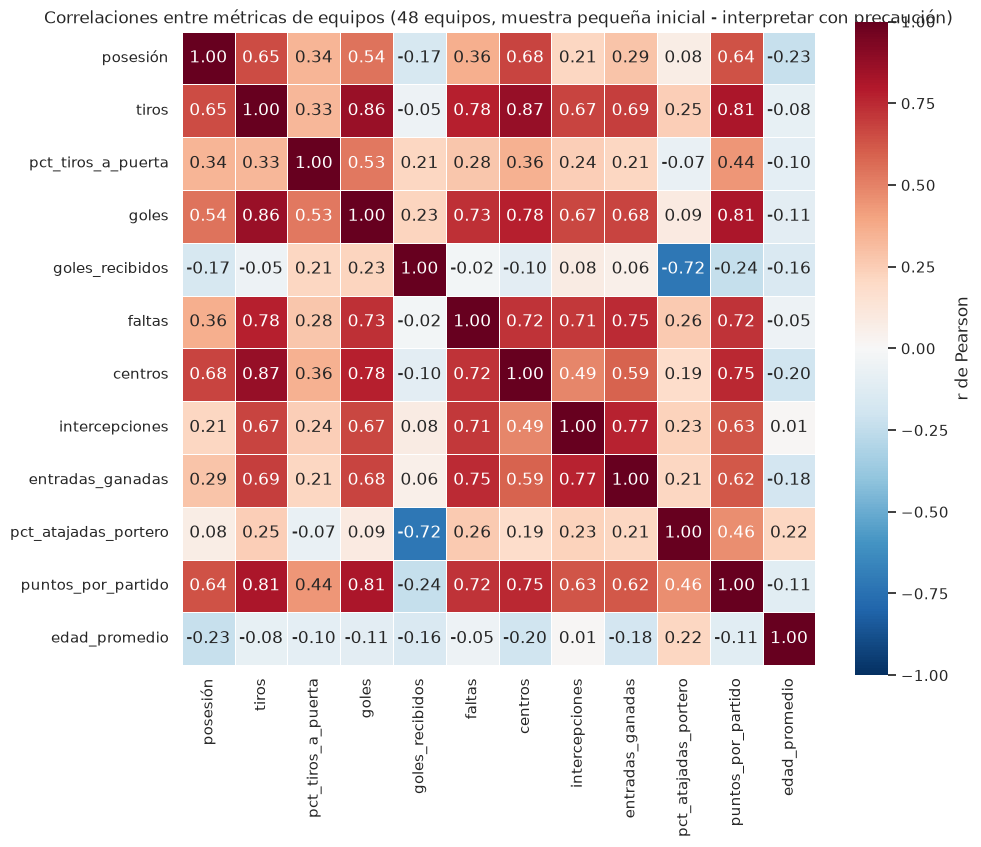

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

d = teams.copy()

cols = [
    "possession",
    "shots",
    "shots_on_target_pct",
    "goals",
    "goals_against",
    "fouls",
    "crosses",
    "interceptions",
    "tackles_won",
    "gk_save_pct",
    "points_per_game",
    "avg_age"
]

labels = [
    "posesión",
    "tiros",
    "pct_tiros_a_puerta",
    "goles",
    "goles_recibidos",
    "faltas",
    "centros",
    "intercepciones",
    "entradas_ganadas",
    "pct_atajadas_portero",
    "puntos_por_partido",
    "edad_promedio"
]

cols = [c for c in cols if c in d.columns]
labels = labels[:len(cols)]

corr = d[cols].corr()

corr.index = labels
corr.columns = labels

fig, ax = plt.subplots(figsize=(10, 8.5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"label": "r de Pearson"},
    ax=ax
)

ax.set_title(
    f"Correlaciones entre métricas de equipos "
    f"({N_TEAMS} equipos, muestra pequeña inicial - interpretar con precaución)"
)

plt.tight_layout()
plt.show()

## 58. Team radar profiles

Contrasting sides drawn across six axes, each min-max normalised over all teams so 1.0 marks the leader. The sides shown are picked automatically as stylistic extremes. Compare the silhouettes rather than any single spoke.

In [62]:
axes = [
    "possession",
    "shots",
    "shots_on_target_pct",
    "tackles_won",
    "fouls",
    "crosses"
]

axis_labels = [
    "posesión",
    "tiros",
    "% tiros a puerta",
    "entradas ganadas",
    "faltas",
    "centros"
]

d = teams.copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].map(traduccion_equipos).fillna(d["team"])

d = d.set_index("team")

rng = (d[axes].max() - d[axes].min()).replace(0, np.nan)

norm = (
    (d[axes] - d[axes].min()) / rng
).fillna(0.0)

# Selección automática de equipos con perfiles extremos:
# líderes y últimos valores en algunos ejes principales.
cand = []

for a in [
    "possession",
    "shots",
    "tackles_won",
    "crosses"
]:
    if a in d:
        cand += [
            d[a].idxmax(),
            d[a].idxmin()
        ]

picks = [
    t for t in dict.fromkeys(cand)
    if t in norm.index
][:6]

fig = go.Figure()

for t in picks:
    vals = norm.loc[t, axes].tolist()

    fig.add_trace(
        go.Scatterpolar(
            r=vals + [vals[0]],
            theta=axis_labels + [axis_labels[0]],
            fill="toself",
            name=traduccion_equipos.get(t, t),
            line_color=TEAM_COLOR.get(t),
            opacity=0.7
        )
    )

fig.update_layout(
    title="Perfiles de equipos en radar (ejes normalizados con mínimo-máximo entre todos los equipos)",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )
    ),
    height=620,
    **PLOTLY_KW
)

fig.show()

## 59. Equipos con rendimiento superior o inferior

Goles frente a tiros totales, con una línea ajustada que representa el rendimiento esperado. Los equipos por encima de la línea superan lo esperado según su volumen de tiros, mostrando una mayor eficacia en la definición; los equipos por debajo desperdician más oportunidades. La distancia vertical respecto a la línea representa el residuo.

In [63]:
import plotly.graph_objects as go

d = teams.copy()

# Traducción únicamente para visualización
d["equipo_es"] = d["team"].map(traduccion_equipos).fillna(d["team"])

coef = np.polyfit(d["shots"], d["goals"], 1)

d["exp_goals"] = np.polyval(coef, d["shots"])
d["resid"] = d["goals"] - d["exp_goals"]

xs = np.linspace(
    d["shots"].min(),
    d["shots"].max(),
    50
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=xs,
        y=np.polyval(coef, xs),
        mode="lines",
        line=dict(
            dash="dash",
            color="grey"
        ),
        name="goles esperados según tiros",
        hoverinfo="skip"
    )
)

for t in d["team"]:
    r = d[d["team"] == t].iloc[0]

    fig.add_trace(
        go.Scatter(
            x=[r["shots"]],
            y=[r["goals"]],
            mode="markers+text",
            marker=dict(
                size=13,
                color=TEAM_COLOR[t]
            ),
            text=[r["equipo_es"]],
            textposition="top center",
            name=r["equipo_es"],
            customdata=[[r["resid"]]],
            hovertemplate=(
                f"{r['equipo_es']}<br>"
                "tiros=%{x}<br>"
                "goles=%{y}<br>"
                "residuo=%{customdata[0]:+.2f}"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Equipos con rendimiento superior o inferior: goles vs línea esperada según tiros",
    xaxis_title="Tiros totales",
    yaxis_title="Goles anotados",
    showlegend=False,
    height=620,
    **PLOTLY_KW
)

fig.show()

## 60. Distribución por posición

Las barras comparan la plantilla completa de jugadores frente a aquellos que realmente participaron, agrupados por posición principal. Observa cómo el mediocampo y la defensa concentran una gran cantidad de futbolistas, mientras que muchos delanteros y porteros suplentes permanecen en el banquillo.

In [64]:
pos_all = players["pos_main"].value_counts()

pos_played = played["pos_main"].value_counts()

order = ["GK", "DF", "MF", "FW"]

comp = pd.DataFrame({
    "pos_main": order,
    "Todos los jugadores de la plantilla": [
        int(pos_all.get(p, 0)) for p in order
    ],
    "Jugadores que participaron": [
        int(pos_played.get(p, 0)) for p in order
    ],
})

# Traducción de posiciones únicamente para visualización
traduccion_posiciones = {
    "GK": "POR",
    "DF": "DEF",
    "MF": "MED",
    "FW": "DEL"
}

comp["pos_main_es"] = comp["pos_main"].map(traduccion_posiciones)

fig = go.Figure()

fig.add_bar(
    x=comp["pos_main_es"],
    y=comp["Todos los jugadores de la plantilla"],
    name="Todos los jugadores de la plantilla",
    marker_color="#9aa0b5",
    text=comp["Todos los jugadores de la plantilla"],
    textposition="outside"
)

fig.add_bar(
    x=comp["pos_main_es"],
    y=comp["Jugadores que participaron"],
    name="Jugadores que participaron",
    marker_color="#2b6cb0",
    text=comp["Jugadores que participaron"],
    textposition="outside"
)

fig.update_layout(
    title="Composición de la plantilla por posición principal: grupo completo vs jugadores utilizados",
    xaxis_title="Posición principal",
    yaxis_title="Número de jugadores",
    barmode="group",
    legend_title="",
    **PLOTLY_KW
)

fig.show()

## 61. Distribución de edades

Un histograma de las edades de los jugadores que participaron se muestra junto a un diagrama de caja por posición. Observa cómo la mayor concentración de jugadores se agrupa alrededor de los veintitantos años y analiza si los porteros y defensas presentan edades más altas que los delanteros que buscan romper líneas defensivas.

In [65]:
order = ["GK", "DF", "MF", "FW"]

sub = played[played["pos_main"].isin(order)].copy()

# Traducción únicamente para visualización
traduccion_posiciones = {
    "GK": "POR",
    "DF": "DEF",
    "MF": "MED",
    "FW": "DEL"
}

sub["pos_main_es"] = sub["pos_main"].map(traduccion_posiciones)

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.55, 0.45],
    subplot_titles=(
        "Edad de los jugadores participantes",
        "Edad por posición principal"
    )
)

fig.add_trace(
    go.Histogram(
        x=sub["age_years"],
        nbinsx=24,
        marker_color="#2b6cb0",
        name="jugadores"
    ),
    row=1,
    col=1
)

for p in order:
    vals = sub.loc[sub["pos_main"] == p, "age_years"]

    fig.add_trace(
        go.Box(
            y=vals,
            name=traduccion_posiciones.get(p, p),
            boxpoints="all",
            jitter=0.4,
            marker_size=4,
            line_color="#2b6cb0"
        ),
        row=1,
        col=2
    )

fig.update_xaxes(
    title_text="Edad (años)",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Jugadores",
    row=1,
    col=1
)

fig.update_xaxes(
    title_text="Posición principal",
    row=1,
    col=2
)

fig.update_yaxes(
    title_text="Edad (años)",
    row=1,
    col=2
)

fig.update_layout(
    title="Distribución de experiencia: edades de los jugadores participantes",
    showlegend=False,
    **PLOTLY_KW
)

fig.show()

## 62. Los jugadores más veteranos y jóvenes

Dos tablas muestran los extremos de edad de todas las plantillas. El grupo de mayor edad está dominado por porteros cercanos o mayores de 40 años, mientras que la lista de jugadores más jóvenes incluye futbolistas por debajo de los 18 años.

In [66]:
cols = ["player", "team", "pos_main", "age_years"]

oldest = (
    players
    .dropna(subset=["age_years"])
    .nlargest(10, "age_years")[cols]
    .reset_index(drop=True)
)

oldest.index = oldest.index + 1
oldest["age_years"] = oldest["age_years"].round(2)

youngest = (
    players
    .dropna(subset=["age_years"])
    .nsmallest(10, "age_years")[cols]
    .reset_index(drop=True)
)

youngest.index = youngest.index + 1
youngest["age_years"] = youngest["age_years"].round(2)

# Traducción únicamente para visualización
traduccion_posiciones = {
    "GK": "POR",
    "DF": "DEF",
    "MF": "MED",
    "FW": "DEL"
}

for df in [oldest, youngest]:
    df["team_es"] = df["team"].map(traduccion_equipos).fillna(df["team"])
    df["pos_main_es"] = df["pos_main"].map(traduccion_posiciones).fillna(df["pos_main"])

    df.rename(
        columns={
            "player": "Jugador",
            "team": "Equipo",
            "pos_main": "Posición",
            "age_years": "Edad (años)",
            "team_es": "Equipo (ES)",
            "pos_main_es": "Posición (ES)"
        },
        inplace=True
    )

print("Diez jugadores más veteranos del torneo")
display(
    oldest[
        [
            "Jugador",
            "Equipo (ES)",
            "Posición (ES)",
            "Edad (años)"
        ]
    ]
)

print("Diez jugadores más jóvenes del torneo")
display(
    youngest[
        [
            "Jugador",
            "Equipo (ES)",
            "Posición (ES)",
            "Edad (años)"
        ]
    ]
)

Diez jugadores más veteranos del torneo


,Jugador,Equipo (ES),Posición (ES),Edad (años)
1,Craig Gordon,Escocia,POR,43.0
2,Cristiano Ronaldo,Portugal,DEL,41.0
3,Edin Džeko,Bosnia–Herz,DEL,40.0
4,Vozinha,Cabo Verde,POR,40.0
5,Luka Modrić,Croacia,MED,40.0
6,Manuel Neuer,Alemania,POR,40.0
7,Guillermo Ochoa,México,POR,40.0
8,Hernán Galíndez,Ecuador,POR,39.0
9,El Mahdy Soliman,Egipto,POR,39.0
10,Yūto Nagatomo,Japón,DEF,39.0


Diez jugadores más jóvenes del torneo


,Jugador,Equipo (ES),Posición (ES),Edad (años)
1,Gilberto Mora,México,MED,17.0
2,Lucas Herrington,Australia,DEF,18.0
3,Kerim Alajbegović,Bosnia–Herz,MED,18.0
4,Mladen Jurkas,Bosnia–Herz,POR,18.0
5,Hugo Sochůrek,Chequia,MED,18.0
6,Hamza Abdelkarim,Egipto,DEL,18.0
7,Ayyoub Bouaddi,Marruecos,MED,18.0
8,Bara Sapoko Ndiaye,Senegal,MED,18.0
9,Ibrahim Mbaye,Senegal,MED,18.0
10,Lamine Yamal,España,MED,18.0


## 63. Generaciones por año de nacimiento

Contar jugadores por año de nacimiento muestra claramente la distribución generacional. Observa la generación con mayor concentración de futbolistas, que aporta la mayoría de los titulares, y las colas más reducidas que se extienden hacia los jugadores veteranos y hacia la nueva generación de futbolistas jóvenes.

In [67]:
by_year = (
    players
    .dropna(subset=["birth_year"])
    .assign(
        birth_year=lambda d: d["birth_year"].astype(int)
    )
    .groupby("birth_year")
    .size()
    .reset_index(name="players")
)

fig = px.bar(
    by_year,
    x="birth_year",
    y="players",
    text="players",
    title="Generaciones por año de nacimiento: distribución generacional en todas las plantillas",
    color_discrete_sequence=["#2b6cb0"]
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Año de nacimiento",
    yaxis_title="Número de jugadores",
    xaxis=dict(dtick=2),
    **PLOTLY_KW
)

fig.show()

## 64. Distribución de minutos

Minutos jugados por todos los jugadores que participaron, agrupados por posición. El pico en 90 minutos representa a los titulares que disputaron el partido completo, mientras que la concentración en los valores bajos corresponde a los suplentes con pocas apariciones. Esta diferencia explica por qué las métricas por 90 minutos pueden ser engañosas en participaciones cortas.

In [68]:
mp = played.dropna(subset=["minutes"]).copy()

mp["rol"] = np.where(
    mp["minutes"] >= 90,
    "Titular con partido completo",
    "Participación parcial / suplente"
)

fig = px.histogram(
    mp,
    x="minutes",
    color="rol",
    nbins=18,
    color_discrete_map={
        "Titular con partido completo": "#2b6cb0",
        "Participación parcial / suplente": "#dd6b20"
    },
    title="Minutos jugados: titulares completos vs suplentes"
)

fig.update_layout(
    barmode="stack",
    xaxis_title="Minutos jugados",
    yaxis_title="Número de jugadores",
    legend_title="",
    **PLOTLY_KW
)

fig.show()

n_full = int((mp["minutes"] >= 90).sum())
n_sub = int((mp["minutes"] < 90).sum())

print(
    f"Apariciones con partido completo: {n_full} | "
    f"apariciones parciales/suplentes: {n_sub}"
)

Apariciones con partido completo: 729 | apariciones parciales/suplentes: 310


## 65. Máximos goleadores

La clasificación de la Bota de Oro, ordenada por goles y después por participaciones totales en goles. Observa cómo los líderes se separan del resto y cómo el grupo perseguidor de jugadores con un solo gol completa la lista.

In [69]:
scorers = (
    played[played["goals"].fillna(0) > 0]
    .sort_values(
        ["goals", "goals_assists"],
        ascending=False
    )
    .head(15)
    .copy()
)

# Traducción únicamente para visualización
scorers["team_es"] = scorers["team"].map(traduccion_equipos).fillna(scorers["team"])

scorers["label"] = (
    scorers["player"]
    + " ("
    + scorers["team_es"]
    + ")"
)

fig = px.bar(
    scorers.iloc[::-1],
    x="goals",
    y="label",
    orientation="h",
    color="team",
    color_discrete_map=TEAM_COLOR,
    hover_data={
        "goals_assists": True,
        "team_es": True,
        "label": False
    },
    title="Clasificación de goleadores: máximos anotadores hasta ahora"
)

fig.update_layout(
    xaxis_title="Goles",
    yaxis_title="",
    showlegend=False,
    **PLOTLY_KW
)

fig.show()

## 66. Máximos asistentes

Los principales generadores de juego, ordenados por asistencias con los goles añadidos como indicador de participación total. Una lista de los jugadores que están creando las oportunidades que terminan en gol.

In [70]:
creators = (
    played[played["goals_assists"].fillna(0) > 0]
    .sort_values(
        ["assists", "goals_assists"],
        ascending=False
    )
    .head(15)
    .copy()
)

# Traducción únicamente para visualización
creators["team_es"] = creators["team"].map(traduccion_equipos).fillna(creators["team"])

creators["label"] = (
    creators["player"]
    + " ("
    + creators["team_es"]
    + ")"
)

fig = go.Figure()

fig.add_bar(
    y=creators["label"][::-1],
    x=creators["assists"][::-1],
    orientation="h",
    name="Asistencias",
    marker_color="#2b6cb0"
)

fig.add_bar(
    y=creators["label"][::-1],
    x=creators["goals"][::-1],
    orientation="h",
    name="Goles",
    marker_color="#dd6b20"
)

fig.update_layout(
    barmode="stack",
    title="Los creadores: asistencias (y goles) de los principales generadores",
    xaxis_title="Participaciones de gol",
    yaxis_title="",
    legend_title="",
    **PLOTLY_KW
)

fig.show()

## 67. Contribuciones de gol por posición

La suma de goles y asistencias agrupada por posición principal muestra de dónde proviene la producción ofensiva. Los delanteros lideran la anotación, mientras que los mediocampistas dominan la columna de asistencias, reflejando la división clásica entre creación y definición.

In [71]:
order = ["GK", "DF", "MF", "FW"]

contrib = (
    played
    .groupby("pos_main")[["goals", "assists"]]
    .sum()
    .reindex(order)
    .fillna(0)
    .reset_index()
)

# Traducción únicamente para visualización
traduccion_posiciones = {
    "GK": "POR",
    "DF": "DEF",
    "MF": "MED",
    "FW": "DEL"
}

contrib["pos_main_es"] = contrib["pos_main"].map(traduccion_posiciones)

fig = go.Figure()

fig.add_bar(
    x=contrib["pos_main_es"],
    y=contrib["goals"],
    name="Goles",
    marker_color="#2b6cb0",
    text=contrib["goals"].astype(int),
    textposition="outside"
)

fig.add_bar(
    x=contrib["pos_main_es"],
    y=contrib["assists"],
    name="Asistencias",
    marker_color="#dd6b20",
    text=contrib["assists"].astype(int),
    textposition="outside"
)

fig.update_layout(
    barmode="group",
    title="Origen de la producción ofensiva: goles y asistencias por posición principal",
    xaxis_title="Posición principal",
    yaxis_title="Total (suma entre jugadores)",
    legend_title="",
    **PLOTLY_KW
)

fig.show()

## 68. Líderes en volumen de tiros

Los jugadores con más disparos, mostrando los intentos totales divididos según precisión. La proporción de tiros a puerta frente al resto de intentos permite identificar quién fue realmente peligroso y quién simplemente acumuló disparos.

In [72]:
shooters = (
    played[played["shots"].fillna(0) > 0]
    .sort_values(
        ["shots", "shots_on_target"],
        ascending=False
    )
    .head(15)
    .copy()
)

# Traducción únicamente para visualización
shooters["team_es"] = shooters["team"].map(traduccion_equipos).fillna(shooters["team"])

shooters["label"] = (
    shooters["player"]
    + " ("
    + shooters["team_es"]
    + ")"
)

shooters["off_target"] = (
    shooters["shots"]
    - shooters["shots_on_target"].fillna(0)
)

fig = go.Figure()

fig.add_bar(
    y=shooters["label"][::-1],
    x=shooters["shots_on_target"][::-1],
    orientation="h",
    name="A puerta",
    marker_color="#2b6cb0"
)

fig.add_bar(
    y=shooters["label"][::-1],
    x=shooters["off_target"][::-1],
    orientation="h",
    name="Fuera de puerta",
    marker_color="#cbd5e0"
)

fig.update_layout(
    barmode="stack",
    title="Jugadores con más tiros: intentos totales divididos por precisión",
    xaxis_title="Tiros",
    yaxis_title="",
    legend_title="",
    **PLOTLY_KW
)

fig.show()

## 69. Líderes en definición

Goles por tiro entre jugadores con al menos tres intentos, una clasificación de eficacia ofensiva. Interprétala con precaución: un solo gol en una muestra pequeña puede inflar la tasa, por lo que debe leerse como una fotografía puntual del rendimiento.

In [73]:
MIN_SHOTS = 3

fin = (
    played[played["shots"].fillna(0) >= MIN_SHOTS]
    .dropna(subset=["goals_per_shot"])
    .sort_values(
        ["goals_per_shot", "shots"],
        ascending=False
    )
    .head(15)
    .copy()
)

# Traducción únicamente para visualización
fin["team_es"] = fin["team"].map(traduccion_equipos).fillna(fin["team"])

fin["label"] = (
    fin["player"]
    + " ("
    + fin["team_es"]
    + ")"
)

fin["finish_pct"] = (
    fin["goals_per_shot"] * 100
).round(1)

fig = px.bar(
    fin.iloc[::-1],
    x="finish_pct",
    y="label",
    orientation="h",
    color="team",
    color_discrete_map=TEAM_COLOR,
    hover_data={
        "goals": True,
        "shots": True,
        "team_es": True,
        "label": False
    },
    title=f"Líderes en definición: goles por tiro (mínimo {MIN_SHOTS} tiros)"
)

fig.update_layout(
    xaxis_title="Goles por tiro (%)",
    yaxis_title="",
    showlegend=False,
    **PLOTLY_KW
)

fig.show()

## 70. Líderes disciplinarios

Las faltas cometidas por los jugadores que participaron, mostrando las tarjetas recibidas y las expulsiones acumuladas. Observa a los jugadores que interrumpen constantemente el juego y acumulan faltas, así como aquellos que terminaron siendo expulsados.

In [74]:
df = played.copy()

df["cards"] = (
    df["cards_yellow"].fillna(0)
    + df["cards_red"].fillna(0)
)

disc = df[
    (df["fouls"].fillna(0) > 0)
    | (df["cards"] > 0)
].copy()

disc = (
    disc
    .sort_values(
        ["fouls", "cards"],
        ascending=False
    )
    .head(15)
)

# Traducción únicamente para visualización
disc["team_es"] = disc["team"].map(traduccion_equipos).fillna(disc["team"])

disc["label"] = (
    disc["player"]
    + " ("
    + disc["team_es"]
    + ")"
)

disc["yellow"] = disc["cards_yellow"].fillna(0)
disc["red"] = disc["cards_red"].fillna(0)

fig = go.Figure()

fig.add_bar(
    y=disc["label"],
    x=disc["fouls"],
    orientation="h",
    name="Faltas cometidas",
    marker_color="#636EFA",
    text=disc["fouls"].astype(int),
    textposition="outside"
)

reds = disc[disc["red"] > 0]

fig.add_trace(
    go.Scatter(
        y=reds["label"],
        x=reds["fouls"],
        mode="markers",
        name="Expulsado (tarjeta roja)",
        marker=dict(
            symbol="x",
            size=13,
            color="crimson"
        )
    )
)

yells = disc[disc["yellow"] > 0]

fig.add_trace(
    go.Scatter(
        y=yells["label"],
        x=yells["fouls"],
        mode="markers",
        name="Amonestado (tarjeta amarilla)",
        marker=dict(
            symbol="diamond",
            size=10,
            color="gold",
            line=dict(
                width=1,
                color="black"
            )
        )
    )
)

fig.update_layout(
    title="Líderes disciplinarios: faltas cometidas con tarjetas señaladas",
    xaxis_title="Faltas cometidas",
    yaxis=dict(
        autorange="reversed",
        title=""
    ),
    height=560,
    **PLOTLY_KW
)

fig.show()

## 71. Jugadores que más reciben faltas

Jugadores que reciben más faltas: los creadores y regateadores que los rivales solo pudieron detener de forma ilegal. Un indicador de quién generó más peligro.


In [75]:
df = played.copy()

top = df[df["fouled"].fillna(0) > 0].sort_values("fouled", ascending=False).head(15).copy()

top["team_es"] = top["team"].map(traduccion_equipos).fillna(top["team"])
top["label"] = top["player"] + " (" + top["team_es"] + ")"

fig = px.bar(
    top,
    x="fouled",
    y="label",
    orientation="h",
    color="team",
    color_discrete_map=TEAM_COLOR,
    text="fouled",
    title="Jugadores que más reciben faltas: los creadores y regateadores más buscados"
)

fig.update_traces(texttemplate="%{text:.0f}", textposition="outside")

fig.update_layout(
    xaxis_title="Veces que recibió falta",
    yaxis=dict(autorange="reversed", title=""),
    height=560,
    showlegend=False,
    **PLOTLY_KW
)

fig.show()

## 72. Líderes en centros

Centros realizados, la señal más clara de quién proporcionó amplitud al equipo. Considera el volumen total como una medida de intención, no de precisión.


In [76]:
df = played.copy()

top = df[df["crosses"].fillna(0) > 0].sort_values("crosses", ascending=False).head(15).copy()

top["team_es"] = top["team"].map(traduccion_equipos).fillna(top["team"])
top["label"] = top["player"] + " (" + top["team_es"] + ")"

fig = px.bar(
    top,
    x="crosses",
    y="label",
    orientation="h",
    color="team",
    color_discrete_map=TEAM_COLOR,
    text="crosses",
    title="Líderes en centros: principales generadores de amplitud"
)

fig.update_traces(texttemplate="%{text:.0f}", textposition="outside")

fig.update_layout(
    xaxis_title="Centros",
    yaxis=dict(autorange="reversed", title=""),
    height=560,
    showlegend=False,
    **PLOTLY_KW
)

fig.show()

## 73. Líderes defensivos

Intercepciones más entradas ganadas, apiladas, muestran a los recuperadores de balón. Estas lecturas y duelos son el motor poco reconocido detrás de un resultado.


In [77]:
df = played.copy()

df["ball_wins"] = df["interceptions"].fillna(0) + df["tackles_won"].fillna(0)

top = df[df["ball_wins"] > 0].sort_values(
    ["ball_wins", "interceptions"],
    ascending=False
).head(15).copy()

top["team_es"] = top["team"].map(traduccion_equipos).fillna(top["team"])
top["label"] = top["player"] + " (" + top["team_es"] + ")"

fig = go.Figure()

fig.add_bar(
    y=top["label"],
    x=top["interceptions"].fillna(0),
    orientation="h",
    name="Intercepciones",
    marker_color="#00CC96"
)

fig.add_bar(
    y=top["label"],
    x=top["tackles_won"].fillna(0),
    orientation="h",
    name="Entradas ganadas",
    marker_color="#AB63FA"
)

fig.update_layout(
    barmode="stack",
    title="Líderes defensivos: intercepciones + entradas ganadas, recuperadores de balón",
    xaxis_title="Acciones defensivas",
    yaxis=dict(autorange="reversed", title=""),
    height=560,
    **PLOTLY_KW
)

fig.show()

## 74. Extremos de más/menos

Diferencia de goles generada mientras cada jugador estuvo en el campo. Al principio, los valores simplemente reflejan los marcadores del equipo: los ganadores se agrupan en valores positivos y los perdedores en negativos. Léelo como una referencia anecdótica.


In [78]:
df = played.copy().dropna(subset=["plus_minus"])

best = df.sort_values("plus_minus", ascending=False).head(8)
worst = df.sort_values("plus_minus", ascending=True).head(8)

ext = pd.concat([worst, best]).drop_duplicates(subset=["player", "team"])
ext = ext.sort_values("plus_minus")

ext["team_es"] = ext["team"].map(traduccion_equipos).fillna(ext["team"])
ext["label"] = ext["player"] + " (" + ext["team_es"] + ")"

ext["sign"] = np.where(
    ext["plus_minus"] >= 0,
    "En campo +",
    "En campo -"
)

fig = px.bar(
    ext,
    x="plus_minus",
    y="label",
    orientation="h",
    color="sign",
    color_discrete_map={"En campo +": "#2ca02c", "En campo -": "#d62728"},
    text="plus_minus",
    title="Extremos de más/menos: diferencia de goles en campo (muestra pequeña, tomar como referencia anecdótica)"
)

fig.update_traces(texttemplate="%{text:.0f}", textposition="outside")

fig.update_layout(
    xaxis_title="Goles a favor menos goles en contra mientras estuvo en el campo",
    yaxis_title="",
    legend_title="",
    height=620,
    **PLOTLY_KW
)

fig.show()

## 75. Con o sin él

La diferencia con o sin el jugador: balance de goles por 90 minutos entre cuando está en el campo y cuando está fuera. Los minutos de participación muy cortos pueden hacer explotar la métrica. Confía en la dirección, no en la magnitud.


In [79]:
df = played.copy().dropna(subset=["plus_minus_wowy"])

df["absw"] = df["plus_minus_wowy"].abs()

top = df.sort_values("absw", ascending=False).head(16).copy()
top = top.sort_values("plus_minus_wowy")

top["team_es"] = top["team"].map(traduccion_equipos).fillna(top["team"])

top["label"] = (
    top["player"]
    + " ("
    + top["team_es"]
    + ", "
    + top["minutes"].fillna(0).astype(int).astype(str)
    + "')"
)

top["dir"] = np.where(
    top["plus_minus_wowy"] >= 0,
    "Equipo mejor con él en campo",
    "Equipo mejor sin él en campo"
)

fig = px.bar(
    top,
    x="plus_minus_wowy",
    y="label",
    orientation="h",
    color="dir",
    color_discrete_map={
        "Equipo mejor con él en campo": "#1f77b4",
        "Equipo mejor sin él en campo": "#ff7f0e"
    },
    text="plus_minus_wowy",
    title="Con o sin él: cambio del balance de goles por 90 (muy inflado en jugadores con pocos minutos)"
)

fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")

fig.update_layout(
    xaxis_title="plus_minus_wowy (balance con el jugador en campo menos fuera del campo, por 90)",
    yaxis_title="",
    legend_title="",
    height=640,
    **PLOTLY_KW
)

fig.show()

## 76. Representación de clubes

Clubes que aportan más jugadores a estas selecciones. El club no está disponible para gran parte del grupo, por lo que este conteo solo considera la minoría registrada: un límite mínimo de representación, no un censo completo.


In [80]:
df = players.copy()

n_total = len(df)
n_null = df["club"].isna().sum()

top = df["club"].value_counts().head(15).reset_index()
top.columns = ["club", "players"]

top["club_es"] = top["club"].map(traduccion_equipos).fillna(top["club"])

fig = px.bar(
    top,
    x="players",
    y="club_es",
    orientation="h",
    text="players",
    title=f"Representación de clubes: principales proveedores de jugadores a las 16 selecciones ({n_null} de {n_total} jugadores no tienen club registrado)"
)

fig.update_traces(
    marker_color="#636EFA",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Jugadores en estas selecciones",
    yaxis=dict(autorange="reversed", title=""),
    height=560,
    **PLOTLY_KW
)

fig.show()

## 77. Nube de palabras de clubes

Las mismas afiliaciones de clubes representadas como una nube de palabras, con un tamaño proporcional a la cantidad de jugadores de cada selección que pertenece a cada club. Una vista rápida de dónde juega semanalmente el talento de esta Copa del Mundo.


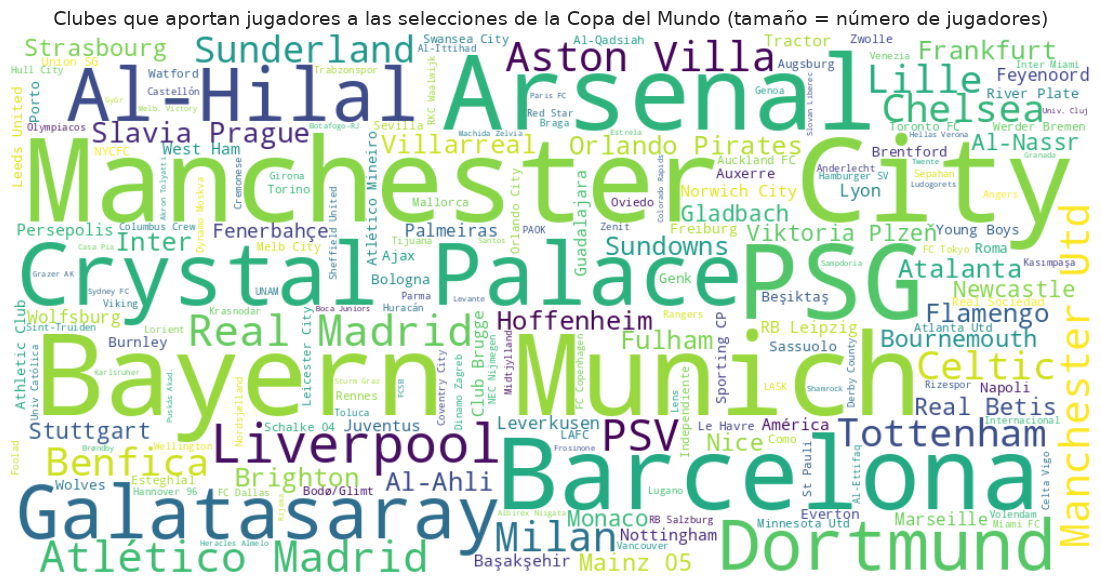

In [81]:
!pip install WordCloud

from wordcloud import WordCloud

freq = players["club"].dropna().value_counts().to_dict()

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis",
    prefer_horizontal=0.95
).generate_from_frequencies(freq)

fig, ax = plt.subplots(figsize=(12, 6))

ax.imshow(wc, interpolation="bilinear")
ax.axis("off")

ax.set_title(
    "Clubes que aportan jugadores a las selecciones de la Copa del Mundo (tamaño = número de jugadores)",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 78. Análisis profundo de porteros

Los porteros titulares clasificados por porcentaje de atajadas, junto con atajadas, tiros recibidos, goles concedidos y porterías a cero. Observa los partidos sin recibir goles y a los porteros que encajaron goles con pocas oportunidades en contra.


In [82]:
g = gks.copy()

tbl = g[[
    "player",
    "team",
    "gk_save_pct",
    "gk_saves",
    "gk_shots_on_target_against",
    "gk_goals_against",
    "gk_clean_sheets"
]].copy()

tbl = tbl.sort_values("gk_save_pct", ascending=False).reset_index(drop=True)

tbl.columns = [
    "Portero",
    "Equipo",
    "Porcentaje de atajadas",
    "Atajadas",
    "Tiros a puerta recibidos",
    "Goles en contra",
    "Porterías a cero"
]

display(tbl)

g = g.sort_values("gk_save_pct", ascending=False).copy()

g["team_es"] = g["team"].map(traduccion_equipos).fillna(g["team"])
g["label"] = g["player"] + " (" + g["team_es"] + ")"

fig = px.bar(
    g,
    x="gk_save_pct",
    y="label",
    orientation="h",
    color="team",
    color_discrete_map=TEAM_COLOR,
    text="gk_save_pct",
    hover_data={
        "gk_saves": True,
        "gk_goals_against": True,
        "gk_shots_on_target_against": True
    },
    title=f"Análisis profundo de porteros: porcentaje de atajadas de los {N_GK} titulares"
)

fig.update_traces(
    texttemplate="%{text:.0f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Porcentaje de atajadas",
    yaxis=dict(autorange="reversed", title=""),
    showlegend=False,
    height=max(420, 26 * len(g)),
    **PLOTLY_KW
)

fig.show()

,Portero,Equipo,Porcentaje de atajadas,Atajadas,Tiros a puerta recibidos,Goles en contra,Porterías a cero
0,Unai Simón,Spain,90.9,9.0,11.0,1.0,7.0
1,Lawrence Ati-Zigi,Ghana,88.9,8.0,9.0,1.0,1.0
2,Diogo Costa,Portugal,86.4,19.0,22.0,3.0,2.0
3,Camilo Vargas,Colombia,85.7,6.0,7.0,1.0,4.0
4,Alireza Beiranvand,IR Iran,83.3,15.0,18.0,3.0,1.0
...,...,...,...,...,...,...,...
57,Oussama Benbot,Algeria,0.0,0.0,3.0,3.0,0.0
58,Matt Turner,United States,0.0,0.0,3.0,3.0,0.0
59,Mathew Ryan,Australia,NaN,0.0,0.0,0.0,0.0
60,Guillermo Ochoa,Mexico,NaN,0.0,0.0,0.0,1.0


## 79. Ruido de los per90 en jugadores

Por qué los per90 engañan con muestras pequeñas. Goles por 90 minutos frente a minutos jugados para cada goleador: un gol en una breve aparición puede parecer enorme. Los titulares se mantienen razonablemente bajos. Filtra por minutos antes de confiar en cualquier métrica por tasa.


In [83]:
df = played.copy().dropna(subset=["minutes", "goals_per90"])

df = df[df["goals"].fillna(0) > 0].copy()

df["label"] = (
    df["player"]
    + " ("
    + df["minutes"].astype(int).astype(str)
    + "' , "
    + df["goals"].astype(int).astype(str)
    + "g)"
)

df["type"] = np.where(
    df["minutes"] < 30,
    "Suplente (menos de 30 min)",
    "Titular"
)

fig = px.scatter(
    df,
    x="minutes",
    y="goals_per90",
    color="type",
    text=None,
    color_discrete_map={
        "Suplente (menos de 30 min)": "#d62728",
        "Titular": "#1f77b4"
    },
    hover_name="player",
    hover_data={
        "team": True,
        "goals": True,
        "minutes": True
    },
    size="goals",
    size_max=22,
    title="Ruido de los per90: goles_per90 vs minutos para goleadores (pocos minutos inflan la tasa)"
)

hi = df.sort_values("goals_per90", ascending=False).head(3)

for _, r in hi.iterrows():
    fig.add_annotation(
        x=r["minutes"],
        y=r["goals_per90"],
        text=r["player"],
        showarrow=True,
        arrowhead=2,
        ax=40,
        ay=-20,
        font=dict(size=10)
    )

fig.update_layout(
    xaxis_title="Minutos jugados",
    yaxis_title="Goles por 90",
    legend_title="",
    height=560,
    **PLOTLY_KW
)

fig.show()

## 80. Goles de jugadores vs goles del equipo

Suma de los goles de los jugadores de cada selección comparada con el total registrado en el archivo de equipos. Las selecciones sobre la línea y=x coinciden entre archivos; las diferencias normalmente se deben a autogoles, que no se atribuyen ni al goleador ni al equipo que los recibe.


In [84]:
# Consistencia entre archivos: ¿la suma de goles de jugadores por equipo coincide con los goles del equipo?

ps = players.groupby("team")["goals"].sum().rename("player_goals_sum")

chk80 = (
    teams.set_index("team")[["goals"]]
    .rename(columns={"goals": "team_goals"})
    .join(ps)
    .reset_index()
)

chk80["group"] = chk80["team"].map(GROUP)

chk80["team_es"] = chk80["team"].map(traduccion_equipos).fillna(chk80["team"])

mx = float(max(chk80["team_goals"].max(), chk80["player_goals_sum"].max())) + 0.5

fig = px.scatter(
    chk80,
    x="team_goals",
    y="player_goals_sum",
    text="team_es",
    color="group",
    title="Verificación entre archivos: suma de goles de jugadores vs goles del equipo (por selección)",
    labels={
        "team_goals": "Goles del equipo",
        "player_goals_sum": "Suma de goles de jugadores",
        "group": "Grupo"
    },
    **PLOTLY_KW,
)

fig.add_shape(
    type="line",
    x0=-0.5,
    y0=-0.5,
    x1=mx,
    y1=mx,
    line=dict(color="grey", dash="dash")
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=11)
)

fig.update_layout(
    xaxis=dict(range=[-0.5, mx]),
    yaxis=dict(range=[-0.5, mx])
)

fig.show()

n_off = int((chk80["team_goals"] != chk80["player_goals_sum"]).sum())

print(f"Selecciones fuera de la línea y=x: {n_off} de {len(chk80)}")

# Nota: Estados Unidos aparece con 3 aquí mientras que el marcador fue 4-1:
# el cuarto gol fue un autogol de Paraguay, que no se atribuye ni a goles de jugadores
# ni a goles del equipo que recibió el gol.

Selecciones fuera de la línea y=x: 0 de 48


## 81. Reconciliación de posesión

Cada barra representa la posesión registrada en el archivo de equipos; cada rombo representa el promedio de las filas de partidos de ese equipo. Ambos valores deberían coincidir: una verificación limpia entre archivos que confirma que las dos fuentes cuentan la misma historia.


In [86]:
# Crear tabla por equipo desde matches.csv para análisis por partido

home = matches[[
    "home_team",
    "away_team",
    "home_possession"
]].copy()

home.columns = [
    "team",
    "opponent",
    "possession"
]

away = matches[[
    "away_team",
    "home_team",
    "away_possession"
]].copy()

away.columns = [
    "team",
    "opponent",
    "possession"
]

team_match = pd.concat(
    [home, away],
    ignore_index=True
)

team_match["possession"] = pd.to_numeric(
    team_match["possession"],
    errors="coerce"
)

In [87]:
# Posesión del archivo de equipos vs promedio de las filas de partidos de cada equipo en team_match.

tm_poss = team_match.groupby("team")["possession"].mean().rename("team_match_possession")

poss81 = (
    teams.set_index("team")[["possession"]]
    .rename(columns={"possession": "teams_possession"})
    .join(tm_poss)
    .reset_index()
)

poss81["team_es"] = poss81["team"].map(traduccion_equipos).fillna(poss81["team"])

poss81["abs_diff"] = (
    poss81["teams_possession"] - poss81["team_match_possession"]
).abs()

poss81 = poss81.sort_values("teams_possession")

fig = go.Figure()

fig.add_trace(
    go.Bar(
        y=poss81["team_es"],
        x=poss81["teams_possession"],
        orientation="h",
        name="Posesión del equipo",
        marker_color="#4C78A8",
        opacity=0.85
    )
)

fig.add_trace(
    go.Scatter(
        y=poss81["team_es"],
        x=poss81["team_match_possession"],
        mode="markers",
        name="Promedio de posesión por partido",
        marker=dict(color="black", symbol="diamond", size=9)
    )
)

fig.update_layout(
    title="Reconciliación de posesión: archivo de equipos vs promedio de partidos derivados",
    xaxis_title="Posesión (%)",
    yaxis_title="",
    height=max(520, 26 * len(poss81)),
    **PLOTLY_KW
)

fig.show()

print(
    f"Diferencia absoluta máxima de posesión entre {len(poss81)} equipos: "
    f"{poss81['abs_diff'].max():.2f}"
)

Diferencia absoluta máxima de posesión entre 48 equipos: 0.05


## 82. Reconciliación de edad de plantillas

Los puntos rojos representan un promedio simple de edad de la plantilla, mientras que los diamantes verdes ponderan cada jugador según sus minutos disputados. Solo la línea ponderada se ajusta a la línea y=x, revelando que `teams.avg_age` está ponderada por minutos, no que sea un promedio simple.


In [88]:
# Edad promedio del archivo de equipos vs dos medias derivadas de jugadores:
# promedio simple de plantilla y promedio ponderado por minutos.

def _wavg_age(g):
    w = g["minutes"].fillna(0)
    return np.average(g["age_years"], weights=w) if w.sum() > 0 else np.nan

roster_mean = (
    played.groupby("team")["age_years"]
    .mean()
    .rename("roster_mean_age")
)

weighted_mean = (
    played.groupby("team")
    .apply(_wavg_age)
    .rename("minutes_weighted_age")
)

age82 = (
    teams.set_index("team")[["avg_age"]]
    .join(roster_mean)
    .join(weighted_mean)
    .reset_index()
)

age82["team_es"] = (
    age82["team"]
    .map(traduccion_equipos)
    .fillna(age82["team"])
)

lo = float(
    age82[["avg_age", "roster_mean_age", "minutes_weighted_age"]]
    .min()
    .min()
) - 0.3

hi = float(
    age82[["avg_age", "roster_mean_age", "minutes_weighted_age"]]
    .max()
    .max()
) + 0.3

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=age82["avg_age"],
        y=age82["roster_mean_age"],
        mode="markers+text",
        text=age82["team_es"],
        textposition="top center",
        name="Promedio simple de plantilla",
        marker=dict(
            color="#E45756",
            size=9
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=age82["avg_age"],
        y=age82["minutes_weighted_age"],
        mode="markers",
        name="Promedio ponderado por minutos",
        marker=dict(
            color="#54A24B",
            symbol="diamond",
            size=10
        )
    )
)

fig.add_shape(
    type="line",
    x0=lo,
    y0=lo,
    x1=hi,
    y1=hi,
    line=dict(
        color="grey",
        dash="dash"
    )
)

fig.update_layout(
    title="Reconciliación de edad: edad_promedio del equipo vs medias derivadas de jugadores (avg_age sigue la línea ponderada)",
    xaxis_title="Edad promedio del equipo",
    yaxis_title="Edad media derivada de jugadores",
    xaxis=dict(range=[lo, hi]),
    yaxis=dict(range=[lo, hi]),
    **PLOTLY_KW
)

fig.show()

mad_roster = (
    age82["avg_age"] -
    age82["roster_mean_age"]
).abs().mean()

mad_w = (
    age82["avg_age"] -
    age82["minutes_weighted_age"]
).abs().mean()

print(
    f"Diferencia absoluta media vs promedio simple de plantilla: {mad_roster:.3f} | "
    f"vs promedio ponderado por minutos: {mad_w:.3f}"
)

Diferencia absoluta media vs promedio simple de plantilla: 0.597 | vs promedio ponderado por minutos: 0.138


## 83. Tarjeta de reporte unificada de equipos

Una fila por equipo, combinando información de los tres archivos: rendimiento y puntos, goles y tiros, posesión, edad de la plantilla, porcentaje de atajadas del portero y máximo goleador. La única tabla para revisar rápidamente quién hizo qué.


In [89]:
# Una tarjeta unificada por equipo: rendimiento y puntos desde team_agg (cualquier cantidad de partidos),
# totales acumulados desde el archivo de equipos y máximo goleador desde jugadores.

def _top_scorer(g):
    g = g.sort_values(["goals", "assists"], ascending=False)
    r = g.iloc[0]
    return (
        f"{r['player']} ({int(r['goals'])})"
        if (pd.notna(r["goals"]) and r["goals"] > 0)
        else "-"
    )

top_sc = (
    played.groupby("team")
    .apply(_top_scorer)
    .rename("top_scorer")
    if not played.empty
    else pd.Series(dtype=object, name="top_scorer")
)

rec = (
    team_agg.set_index("team")[["P", "W", "D", "L", "points", "gf", "ga", "gd"]]
    if not team_agg.empty
    else pd.DataFrame()
)

card = (
    teams.set_index("team")[[
        "goals",
        "shots",
        "shots_on_target",
        "possession",
        "avg_age",
        "gk_save_pct"
    ]]
    .join(rec)
    .join(top_sc)
    .reset_index()
)

card["team_es"] = (
    card["team"]
    .map(traduccion_equipos)
    .fillna(card["team"])
)

for c in ["P", "W", "D", "L", "points", "gf", "ga", "gd"]:
    if c not in card:
        card[c] = np.nan

card["record"] = (
    card["W"].fillna(0).astype(int).astype(str)
    + "-"
    + card["D"].fillna(0).astype(int).astype(str)
    + "-"
    + card["L"].fillna(0).astype(int).astype(str)
)

card = card[[
    "team_es",
    "P",
    "record",
    "points",
    "gf",
    "ga",
    "gd",
    "goals",
    "shots",
    "shots_on_target",
    "possession",
    "avg_age",
    "gk_save_pct",
    "top_scorer"
]]

card = card.sort_values(
    ["points", "gd", "goals"],
    ascending=False
).reset_index(drop=True)

card.columns = [
    "Equipo",
    "PJ",
    "G-E-P",
    "Pts",
    "GF",
    "GC",
    "DG",
    "Goles",
    "Tiros",
    "Tiros a puerta",
    "Posesión %",
    "Edad promedio",
    "Atajadas %",
    "Máximo goleador"
]

styled = (
    card.style
    .background_gradient(
        subset=[
            "Pts",
            "GF",
            "Goles",
            "Tiros",
            "Tiros a puerta",
            "Posesión %",
            "Atajadas %"
        ],
        cmap="Blues"
    )
    .format(
        {
            "Posesión %": "{:.0f}",
            "Edad promedio": "{:.1f}",
            "Atajadas %": "{:.1f}"
        },
        na_rep="-"
    )
    .set_caption(f"Tarjeta de reporte de equipos ({SCOPE})")
)

display(styled)

,Equipo,PJ,G-E-P,Pts,GF,GC,DG,Goles,Tiros,Tiros a puerta,Posesión %,Edad promedio,Atajadas %,Máximo goleador
0,España,8,7-1-0,22,14,1,13,13,140,54,64,26.3,90.9,Mikel Oyarzabal (5)
1,Argentina,8,7-0-1,21,19,8,11,18,114,44,58,29.6,71.4,Lionel Messi (8)
2,Inglaterra,8,6-1-1,19,20,12,8,20,118,53,54,26.5,62.5,Jude Bellingham (7)
3,Francia,8,6-0-2,18,20,10,10,20,139,59,56,26.9,54.5,Kylian Mbappé (10)
4,México,5,4-0-1,12,10,3,7,10,70,21,52,27.6,72.7,Julián Quiñones (4)
5,Noruega,6,4-0-2,12,13,11,2,12,66,29,52,27.1,64.5,Erling Haaland (7)
6,Bélgica,6,3-2-1,11,14,7,7,13,112,34,51,29.2,69.6,Charles De Ketelaere (3)
7,Brasil,5,3-1-1,10,10,4,6,10,74,30,53,29.2,77.8,Vinicius Júnior (4)
8,Marruecos,5,3-1-1,10,9,5,4,10,69,26,59,26.0,70.0,Ismael Saibari (3)
9,Suiza,5,3-1-1,10,10,6,4,10,74,30,54,29.4,76.9,Johan Manzambi (3)


## 84. Clustering jerárquico de equipos

El enlace de Ward sobre métricas de estilo estandarizadas agrupa a los equipos que juegan de manera similar. Observa qué pareja se separa primero del resto y qué equipos vecinos se fusionan más tarde como valores atípicos en su estilo de juego.


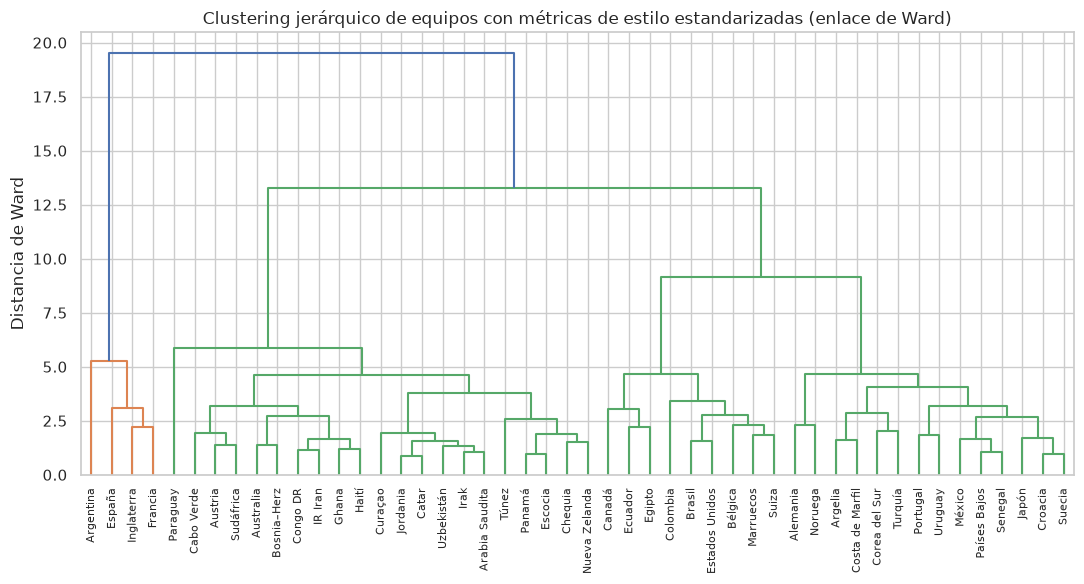

In [92]:
from scipy.cluster.hierarchy import linkage, dendrogram

STYLE_FEATS = [
    "possession",
    "shots",
    "shots_on_target",
    "goals",
    "fouls",
    "offsides",
    "crosses",
    "interceptions",
    "tackles_won",
    "cards_yellow"
]

X84 = teams.set_index("team")[STYLE_FEATS].astype(float)

Z84 = (
    X84 - X84.mean()
) / X84.std(ddof=0)  # Estandarizar cada métrica

labels84 = np.where(
    X84.index.map(traduccion_equipos).notna(),
    X84.index.map(traduccion_equipos),
    X84.index
)

link = linkage(
    Z84.values,
    method="ward"
)

fig, ax = plt.subplots(figsize=(11, 6))

dendrogram(
    link,
    labels=labels84.tolist(),
    leaf_rotation=90,
    ax=ax,
    color_threshold=0.7 * max(link[:, 2])
)

ax.set_title(
    "Clustering jerárquico de equipos con métricas de estilo estandarizadas (enlace de Ward)"
)

ax.set_ylabel(
    "Distancia de Ward"
)

plt.tight_layout()
plt.show()

## 85. Representación de equipos mediante PCA

Dos componentes capturan la mayor parte de la variación entre las métricas de estilo, proyectando cada equipo sobre un plano. Observa los equipos dominantes en posesión que se desplazan hacia un lado y los equipos de bloque bajo que juegan al contraataque en la dirección opuesta.


In [94]:
!pip install StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PCA_FEATS = [
    "possession",
    "shots",
    "shots_on_target",
    "goals",
    "fouls",
    "offsides",
    "crosses",
    "interceptions",
    "tackles_won",
    "cards_yellow"
]

Xp = teams.set_index("team")[PCA_FEATS].astype(float)

Zp = StandardScaler().fit_transform(Xp.values)

pca = PCA(
    n_components=2,
    random_state=0
)

emb = pca.fit_transform(Zp)

ev = pca.explained_variance_ratio_ * 100

emb85 = (
    pd.DataFrame(
        emb,
        columns=["PC1", "PC2"],
        index=Xp.index
    )
    .reset_index()
)

emb85["team_es"] = (
    emb85["team"]
    .map(traduccion_equipos)
    .fillna(emb85["team"])
)

fig = px.scatter(
    emb85,
    x="PC1",
    y="PC2",
    text="team_es",
    color="team",
    color_discrete_map=TEAM_COLOR,
    title=f"PCA de métricas de estilo de equipos estandarizadas (PC1 {ev[0]:.0f}%, PC2 {ev[1]:.0f}% de varianza)",
    labels={
        "PC1": f"PC1 ({ev[0]:.0f}%)",
        "PC2": f"PC2 ({ev[1]:.0f}%)"
    },
    **PLOTLY_KW,
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=11)
)

fig.update_layout(
    showlegend=False
)

fig.show()

print(
    f"Varianza acumulada PC1+PC2: {ev[:2].sum():.1f}%"
)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 7.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 3.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 5.2 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.3 MB/s eta 0:00:00
  Created wheel for StandardScaler: filename=standardscaler-0.5-py3-none-any.whl size=2649 sha256=f2e3205068621f648787e7ed70b21f7117cba6001fdee336abd14338ec2c9849
  Stored in directory: /home/yisusxd/.cache/pip/wheels/fe/cf/ba/03416e6fb72a0105069c33d9bf5a2ec1af9a41fe57fa7ec554
Successfully built StandardScaler


Varianza acumulada PC1+PC2: 79.5%


## 86. Arquetipos de equipos mediante K-means

Los arquetipos de estilo aparecen mediante agrupamiento: equipos con alta posesión y muchos tiros, equipos con gran efectividad de cara al gol y un grupo intermedio de volumen. Compara la posesión y los goles de cada centroide para observar que el estilo no es lo mismo que el resultado.


In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

KM_FEATS = [
    "possession",
    "shots",
    "shots_on_target",
    "goals",
    "fouls",
    "offsides",
    "crosses",
    "interceptions",
    "tackles_won",
    "cards_yellow"
]

Xk = teams.set_index("team")[KM_FEATS].astype(float)

Zk = StandardScaler().fit_transform(Xk.values)

K = 3

km = KMeans(
    n_clusters=K,
    n_init=10,
    random_state=0
)

labels = km.fit_predict(Zk)

arche = Xk.copy()

arche["cluster"] = labels

members = (
    arche
    .reset_index()
    .groupby("cluster")["team"]
    .apply(lambda s: ", ".join(sorted(s)))
    .rename("members")
)

centroids = arche.groupby("cluster")[KM_FEATS].mean()

summary = (
    centroids
    .join(members)
    .join(arche.groupby("cluster").size().rename("n"))
)

summary = summary.reset_index()

summary["members_es"] = (
    summary["members"]
    .str.split(", ")
    .apply(
        lambda teams_list: ", ".join(
            [
                traduccion_equipos.get(team, team)
                for team in teams_list
            ]
        )
    )
)

summary = summary[
    ["cluster", "n", "members_es"] + KM_FEATS
]

for c in KM_FEATS:
    summary[c] = summary[c].round(1)

summary.columns = [
    "Clúster",
    "Cantidad de equipos",
    "Equipos",
    "Posesión",
    "Tiros",
    "Tiros a puerta",
    "Goles",
    "Faltas",
    "Fuera de juego",
    "Centros",
    "Intercepciones",
    "Entradas ganadas",
    "Tarjetas amarillas"
]

display(summary)

,Clúster,Cantidad de equipos,Equipos,Posesión,Tiros,Tiros a puerta,Goles,Faltas,Fuera de juego,Centros,Intercepciones,Entradas ganadas,Tarjetas amarillas
0,0,27,"Argelia, Australia, Austria, Bosnia–Herz, Cabo...",42.6,32.5,10.0,3.1,40.1,5.5,46.2,30.3,35.0,4.8
1,1,4,"Argentina, Inglaterra, Francia, España",57.9,127.8,52.5,17.8,94.8,18.0,135.2,65.5,83.8,8.8
2,2,17,"Bélgica, Brasil, Canadá, Colombia, Ecuador, Eg...",55.9,69.9,23.9,8.3,55.8,8.6,90.6,38.7,43.9,6.2


## 87. Red de similitud entre equipos

Una red de equipos conectados cuando sus perfiles de estilo estandarizados están próximos entre sí, dentro del cuarto más reducido de todas las distancias por pares. La distribución mediante un diseño de resorte agrupa equipos con similitudes tácticas: observa cuáles comparten una misma huella de juego y cuáles quedan aislados.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 3.8 MB/s eta 0:00:0000:0100:01


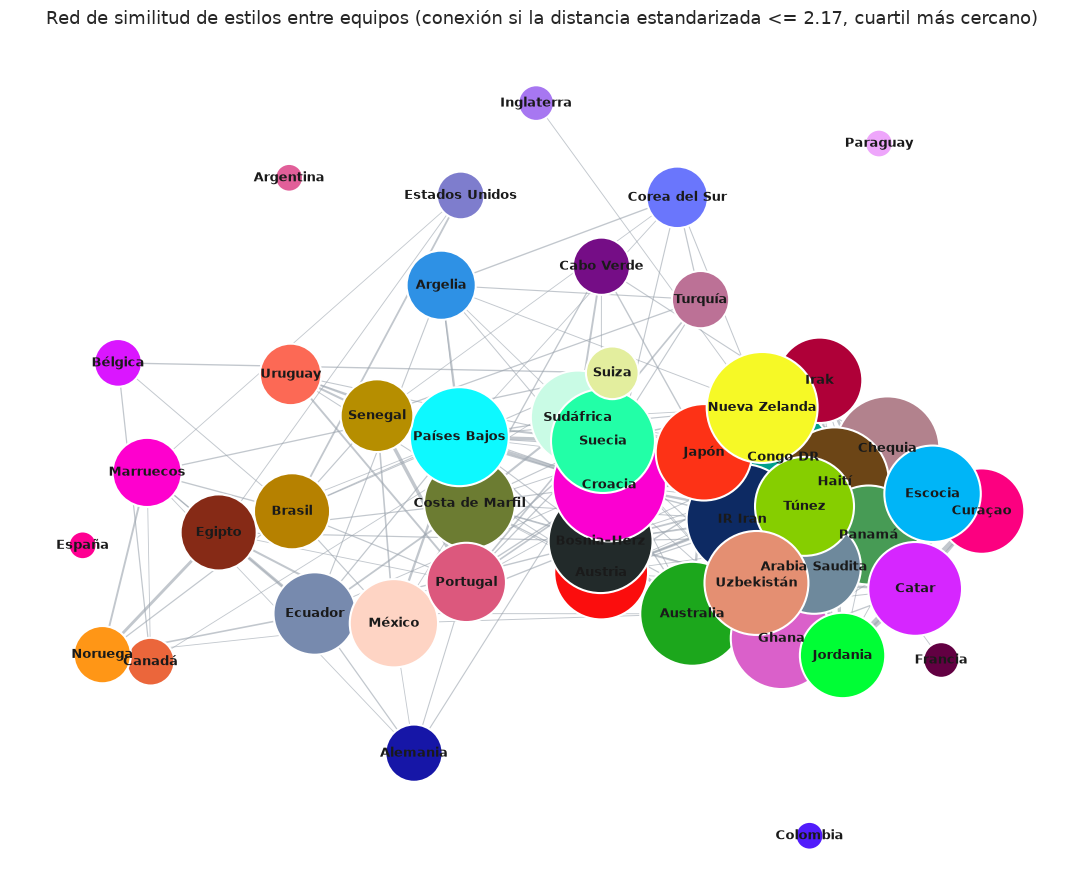

In [100]:
!pip install networkx
import networkx as nx
from scipy.spatial.distance import squareform, pdist

style_cols = [
    "possession",
    "shots",
    "shots_on_target",
    "crosses",
    "interceptions",
    "tackles_won",
    "fouls",
    "offsides"
]

S = teams.set_index("team")[style_cols].astype(float)

Z = (
    S - S.mean()
) / S.std(ddof=0)

D = pd.DataFrame(
    squareform(
        pdist(Z.values, metric="euclidean")
    ),
    index=Z.index,
    columns=Z.index
)

# Umbral de conexión: unir equipos cuya distancia de estilo esté en el cuartil más cercano.

iu = np.triu_indices_from(D.values, k=1)

thr = np.quantile(
    D.values[iu],
    0.25
)

G = nx.Graph()

for t in D.index:
    G.add_node(t)

for i, a in enumerate(D.index):
    for b in D.index[i + 1:]:
        d = D.loc[a, b]
        if d <= thr:
            G.add_edge(
                a,
                b,
                weight=1.0 / (d + 1e-6),
                dist=d
            )

deg = dict(G.degree())

# Etiquetas traducidas solamente para visualización
labels87 = {
    team: traduccion_equipos.get(team, team)
    for team in G.nodes()
}

fig, ax = plt.subplots(figsize=(11, 9))

pos = nx.spring_layout(
    G,
    weight="weight",
    seed=7,
    k=0.9
)

node_colors = [
    TEAM_COLOR[t]
    for t in G.nodes()
]

node_sizes = [
    400 + 260 * deg[t]
    for t in G.nodes()
]

ew = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

ew = np.array(ew)

ew = (
    0.6 + 3.2 *
    (ew - ew.min()) /
    (np.ptp(ew) + 1e-9)
    if len(ew)
    else ew
)

nx.draw_networkx_edges(
    G,
    pos,
    width=list(ew),
    edge_color="#9aa3ad",
    alpha=0.6,
    ax=ax
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="white",
    linewidths=1.5,
    ax=ax
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels87,
    font_size=9,
    font_weight="bold",
    ax=ax
)

ax.set_title(
    f"Red de similitud de estilos entre equipos (conexión si la distancia estandarizada <= {thr:.2f}, "
    f"cuartil más cercano)",
    fontsize=13
)

ax.axis("off")

plt.tight_layout()
plt.show()

## 88. Dominio del partido vs resultado

Un índice de dominio por equipo-partido: posesión, tiros, tiros a puerta y córners estandarizados mediante z-score, menos faltas. Las barras están coloreadas según lo que realmente ocurrió. Las estrellas marcan las sorpresas, equipos que dominaron el partido en los datos pero no lograron ganar.


In [105]:
home = matches.copy()

home_team = pd.DataFrame({
    "team": home["home_team"],
    "opponent": home["away_team"],
    "possession": home["home_possession"],
    "total_shots": home["home_total_shots"],
    "sot": home["home_sot"],
    "corners": home["home_corners"],
    "fouls": home["home_fouls"],
    "gf": home["home_score"],
    "ga": home["away_score"]
})

home_team["result"] = np.where(
    home_team["gf"] > home_team["ga"],
    "W",
    np.where(
        home_team["gf"] == home_team["ga"],
        "D",
        "L"
    )
)

away_team = pd.DataFrame({
    "team": home["away_team"],
    "opponent": home["home_team"],
    "possession": home["away_possession"],
    "total_shots": home["away_total_shots"],
    "sot": home["away_sot"],
    "corners": home["away_corners"],
    "fouls": home["away_fouls"],
    "gf": home["away_score"],
    "ga": home["home_score"]
})

away_team["result"] = np.where(
    away_team["gf"] > away_team["ga"],
    "W",
    np.where(
        away_team["gf"] == away_team["ga"],
        "D",
        "L"
    )
)

team_match = pd.concat(
    [
        home_team,
        away_team
    ],
    ignore_index=True
)

team_match.head()

,team,opponent,possession,total_shots,sot,corners,fouls,gf,ga,result
0,Mexico,South Africa,61,16,4,3,12,2.0,0.0,W
1,Korea Republic,Czechia,62,15,6,4,9,2.0,1.0,W
2,Canada,Bosnia–Herz,61,13,4,9,10,1.0,1.0,D
3,United States,Paraguay,65,16,6,3,13,4.0,1.0,W
4,Qatar,Switzerland,32,7,4,3,12,1.0,1.0,D


In [108]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

tm = team_match.copy()

# Estandarización
z = lambda s: (s - s.mean()) / s.std(ddof=0)

tm["dominance"] = (
    z(tm["possession"]) +
    z(tm["total_shots"]) +
    z(tm["sot"]) +
    z(tm["corners"]) -
    z(tm["fouls"])
).round(2)


# Etiqueta del partido para agrupar encuentros
tm["partido"] = tm.apply(
    lambda r: " vs ".join(sorted([r["team"], r["opponent"]])),
    axis=1
)


# Detectar equipos dominantes que no ganaron
sorpresas = []

for _, grupo in tm.groupby("partido"):
    dominante = grupo.sort_values(
        "dominance",
        ascending=False
    ).iloc[0]

    if dominante["result"] != "W":
        sorpresas.append(dominante["team"])


tm["sorpresa"] = (
    tm["team"].isin(sorpresas) &
    (tm["result"] != "W")
)


colores_resultado = {
    "W": "#2ca02c",
    "D": "#7f7f7f",
    "L": "#d62728"
}


nombres_resultado = {
    "W": "Victoria",
    "D": "Empate",
    "L": "Derrota"
}


fig = go.Figure()


for resultado in ["W", "D", "L"]:

    sub = tm[tm["result"] == resultado].copy()

    # Traducción solamente para visualización
    sub["equipo_es"] = (
        sub["team"]
        .map(traduccion_equipos)
        .fillna(sub["team"])
    )

    fig.add_trace(
        go.Bar(
            x=sub["equipo_es"],
            y=sub["dominance"],
            name=nombres_resultado[resultado],
            marker_color=colores_resultado[resultado],
            customdata=np.stack(
                [
                    sub["gf"],
                    sub["ga"],
                    sub["opponent"]
                ],
                axis=-1
            ),
            hovertemplate=(
                "%{x}<br>"
                "Índice de dominio: %{y:.2f}<br>"
                "Marcador: %{customdata[0]}-%{customdata[1]} "
                "vs %{customdata[2]}"
                "<extra></extra>"
            )
        )
    )


# Equipos dominantes que no ganaron
marcados = tm[tm["sorpresa"]].copy()

marcados["equipo_es"] = (
    marcados["team"]
    .map(traduccion_equipos)
    .fillna(marcados["team"])
)


fig.add_trace(
    go.Scatter(
        x=marcados["equipo_es"],
        y=marcados["dominance"] + 0.25,
        mode="markers",
        marker=dict(
            symbol="star",
            size=14,
            color="#ff7f0e"
        ),
        name="Dominó pero no ganó",
        hoverinfo="skip"
    )
)


fig.update_layout(
    title=(
        "Índice de dominio del partido vs resultado real "
        "(posesión + tiros + tiros a puerta + córners - faltas, estandarizados)"
    ),
    xaxis_title="Equipo",
    yaxis_title="Índice de dominio",
    xaxis_tickangle=-45,
    **PLOTLY_KW
)


fig.show()

## 90. Arquetipos de jugadores de campo

KMeans aplicado a tiros por partido, centros, intercepciones, entradas ganadas y faltas para jugadores de campo con suficientes minutos disputados. Emergen distintos roles: finalizadores, centradores, interceptores y recuperadores. El mapa de calor muestra el perfil de cada grupo; la tabla identifica un jugador representativo de cada arquetipo.

In [109]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Métricas utilizadas para definir perfiles de jugadores
feat = [
    "shots",
    "crosses",
    "interceptions",
    "tackles_won",
    "fouls",
    "fouled"
]

# Jugadores de campo con suficiente participación
out = players[
    (players["played"]) &
    (players["pos_main"] != "GK") &
    (players["minutes"] >= 45)
].copy()


X = (
    out[feat]
    .astype(float)
    .fillna(0.0)
    .to_numpy(copy=True)
)

Xs = StandardScaler().fit_transform(X)


# Crear 4 grupos de perfiles
km = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=7
)

out["cluster"] = km.fit_predict(Xs)


# Perfil promedio de cada grupo
prof = out.groupby("cluster")[feat].mean()


# Identificar la característica más representativa de cada cluster
profz = (
    prof - prof.mean()
) / prof.std(ddof=0)


nombres = {
    "shots": "finalizador",
    "crosses": "centrador",
    "interceptions": "interceptor",
    "tackles_won": "recuperador",
    "fouls": "infractor",
    "fouled": "provocador de faltas"
}


etiquetas = {}
usadas = set()

for c in profz.max(axis=1).sort_values(ascending=False).index:

    caracteristica = next(
        (
            f for f in profz.loc[c]
            .sort_values(ascending=False)
            .index
            if f not in usadas
        ),
        profz.loc[c].idxmax()
    )

    usadas.add(caracteristica)

    etiquetas[c] = (
        f"{nombres[caracteristica].title()} "
        f"(n={int((out['cluster'] == c).sum())})"
    )


out["arquetipo"] = out["cluster"].map(etiquetas)


# Perfil promedio con nombres visibles
perfil_arquetipo = prof.copy()
perfil_arquetipo.index = [
    etiquetas[c]
    for c in prof.index
]


# Mapa de calor
hm = px.imshow(
    perfil_arquetipo[feat],
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues",
    labels={
        "x": "Estadística por partido",
        "y": "Arquetipo",
        "color": "Promedio"
    },
    title=(
        "Arquetipos de jugadores de campo "
        "(KMeans, 4 grupos; jugadores con >= 45 minutos)"
    )
)

hm.show()


# Jugadores representativos de cada grupo
ejemplos = []

for c in prof.index:

    miembros = out[out["cluster"] == c]

    centroide = km.cluster_centers_[c]

    indices = miembros.index

    posiciones = [
        out.index.get_loc(i)
        for i in indices
    ]

    distancias = (
        (
            Xs[posiciones] - centroide
        ) ** 2
    ).sum(axis=1)


    mejor = indices[np.argmin(distancias)]


    ejemplos.append(
        {
            "arquetipo": etiquetas[c],
            "jugador_representativo": out.loc[mejor, "player"],
            "equipo": out.loc[mejor, "team"],
            **{
                f: out.loc[mejor, f]
                for f in feat
            }
        }
    )


ejemplares = pd.DataFrame(ejemplos)


display(ejemplares)

,arquetipo,jugador_representativo,equipo,shots,crosses,interceptions,tackles_won,fouls,fouled
0,Finalizador (n=83),Arda Güler,Türkiye,12.0,14.0,2.0,3.0,3.0,10.0
1,Interceptor (n=431),Mohammad Mohebi,IR Iran,2.0,1.0,1.0,1.0,1.0,1.0
2,Recuperador (n=48),Lisandro Martínez,Argentina,4.0,2.0,6.0,7.0,7.0,4.0
3,Infractor (n=234),Gonzalo Montiel,Argentina,1.0,4.0,3.0,3.0,4.0,2.0


## 91. Jugadores versátiles y líderes

Un vistazo a la flexibilidad y el liderazgo: jugadores que FBref etiqueta con dos posiciones, y los capitanes de los partidos cruzados con sus filas estadísticas. Observa la distribución de edades de los capitanes y qué jugadores polivalentes acumularon más minutos.

In [110]:
multi = players[
    (players["played"]) &
    (players["position"].str.contains(",", na=False))
].copy()

multi_tbl = (
    multi[
        [
            "player",
            "team",
            "position",
            "minutes",
            "goals",
            "assists",
            "tackles_won",
            "interceptions"
        ]
    ]
    .sort_values(
        ["position", "minutes"],
        ascending=[True, False]
    )
)

caps = pd.concat(
    [
        matches[
            ["home_team", "home_captain"]
        ].rename(
            columns={
                "home_team": "team",
                "home_captain": "player"
            }
        ),

        matches[
            ["away_team", "away_captain"]
        ].rename(
            columns={
                "away_team": "team",
                "away_captain": "player"
            }
        )
    ],
    ignore_index=True
)

cap_join = caps.merge(
    players[
        [
            "player",
            "team",
            "position",
            "age_years",
            "minutes",
            "goals",
            "assists",
            "cards_yellow",
            "tackles_won"
        ]
    ],
    on=["player", "team"],
    how="left"
)

cap_join["age_years"] = cap_join["age_years"].round(1)


print(
    f"Jugadores con múltiples posiciones que participaron: {len(multi)}"
)

print(
    multi_tbl.head(12)
    .rename(
        columns={
            "player": "Jugador",
            "team": "Equipo",
            "position": "Posición",
            "minutes": "Minutos",
            "goals": "Goles",
            "assists": "Asistencias",
            "tackles_won": "Entradas ganadas",
            "interceptions": "Intercepciones"
        }
    )
    .to_string(index=False)
)


print(
    f"\nCapitanes asociados con filas de jugadores: "
    f"{cap_join['minutes'].notna().sum()}/{len(cap_join)}"
)


display(
    multi_tbl.head(12)
    .rename(
        columns={
            "player": "Jugador",
            "team": "Equipo",
            "position": "Posición",
            "minutes": "Minutos",
            "goals": "Goles",
            "assists": "Asistencias",
            "tackles_won": "Entradas ganadas",
            "interceptions": "Intercepciones"
        }
    )
)


display(
    cap_join
    .sort_values("team")
    .rename(
        columns={
            "player": "Jugador",
            "team": "Equipo",
            "position": "Posición",
            "age_years": "Edad",
            "minutes": "Minutos",
            "goals": "Goles",
            "assists": "Asistencias",
            "cards_yellow": "Tarjetas amarillas",
            "tackles_won": "Entradas ganadas"
        }
    )
)

Jugadores con múltiples posiciones que participaron: 168
             Jugador        Equipo Posición  Minutos  Goles  Asistencias  Entradas ganadas  Intercepciones
       Joris Kayembe      Congo DR    DF,FW     45.0    0.0          0.0               4.0             4.0
     Alphonso Davies        Canada    DF,FW     16.0    0.0          0.0               0.0             0.0
   Jens Petter Hauge        Norway    DF,FW      8.0    0.0          0.0               0.0             0.0
     Denzel Dumfries   Netherlands    DF,MF    390.0    0.0          2.0               6.0             1.0
      Josip Stanišić       Croatia    DF,MF    360.0    0.0          1.0               2.0             5.0
     Victor Lindelöf        Sweden    DF,MF    356.0    0.0          0.0               1.0             4.0
    Antonee Robinson United States    DF,MF    348.0    0.0          0.0               4.0             6.0
   Martin Expérience         Haiti    DF,MF    270.0    0.0          0.0               

,Jugador,Equipo,Posición,Minutos,Goles,Asistencias,Entradas ganadas,Intercepciones
273,Joris Kayembe,Congo DR,"DF,FW",45.0,0.0,0.0,4.0,4.0
211,Alphonso Davies,Canada,"DF,FW",16.0,0.0,0.0,0.0,0.0
815,Jens Petter Hauge,Norway,"DF,FW",8.0,0.0,0.0,0.0,0.0
758,Denzel Dumfries,Netherlands,"DF,MF",390.0,0.0,2.0,6.0,1.0
294,Josip Stanišić,Croatia,"DF,MF",360.0,0.0,1.0,2.0,5.0
1088,Victor Lindelöf,Sweden,"DF,MF",356.0,0.0,0.0,1.0,4.0
1172,Antonee Robinson,United States,"DF,MF",348.0,0.0,0.0,4.0,6.0
565,Martin Expérience,Haiti,"DF,MF",270.0,0.0,0.0,6.0,4.0
591,Ramin Rezaeian,IR Iran,"DF,MF",270.0,2.0,1.0,5.0,2.0
853,Michael Amir Murillo,Panama,"DF,MF",270.0,0.0,0.0,3.0,1.0


,Equipo,Jugador,Posición,Edad,Minutos,Goles,Asistencias,Tarjetas amarillas,Entradas ganadas
122,Algeria,Aïssa Mandi,DF,34.0,360.0,0.0,0.0,0.0,3.0
147,Algeria,Riyad Mahrez,MF,35.0,262.0,2.0,1.0,0.0,2.0
71,Algeria,Riyad Mahrez,MF,35.0,262.0,2.0,1.0,0.0,2.0
188,Algeria,Riyad Mahrez,MF,35.0,262.0,2.0,1.0,0.0,2.0
99,Argentina,Lionel Messi,FW,38.0,740.0,8.0,4.0,0.0,10.0
...,...,...,...,...,...,...,...,...,...
38,Uruguay,Federico Valverde,MF,27.0,236.0,0.0,0.0,0.0,2.0
118,Uruguay,Federico Valverde,MF,27.0,236.0,0.0,0.0,0.0,2.0
23,Uzbekistan,Eldor Shomurodov,FW,30.0,269.0,1.0,0.0,0.0,4.0
172,Uzbekistan,Eldor Shomurodov,FW,30.0,269.0,1.0,0.0,0.0,4.0


## 92. Mapa de cobertura de plantilla

Qué tan profundo llega cada equipo a su banquillo. La matriz de minutos clasifica a los jugadores de cada selección según el tiempo en cancha; la tabla cuenta titulares frente a suplentes utilizados. Observa qué equipos agotan más el banquillo y cuáles apenas rotan.

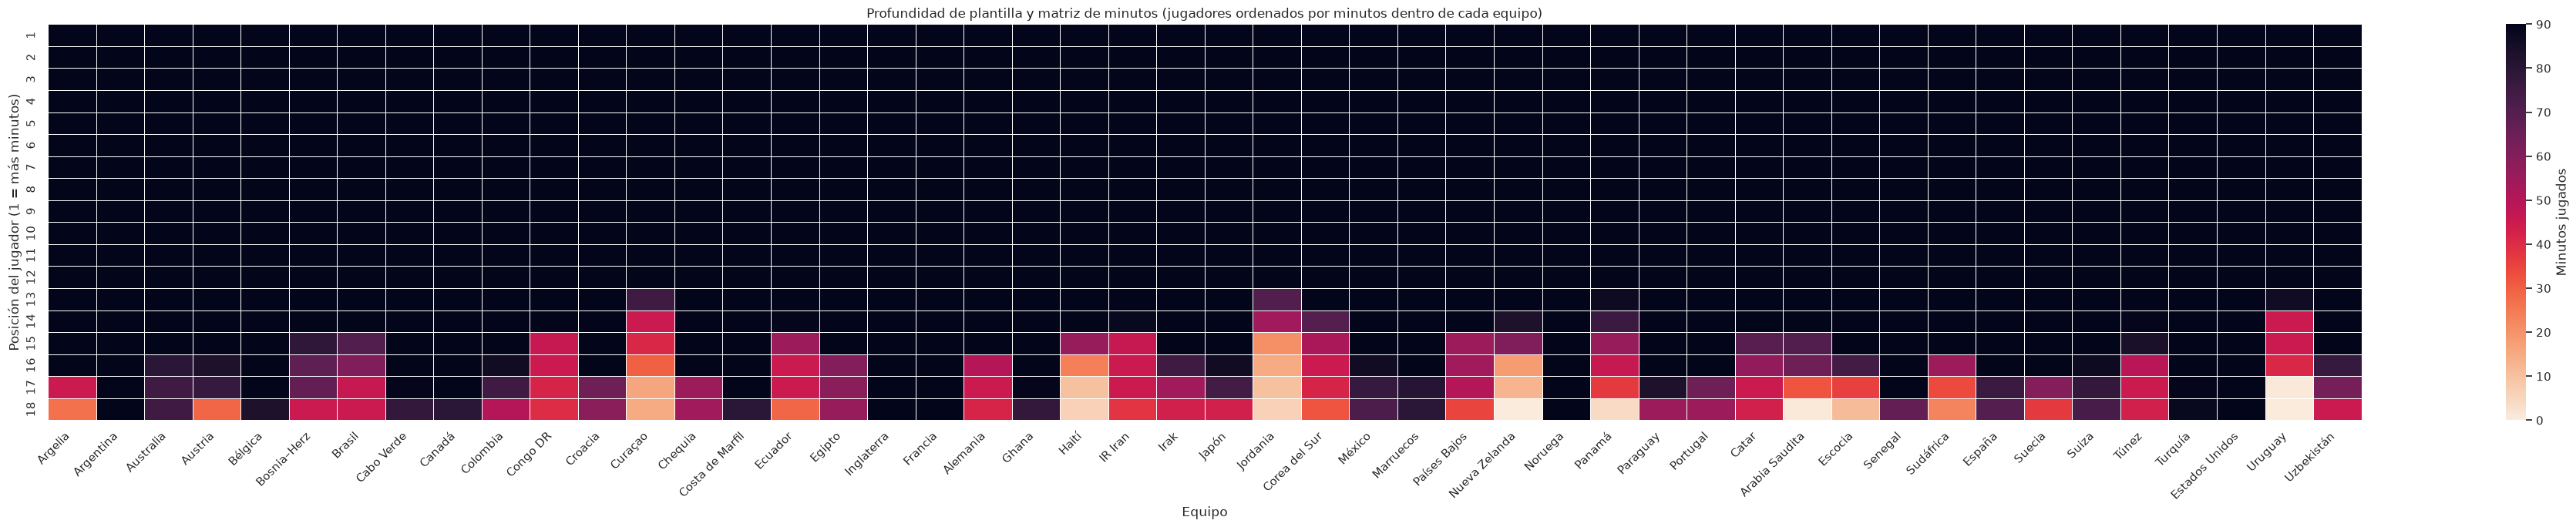

                 plantilla  utilizados  titulares  suplentes_utilizados
Argelia                 26          22         16                     6
Argentina               26          24         22                     2
Australia               26          23         17                     6
Austria                 26          20         15                     5
Bélgica                 26          23         18                     5
Bosnia–Herz             26          23         17                     6
Brasil                  26          22         15                     7
Cabo Verde              26          21         19                     2
Canadá                  26          22         17                     5
Colombia                26          21         14                     7
Congo DR                26          21         14                     7
Croacia                 26          19         16                     3
Curaçao                 26          22         13               

,plantilla,utilizados,titulares,suplentes_utilizados
Argelia,26,22,16,6
Argentina,26,24,22,2
Australia,26,23,17,6
Austria,26,20,15,5
Bélgica,26,23,18,5
Bosnia–Herz,26,23,17,6
Brasil,26,22,15,7
Cabo Verde,26,21,19,2
Canadá,26,22,17,5
Colombia,26,21,14,7


In [114]:
# Matriz de minutos por posición dentro de cada equipo
mat = (
    players.assign(mins=players["minutes"].fillna(0.0))
    .pivot_table(
        index="team",
        columns="pos_main",
        values="mins",
        aggfunc="sum"
    )
)


# Profundidad de plantilla: jugadores de la plantilla,
# jugadores utilizados, titulares y participación del banquillo.
depth = (
    players.groupby("team")
    .agg(
        plantilla=("player", "size"),
        utilizados=("played", "sum"),
        titulares=("games_starts", lambda s: int((s.fillna(0) >= 1).sum())),
        minutos_suplentes=("minutes", lambda s: float(s.fillna(0)[s.fillna(0) < 90].sum()))
    )
    .reindex(TEAM_ORDER)
)

depth["suplentes_utilizados"] = depth["utilizados"] - depth["titulares"]


# Matriz de minutos: jugadores ordenados por minutos totales dentro de cada equipo.
# Se muestran los 18 jugadores con más minutos de cada selección.
pm = players.assign(mins=players["minutes"].fillna(0.0)).copy()

pm = pm.sort_values(
    ["team", "mins"],
    ascending=[True, False]
)

pm["puesto"] = pm.groupby("team").cumcount() + 1

pm = pm[pm["puesto"] <= 18]


M = (
    pm.pivot_table(
        index="puesto",
        columns="team",
        values="mins",
        aggfunc="first"
    )
    .reindex(columns=TEAM_ORDER)
)


# Traducir nombres de países únicamente para mostrar en el gráfico.
# No modifica la columna original "team".
equipos_es = (
    pd.Index(M.columns)
    .map(traduccion_equipos)
)

equipos_es = np.where(
    pd.isna(equipos_es),
    M.columns,
    equipos_es
)

M.columns = equipos_es


# Crear mapa de calor de profundidad de plantilla
fig, ax = plt.subplots(
    figsize=(max(13, 0.8 * len(TEAM_ORDER)), 7)
)

sns.heatmap(
    M,
    cmap="rocket_r",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Minutos jugados"},
    ax=ax,
    mask=M.isna(),
    vmin=0,
    vmax=90
)

ax.set_title(
    "Profundidad de plantilla y matriz de minutos "
    "(jugadores ordenados por minutos dentro de cada equipo)"
)

ax.set_xlabel("Equipo")
ax.set_ylabel("Posición del jugador (1 = más minutos)")


plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# Tabla resumen de profundidad de plantilla con nombres de países traducidos
depth_display = depth.copy()

depth_display.index = (
    depth_display.index
    .map(traduccion_equipos)
)

depth_display.index = np.where(
    pd.isna(depth_display.index),
    depth.index,
    depth_display.index
)


print(
    depth_display[
        [
            "plantilla",
            "utilizados",
            "titulares",
            "suplentes_utilizados"
        ]
    ]
    .to_string()
)


display(
    depth_display[
        [
            "plantilla",
            "utilizados",
            "titulares",
            "suplentes_utilizados"
        ]
    ]
)

## 93. Participación en goles y aporte al equipo

Quién carga con el ataque de su selección. Las barras apilan goles sobre asistencias para mostrar a los jugadores con mayor participación ofensiva; al pasar el cursor se observa qué porcentaje de los goles de su equipo representa cada anotador. Busca dependencias de un solo jugador, donde un nombre concentra gran parte de la producción ofensiva.

In [115]:
df = played.copy()

# Participaciones de gol: goles + asistencias
df["participaciones_gol"] = (
    df["goals"].fillna(0) +
    df["assists"].fillna(0)
)

tg = teams.set_index("team")["goals"]

df["goles_equipo"] = df["team"].map(tg)

# Porcentaje de goles del equipo aportados por cada jugador
df["aporte_goles_equipo"] = np.where(
    df["goles_equipo"] > 0,
    df["goals"].fillna(0) / df["goles_equipo"],
    0.0
)


top = (
    df[df["participaciones_gol"] > 0]
    .sort_values(
        ["participaciones_gol", "goals", "aporte_goles_equipo"],
        ascending=[False, False, False]
    )
    .head(20)
    .copy()
)

top = top.iloc[::-1]


# Etiqueta traducida únicamente para mostrar
top["equipo_es"] = (
    top["team"]
    .map(traduccion_equipos)
    .fillna(top["team"])
)

top["etiqueta"] = (
    top["player"] +
    " (" +
    top["equipo_es"] +
    ")"
)


top["porcentaje_goles"] = (
    (top["aporte_goles_equipo"] * 100)
    .round(0)
    .astype(int)
    .astype(str)
    + "% de los goles del equipo"
)


fig = go.Figure()


fig.add_trace(
    go.Bar(
        x=top["goals"].fillna(0),
        y=top["etiqueta"],
        orientation="h",
        name="Goles",
        marker_color="#1b9e77",
        customdata=top["porcentaje_goles"],
        hovertemplate=(
            "%{y}<br>"
            "Goles: %{x}<br>"
            "%{customdata}"
            "<extra></extra>"
        )
    )
)


fig.add_trace(
    go.Bar(
        x=top["assists"].fillna(0),
        y=top["etiqueta"],
        orientation="h",
        name="Asistencias",
        marker_color="#d95f02",
        hovertemplate=(
            "%{y}<br>"
            "Asistencias: %{x}"
            "<extra></extra>"
        )
    )
)


fig.update_layout(
    barmode="stack",
    title="Top 20 por participaciones de gol (goles + asistencias)",
    xaxis_title="Participaciones de gol",
    yaxis_title="",
    legend_title="",
    height=720,
    **PLOTLY_KW
)

fig.show()

## 94. Seguimiento de la carrera por la Bota de Oro

La carrera por la Bota de Oro, definida por las reglas de adidas: más goles, después asistencias y finalmente menos minutos jugados como criterio de desempate. El podio separa los goles de jugada de los penales para mostrar cómo se construyó la ventaja.

In [116]:
df = played.copy()

# Goles anotados
df["g"] = df["goals"].fillna(0)

df = df[df["g"] > 0].copy()


# Clasificación de la Bota de Oro:
# 1) Más goles
# 2) Más asistencias
# 3) Menos minutos jugados
board = (
    df.sort_values(
        ["g", "assists", "minutes"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)


board.insert(
    0,
    "puesto",
    board.index + 1
)


# Goles de jugada (sin penales)
board["goles_jugada"] = (
    board["g"] -
    board["pens_made"].fillna(0)
)


tabla_bota_oro = (
    board.head(12)
    [
        [
            "puesto",
            "player",
            "team",
            "g",
            "assists",
            "minutes",
            "pens_made",
            "goles_jugada"
        ]
    ]
    .rename(
        columns={
            "puesto": "Puesto",
            "player": "Jugador",
            "team": "Equipo",
            "g": "Goles",
            "assists": "Asistencias",
            "minutes": "Minutos",
            "pens_made": "Goles de penal",
            "goles_jugada": "Goles de jugada"
        }
    )
)


# Traducir equipos únicamente en la tabla visible
tabla_bota_oro["Equipo"] = (
    tabla_bota_oro["Equipo"]
    .map(traduccion_equipos)
    .fillna(tabla_bota_oro["Equipo"])
)


podium = board.head(3).copy()


podium["equipo_es"] = (
    podium["team"]
    .map(traduccion_equipos)
    .fillna(podium["team"])
)


podium["etiqueta"] = (
    podium["player"] +
    "<br>(" +
    podium["equipo_es"] +
    ")"
)


fig = go.Figure()


fig.add_trace(
    go.Bar(
        x=podium["etiqueta"],
        y=podium["goles_jugada"],
        name="Goles de jugada",
        marker_color="#386cb0",
        text=podium["goles_jugada"].astype(int),
        textposition="inside"
    )
)


fig.add_trace(
    go.Bar(
        x=podium["etiqueta"],
        y=podium["pens_made"].fillna(0),
        name="Goles de penal",
        marker_color="#f0027f",
        text=podium["pens_made"].fillna(0).astype(int),
        textposition="inside"
    )
)


fig.update_layout(
    barmode="stack",
    title=(
        f"Podio de la Bota de Oro: líder "
        f"{podium.iloc[0]['player']} "
        f"({int(podium.iloc[0]['g'])} goles)"
    ),
    xaxis_title="",
    yaxis_title="Goles",
    legend_title="Tipo de gol",
    height=460,
    **PLOTLY_KW
)

fig.show()


from IPython.display import display

display(tabla_bota_oro)

,Puesto,Jugador,Equipo,Goles,Asistencias,Minutos,Goles de penal,Goles de jugada
0,1,Kylian Mbappé,Francia,10.0,4.0,695.0,1.0,9.0
1,2,Lionel Messi,Argentina,8.0,4.0,740.0,0.0,8.0
2,3,Jude Bellingham,Inglaterra,7.0,1.0,614.0,0.0,7.0
3,4,Erling Haaland,Noruega,7.0,0.0,465.0,0.0,7.0
4,5,Ousmane Dembélé,Francia,6.0,2.0,592.0,0.0,6.0
5,6,Harry Kane,Inglaterra,6.0,1.0,652.0,2.0,4.0
6,7,Mikel Oyarzabal,España,5.0,1.0,601.0,1.0,4.0
7,8,Ismaila Sarr,Senegal,4.0,1.0,364.0,0.0,4.0
8,9,Julián Quiñones,México,4.0,1.0,410.0,0.0,4.0
9,10,Vinicius Júnior,Brasil,4.0,1.0,440.0,0.0,4.0


## 95. Equipo de la jornada

Un once seleccionado únicamente con base en los datos. Cada jugador se estandariza mediante puntuaciones z comparándolo con otros jugadores de su misma posición utilizando métricas adaptadas a su rol. Después se seleccionan el mejor portero y una formación 4-3-3 para formar el equipo ideal. Pasa el cursor sobre cada jugador para ver su puntuación compuesta; recuerda que la muestra es limitada.

In [117]:
df = played[played["minutes"].fillna(0) >= 45].copy()

ROLE = {
    "GK": ["gk_saves", "gk_save_pct", "gk_clean_sheets"],
    "DF": ["tackles_won", "interceptions", "fouled", "goals", "assists"],
    "MF": ["assists", "goals", "shots_on_target", "crosses", "tackles_won", "interceptions"],
    "FW": ["goals", "assists", "shots_on_target", "shots", "fouled"],
}

ROLE_NAMES = {
    "GK": "Portero",
    "DF": "Defensa",
    "MF": "Mediocampista",
    "FW": "Delantero"
}

def zscore_within(frame, cols):
    out = pd.Series(0.0, index=frame.index)

    for c in cols:
        v = frame[c].astype(float).fillna(0.0)
        sd = v.std(ddof=0)

        z = (v - v.mean()) / sd if sd > 0 else v * 0.0
        out = out + z

    return out / len(cols)


pieces = []

for pos, cols in ROLE.items():

    if pos == "GK":
        sub = gks[gks["gk_minutes"].fillna(0) >= 45].copy()
    else:
        sub = df[df["pos_main"] == pos].copy()

    if len(sub):
        sub["composite"] = zscore_within(sub, cols)
        sub["role"] = pos

        pieces.append(
            sub[
                ["player", "team", "role", "composite", "minutes"]
            ]
        )


allp = pd.concat(
    pieces,
    ignore_index=True
)


def pick(role, n):
    return (
        allp[allp["role"] == role]
        .sort_values("composite", ascending=False)
        .head(n)
    )


xi = pd.concat(
    [
        pick("GK", 1),
        pick("DF", 4),
        pick("MF", 3),
        pick("FW", 3)
    ],
    ignore_index=True
)


# Coordenadas para formación 4-3-3
coords = {
    "GK": [(50, 5)],
    "DF": [(18, 26), (39, 22), (61, 22), (82, 26)],
    "MF": [(28, 52), (50, 50), (72, 52)],
    "FW": [(25, 82), (50, 86), (75, 82)],
}


ROLE_COLOR = {
    "GK": "#7570b3",
    "DF": "#1b9e77",
    "MF": "#d95f02",
    "FW": "#e7298a"
}


fig = go.Figure()


# Campo
fig.add_shape(
    type="rect",
    x0=0,
    y0=0,
    x1=100,
    y1=100,
    line=dict(color="#2a7d2a", width=2),
    fillcolor="#e8f5e8"
)

fig.add_shape(
    type="line",
    x0=0,
    y0=50,
    x1=100,
    y1=50,
    line=dict(color="#2a7d2a", width=1)
)

fig.add_shape(
    type="circle",
    x0=40,
    y0=40,
    x1=60,
    y1=60,
    line=dict(color="#2a7d2a", width=1)
)

fig.add_shape(
    type="rect",
    x0=22,
    y0=0,
    x1=78,
    y1=16,
    line=dict(color="#2a7d2a", width=1)
)

fig.add_shape(
    type="rect",
    x0=22,
    y0=84,
    x1=78,
    y1=100,
    line=dict(color="#2a7d2a", width=1)
)


for role, pts in coords.items():

    rows = (
        xi[xi["role"] == role]
        .reset_index(drop=True)
    )

    for i, (x, y) in enumerate(pts):

        if i >= len(rows):
            continue

        r = rows.iloc[i]

        fig.add_trace(
            go.Scatter(
                x=[x],
                y=[y],
                mode="markers+text",
                marker=dict(
                    size=22,
                    color=ROLE_COLOR[role],
                    line=dict(
                        color="white",
                        width=2
                    )
                ),
                text=[
                    f"{r['player']}<br>"
                    f"<span style='font-size:9px'>{r['team'].map(traduccion_equipos) if False else r['team']}</span>"
                ],
                textposition="bottom center",
                showlegend=False,
                hovertemplate=(
                    f"{r['player']} ({r['team']})<br>"
                    f"Puntuación compuesta: {r['composite']:.2f}"
                    "<extra></extra>"
                )
            )
        )


fig.update_layout(
    title=(
        "Equipo de la jornada: mejor portero más formación 4-3-3 "
        "(puntuaciones z dentro de cada posición, mínimo 45 minutos)"
    ),

    xaxis=dict(
        visible=False,
        range=[-5, 105]
    ),

    yaxis=dict(
        visible=False,
        range=[-8, 108]
    ),

    height=720,
    width=560,
    **PLOTLY_KW
)


fig.show()

## 96. Clasificación compuesta de impacto del jugador

Una puntuación de impacto transparente: el ataque representa la mitad del valor, mientras que la creación y la defensa representan un cuarto cada una. Todas las métricas se estandarizan mediante puntuaciones z dentro de cada posición, permitiendo que cada jugador compita únicamente contra futbolistas de su mismo rol. La clasificación debe interpretarse como descriptiva, no como predictiva.

In [118]:
df = played[played["pos_main"] != "GK"].copy()

GRUPOS = {
    "ataque": {
        "goals": 1.0,
        "assists": 0.8,
        "shots_on_target": 0.5
    },
    "creacion": {
        "crosses": 0.4,
        "fouled": 0.4
    },
    "defensa": {
        "interceptions": 0.5,
        "tackles_won": 0.5
    },
}

PESO = {
    "ataque": 0.5,
    "creacion": 0.25,
    "defensa": 0.25
}


def z_within_pos(frame, col):
    out = pd.Series(0.0, index=frame.index)

    for pos, idx in frame.groupby("pos_main").groups.items():
        v = frame.loc[idx, col].astype(float).fillna(0.0)
        sd = v.std(ddof=0)

        out.loc[idx] = (
            (v - v.mean()) / sd
            if sd > 0
            else 0.0
        )

    return out


df["impacto"] = 0.0


for grupo, cols in GRUPOS.items():

    bloque = pd.Series(
        0.0,
        index=df.index
    )

    for c, w in cols.items():
        bloque = bloque + w * z_within_pos(df, c)

    df["impacto"] = df["impacto"] + PESO[grupo] * bloque


top = (
    df.sort_values(
        "impacto",
        ascending=False
    )
    .head(25)
    .iloc[::-1]
    .copy()
)


top["etiqueta"] = (
    top["player"]
    + " ("
    + top["team"].map(traduccion_equipos).fillna(top["team"])
    + ")"
)


COLOR_POSICION = {
    "DF": "#1b9e77",
    "MF": "#d95f02",
    "FW": "#e7298a"
}


NOMBRE_POSICION = {
    "DF": "Defensa",
    "MF": "Mediocampista",
    "FW": "Delantero"
}


fig = go.Figure()


for pos, color in COLOR_POSICION.items():

    sub = top[top["pos_main"] == pos]

    fig.add_trace(
        go.Bar(
            x=sub["impacto"],
            y=sub["etiqueta"],
            orientation="h",
            name=NOMBRE_POSICION[pos],
            marker_color=color,
            hovertemplate=(
                "%{y}<br>"
                "Impacto z: %{x:.2f}"
                "<extra></extra>"
            )
        )
    )


fig.update_layout(
    barmode="stack",

    title=(
        "Clasificación compuesta de impacto del jugador "
        "(puntuación z ponderada dentro de cada posición: "
        "ataque 50% / creación 25% / defensa 25%)"
    ),

    xaxis_title="Impacto (puntuación z ponderada)",
    yaxis_title="",
    legend_title="Posición",

    height=760,
    **PLOTLY_KW
)


fig.show()

## 97. Impacto desde el banquillo

El banquillo también cambia los partidos. Estos jugadores comenzaron como suplentes, entraron durante pocos minutos y aun así lograron marcar un gol o dar una asistencia. Las tasas por minuto pueden favorecer demasiado a las apariciones muy cortas, así que deben interpretarse como destellos de calidad, no como una medida definitiva de rendimiento.

In [119]:
df = played.copy()

# Jugadores que entraron desde el banquillo:
# no fueron titulares, jugaron menos de 45 minutos y tuvieron participación
subs = df[
    (df["games_starts"].fillna(0) == 0) &
    (df["minutes"].fillna(0) < 45) &
    (df["minutes"].fillna(0) > 0)
].copy()


subs["participaciones_gol"] = (
    subs["goals"].fillna(0) +
    subs["assists"].fillna(0)
)


subs["participaciones_por_minuto"] = (
    subs["participaciones_gol"] /
    subs["minutes"].replace(0, np.nan)
)


supersubs = (
    subs[subs["participaciones_gol"] > 0]
    .sort_values(
        ["participaciones_gol", "participaciones_por_minuto"],
        ascending=False
    )
    .copy()
)


supersubs = supersubs.iloc[::-1]


supersubs["etiqueta"] = (
    supersubs["player"]
    + " ("
    + supersubs["team"].map(traduccion_equipos).fillna(supersubs["team"])
    + ", "
    + supersubs["minutes"].astype(int).astype(str)
    + "')"
)


fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    subplot_titles=(
        "Participaciones de gol",
        "Participaciones por minuto"
    )
)


fig.add_trace(
    go.Bar(
        x=supersubs["participaciones_gol"],
        y=supersubs["etiqueta"],
        orientation="h",
        marker_color="#386cb0",
        name="Participaciones de gol",
        text=supersubs["participaciones_gol"].astype(int),
        textposition="outside"
    ),
    row=1,
    col=1
)


fig.add_trace(
    go.Bar(
        x=supersubs["participaciones_por_minuto"],
        y=supersubs["etiqueta"],
        orientation="h",
        marker_color="#fdb462",
        name="Participaciones/minuto",
        hovertemplate=(
            "%{y}<br>"
            "%{x:.3f} participaciones por minuto"
            "<extra></extra>"
        )
    ),
    row=1,
    col=2
)


fig.update_layout(
    title=(
        "Impacto desde el banquillo: suplentes "
        "(titularidades = 0, menos de 45 minutos, con gol o asistencia)"
    ),
    showlegend=False,
    height=460,
    **PLOTLY_KW
)


fig.update_xaxes(
    title_text="Participaciones de gol",
    row=1,
    col=1
)


fig.update_xaxes(
    title_text="Participaciones por minuto "
               "(muestra pequeña, alta variabilidad)",
    row=1,
    col=2
)


fig.show()

## 98. Definición sin xG

Sin utilizar xG, la definición se analiza mediante el volumen de tiros frente al rendimiento obtenido. Cada punto representa a un jugador con dos o más disparos; la línea discontinua muestra la tasa de goles por tiro del torneo. Por encima de ella aparecen los jugadores más efectivos, mientras que en el extremo derecho sin goles se encuentran los menos eficientes.

In [120]:
df = played[played["shots"].fillna(0) >= 2].copy()

# Tasa promedio de goles por tiro
baseline = (
    played["goals"].fillna(0).sum() /
    played["shots"].fillna(0).sum()
)

df["goles_esperados_referencia"] = (
    df["shots"].fillna(0) * baseline
)

df["diferencia_definicion"] = (
    df["goals"].fillna(0) -
    df["goles_esperados_referencia"]
)

df["estado"] = np.where(
    df["goals"].fillna(0) > df["goles_esperados_referencia"],
    "Por encima de la referencia",
    np.where(
        df["goals"].fillna(0) == 0,
        "Poco efectivo (sin goles)",
        "Por debajo de la referencia"
    )
)


COLORES = {
    "Por encima de la referencia": "#1b9e77",
    "Por debajo de la referencia": "#7570b3",
    "Poco efectivo (sin goles)": "#d95f02"
}


fig = go.Figure()


for estado, color in COLORES.items():

    sub = df[df["estado"] == estado]

    fig.add_trace(
        go.Scatter(
            x=sub["shots"],
            y=sub["goals"],
            mode="markers",
            name=estado,
            marker=dict(
                size=11,
                color=color,
                line=dict(
                    color="white",
                    width=1
                )
            ),
            text=(
                sub["player"]
                + " ("
                + sub["team"].map(traduccion_equipos).fillna(sub["team"])
                + ")"
            ),
            hovertemplate=(
                "%{text}<br>"
                "Tiros: %{x}<br>"
                "Goles: %{y}"
                "<extra></extra>"
            )
        )
    )


xs = np.array(
    [
        df["shots"].min(),
        df["shots"].max()
    ]
)


fig.add_trace(
    go.Scatter(
        x=xs,
        y=xs * baseline,
        mode="lines",
        name=f"Referencia del torneo ({baseline:.3f} goles/tiro)",
        line=dict(
            color="#333333",
            dash="dash"
        )
    )
)


# Jugadores más destacados por eficiencia o ineficacia
notable = pd.concat(
    [
        df.nlargest(4, "diferencia_definicion"),
        df[
            df["estado"] == "Poco efectivo (sin goles)"
        ].nlargest(4, "shots")
    ]
)


for _, r in notable.iterrows():

    fig.add_annotation(
        x=r["shots"],
        y=r["goals"],
        text=r["player"].split()[-1],
        showarrow=True,
        arrowhead=1,
        font=dict(size=10),
        ax=18,
        ay=-14
    )


fig.update_layout(
    title=(
        "Definición sin xG: tiros vs goles "
        "(mínimo 2 tiros). La definición es muy variable en un solo partido"
    ),
    xaxis_title="Tiros",
    yaxis_title="Goles",
    legend_title="",
    height=560,
    **PLOTLY_KW
)


fig.show()

## 99. Riesgo disciplinario

Agresividad y sanciones lado a lado. Cada jugador de campo que cometió una falta se representa comparando las infracciones cometidas con las tarjetas recibidas; las tarjetas por falta separan a los jugadores más disciplinariamente arriesgados de aquellos que simplemente participan mucho en el juego. Como las tarjetas son poco frecuentes, incluso una sola amonestación puede colocar a un jugador en la zona de mayor riesgo.

In [121]:
df = played[played["pos_main"] != "GK"].copy()

df["tarjetas_totales"] = (
    df["cards_yellow"].fillna(0) +
    df["cards_red"].fillna(0)
)

df = df[df["fouls"].fillna(0) >= 1].copy()

df["ratio_riesgo"] = (
    df["tarjetas_totales"] /
    df["fouls"].replace(0, np.nan)
)

df["categoria"] = np.where(
    df["tarjetas_totales"] > 0,
    np.where(
        df["ratio_riesgo"] >= 0.5,
        "Cínico (muchas tarjetas por falta)",
        "Amonestado"
    ),
    "Intenso pero limpio"
)

COLORES = {
    "Cínico (muchas tarjetas por falta)": "#d7191c",
    "Amonestado": "#fdae61",
    "Intenso pero limpio": "#2c7bb6"
}

df["tarjetas_jitter"] = (
    df["tarjetas_totales"] +
    np.random.RandomState(0).uniform(
        -0.04,
        0.04,
        len(df)
    )
)

df["etiqueta"] = (
    df["player"]
    + " ("
    + df["team"].map(traduccion_equipos).fillna(df["team"])
    + "), ratio "
    + df["ratio_riesgo"].round(2).astype(str)
)


fig = go.Figure()

for categoria, color in COLORES.items():

    sub = df[df["categoria"] == categoria]

    fig.add_trace(
        go.Scatter(
            x=sub["fouls"],
            y=sub["tarjetas_jitter"],
            mode="markers",
            name=categoria,
            marker=dict(
                size=10,
                color=color,
                line=dict(
                    color="white",
                    width=1
                )
            ),
            text=sub["etiqueta"],
            hovertemplate=(
                "%{text}<br>"
                "Faltas cometidas: %{x}<extra></extra>"
            )
        )
    )


fig.update_layout(
    title=(
        "Riesgo disciplinario: faltas cometidas vs tarjetas "
        "(jugadores de campo con al menos una falta)"
    ),
    xaxis_title="Faltas cometidas",
    yaxis_title="Tarjetas (amarillas + rojas, con desplazamiento)",
    legend_title="Categoría",
    height=520,
    **PLOTLY_KW
)

fig.show()

## 100. Jugadores más buscados

Los jugadores que los defensores no pudieron detener legalmente. 
Se ordenan por faltas recibidas y después se comparan contra participaciones de gol. 
Sin acciones de creación de tiro disponibles, las faltas recibidas son el mejor indicador de peligro con balón.

In [122]:
df = played.copy()

# Participaciones de gol
df["participaciones_gol"] = (
    df["goals"].fillna(0) +
    df["assists"].fillna(0)
)

df["faltas_recibidas"] = df["fouled"].fillna(0)

ranked = df.sort_values(
    "faltas_recibidas",
    ascending=False
)

# Correlación entre faltas recibidas y participaciones de gol
corr = (
    df[df["faltas_recibidas"] > 0]
    [["faltas_recibidas", "participaciones_gol"]]
    .corr()
    .iloc[0, 1]
)


# Etiquetas traducidas para visualización
df["equipo_es"] = (
    df["team"]
    .map(traduccion_equipos)
    .fillna(df["team"])
)


fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["faltas_recibidas"],
        y=df["participaciones_gol"],
        mode="markers",
        marker=dict(
            size=10,
            color=df["participaciones_gol"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(
                title="PG"
            ),
            line=dict(
                color="white",
                width=1
            )
        ),
        text=(
            df["player"] +
            " (" +
            df["equipo_es"] +
            ")"
        ),
        hovertemplate=(
            "%{text}<br>"
            "Faltas recibidas: %{x}<br>"
            "Participaciones de gol: %{y}"
            "<extra></extra>"
        )
    )
)


# Etiquetar jugadores destacados
notable = pd.concat(
    [
        ranked.head(8),
        df[df["participaciones_gol"] > 0]
        .nlargest(6, "faltas_recibidas")
    ]
).drop_duplicates("player")


for _, r in notable.iterrows():
    fig.add_annotation(
        x=r["faltas_recibidas"],
        y=r["participaciones_gol"],
        text=r["player"].split()[-1],
        showarrow=True,
        arrowhead=1,
        font=dict(size=10),
        ax=16,
        ay=-12
    )


fig.update_layout(
    title=(
        f"Jugadores más buscados: faltas recibidas vs participaciones de gol "
        f"(r = {corr:.2f}). Indicador de peligro con balón"
    ),
    xaxis_title="Faltas recibidas",
    yaxis_title="Participaciones de gol",
    height=560,
    **PLOTLY_KW
)

fig.show()

## 101. Motor de recuperación de balón

La defensa rara vez aparece en un marcador tradicional, por eso aquí se muestra el motor de recuperación:
intercepciones más entradas ganadas. Los mejores jugadores aparecen con las acciones defensivas separadas por tipo.
Observa cómo la lista se inclina hacia defensas y mediocampistas de contención.

In [123]:
d = played.copy()

# Acciones defensivas totales
d["acciones_defensivas"] = (
    d["interceptions"].fillna(0) +
    d["tackles_won"].fillna(0)
)

top = (
    d.sort_values(
        "acciones_defensivas",
        ascending=False
    )
    .head(20)
    .iloc[::-1]
)

# Traducción de equipos solo para visualización
top["equipo_es"] = (
    top["team"]
    .map(traduccion_equipos)
    .fillna(top["team"])
)

# Etiqueta jugador + equipo
top["etiqueta"] = (
    top["player"] +
    " (" +
    top["equipo_es"] +
    ")"
)


fig = go.Figure()


fig.add_bar(
    y=top["etiqueta"],
    x=top["interceptions"].fillna(0),
    name="Intercepciones",
    orientation="h",
    marker_color="#4c78a8",
    hovertemplate=(
        "%{y}<br>"
        "Intercepciones: %{x}"
        "<extra></extra>"
    )
)


fig.add_bar(
    y=top["etiqueta"],
    x=top["tackles_won"].fillna(0),
    name="Entradas ganadas",
    orientation="h",
    marker_color="#f58518",
    hovertemplate=(
        "%{y}<br>"
        "Entradas ganadas: %{x}"
        "<extra></extra>"
    )
)


fig.update_layout(
    barmode="stack",
    title=(
        "Motor de recuperación de balón: "
        "top 20 por intercepciones + entradas ganadas"
    ),
    xaxis_title="Acciones defensivas",
    yaxis_title="",
    legend_title="Acción",
    height=640,
    **PLOTLY_KW
)

fig.show()

## 102. Curva de experiencia

Cada jugador que tuvo minutos aparece representado por su edad y minutos disputados.
La línea punteada marca a quienes completaron partidos completos de 90 minutos;
la concentración de jugadores jóvenes con pocos minutos identifica apariciones breves como suplentes.
Un partido completo suele pertenecer a jugadores consolidados.

In [125]:
d = played.copy()

POS_COLOR = {
    "DF": "#1f77b4",
    "MF": "#2ca02c",
    "FW": "#d62728",
    "GK": "#9467bd"
}

TRAD_POS = {
    "DF": "Defensa",
    "MF": "Mediocampista",
    "FW": "Delantero",
    "GK": "Portero"
}

# Columna únicamente para visualización
d["posicion_es"] = (
    d["pos_main"]
    .map(TRAD_POS)
    .fillna(d["pos_main"])
)


fig = px.scatter(
    d,
    x="age_years",
    y="minutes",
    color="posicion_es",
    color_discrete_map={
        "Defensa": "#1f77b4",
        "Mediocampista": "#2ca02c",
        "Delantero": "#d62728",
        "Portero": "#9467bd"
    },
    hover_name="player",
    hover_data={
        "team": True,
        "age_years": ":.1f",
        "minutes": True,
        "posicion_es": True
    },
    labels={
        "age_years": "Edad (años)",
        "minutes": "Minutos disputados",
        "posicion_es": "Posición"
    },
    title=(
        f"Curva de experiencia: edad vs minutos "
        f"para los {N_PLAYED} jugadores que participaron"
    )
)


fig.add_hline(
    y=90,
    line_dash="dot",
    line_color="grey",
    annotation_text="90 minutos completos",
    annotation_position="top left"
)


fig.update_traces(
    marker=dict(
        size=9,
        opacity=0.75,
        line=dict(
            width=0.5,
            color="white"
        )
    )
)


fig.update_layout(
    height=560,
    **PLOTLY_KW
)

fig.show()

## 103. Adolescentes vs veteranos

Dos polos de edad dentro de las plantillas: jóvenes candidatos al premio al mejor jugador joven,
nacidos en 2005 o después, frente a veteranos de 33 años o más.
Compara cantidad de jugadores, minutos disputados y producción goleadora entre generaciones.

In [126]:
d = players.copy()

# Participaciones de gol
d["participaciones_gol"] = d["goals_assists"].fillna(0)


# Jóvenes elegibles y veteranos
jovenes = d[d["young_player_eligible"] == True].copy()

veteranos = d[d["age_years"] >= 33].copy()


def resumir(sub, etiqueta):
    return {
        "grupo": etiqueta,
        "jugadores": len(sub),
        "participaron": int((sub["games"].fillna(0) > 0).sum()),
        "minutos_totales": int(sub["minutes"].fillna(0).sum()),
        "participaciones_gol": int(sub["participaciones_gol"].sum())
    }


resumen = pd.DataFrame(
    [
        resumir(jovenes, "Jóvenes (nacidos en 2005 o después)"),
        resumir(veteranos, "Veteranos (33 años o más)")
    ]
)


# Jugador más joven y más veterano
aged = d.dropna(subset=["age_years"])

if not aged.empty:
    mas_joven = aged.loc[aged["age_years"].idxmin()]
    mas_veterano = aged.loc[aged["age_years"].idxmax()]

    equipo_joven = (
        traduccion_equipos.get(
            mas_joven["team"],
            mas_joven["team"]
        )
    )

    equipo_veterano = (
        traduccion_equipos.get(
            mas_veterano["team"],
            mas_veterano["team"]
        )
    )

    print(
        f"Jugador más joven: {mas_joven['player']} "
        f"({equipo_joven}, {mas_joven['age_years']:.1f} años, "
        f"{'participó' if mas_joven['games'] > 0 else 'no participó'}, "
        f"{int(mas_joven['participaciones_gol'])} PG)"
    )

    print(
        f"Jugador más veterano: {mas_veterano['player']} "
        f"({equipo_veterano}, {mas_veterano['age_years']:.1f} años, "
        f"{'participó' if mas_veterano['games'] > 0 else 'no participó'})"
    )


fig = px.bar(
    resumen,
    x="grupo",
    y=[
        "jugadores",
        "participaron",
        "minutos_totales",
        "participaciones_gol"
    ],
    barmode="group",
    title=(
        "Adolescentes vs veteranos: "
        "presencia en plantilla y producción"
    ),
    labels={
        "value": "Cantidad / minutos",
        "grupo": "",
        "variable": "Métrica"
    }
)


fig.update_layout(
    height=520,
    legend_title="Métrica",
    **PLOTLY_KW
)

fig.show()


display(
    resumen.rename(
        columns={
            "grupo": "Grupo",
            "jugadores": "Jugadores",
            "participaron": "Participaron",
            "minutos_totales": "Minutos totales",
            "participaciones_gol": "Participaciones de gol"
        }
    )
)

Jugador más joven: Gilberto Mora (México, 17.0 años, participó, 0 PG)
Jugador más veterano: Craig Gordon (Escocia, 43.0 años, no participó)


,Grupo,Jugadores,Participaron,Minutos totales,Participaciones de gol
0,Jóvenes (nacidos en 2005 o después),67,52,9723,23
1,Veteranos (33 años o más),160,134,29753,60


## 104. Tarjeta de rendimiento de los capitanes

La línea de cada brazalete: minutos, goles, asistencias, tarjetas y acciones defensivas.  
Una barra corta clasifica a los capitanes según sus participaciones de gol. Observa qué líderes también lideran dentro del campo.

In [127]:
d = players[players["is_captain"]].copy()

d["acciones_defensivas"] = (
    d["interceptions"].fillna(0) +
    d["tackles_won"].fillna(0)
)

d["participaciones_gol"] = d["goals_assists"].fillna(0)

cols = [
    "player",
    "team",
    "minutes",
    "goals",
    "assists",
    "cards_yellow",
    "cards_red",
    "acciones_defensivas"
]

table = (
    d.sort_values(
        ["goals", "participaciones_gol", "minutes"],
        ascending=[False, False, True]
    )[cols]
    .rename(
        columns={
            "player": "Jugador",
            "team": "Equipo",
            "minutes": "Minutos",
            "goals": "Goles",
            "assists": "Asistencias",
            "cards_yellow": "Amarillas",
            "cards_red": "Rojas",
            "acciones_defensivas": "Intercepciones + entradas ganadas"
        }
    )
    .reset_index(drop=True)
)

# Traducir nombres de equipos en la tabla
table["Equipo"] = (
    table["Equipo"]
    .map(traduccion_equipos)
    .fillna(table["Equipo"])
)


scorers = d[d["goals"] > 0]

if len(scorers):
    print(
        "Capitanes que marcaron gol: " +
        ", ".join(
            f"{r.player} ({traduccion_equipos.get(r.team, r.team)})"
            for r in scorers.itertuples()
        )
    )


inv = (
    d[d["participaciones_gol"] > 0]
    .sort_values(
        "participaciones_gol",
        ascending=False
    )
    .copy()
)

inv["Equipo_es"] = (
    inv["team"]
    .map(traduccion_equipos)
    .fillna(inv["team"])
)


fig = px.bar(
    inv,
    x="participaciones_gol",
    y="player",
    orientation="h",
    color="Equipo_es",
    color_discrete_map=TEAM_COLOR,

    labels={
        "participaciones_gol": "Participaciones de gol (G+A)",
        "player": "",
        "Equipo_es": "Equipo"
    },

    title="Participaciones de gol de los capitanes"
)


fig.update_layout(
    height=max(
        360,
        26 * len(inv) + 120
    ),
    yaxis={
        "categoryorder": "total ascending"
    },
    **PLOTLY_KW
)


fig.show()

display(table)

Capitanes que marcaron gol: Riyad Mahrez (Argelia), Lionel Messi (Argentina), Kevin De Bruyne (Bélgica), Youri Tielemans (Bélgica), Jonathan David (Canadá), Stephen Eustáquio (Canadá), Ladislav Krejčí (Chequia), Franck Kessié (Costa de Marfil), Mohamed Salah (Egipto), Declan Rice (Inglaterra), Harry Kane (Inglaterra), Kylian Mbappé (Francia), Ayman Hussein (Irak), Achraf Hakimi (Marruecos), Virgil van Dijk (Países Bajos), Cristiano Ronaldo (Portugal), Boualem Khoukhi (Catar), Hassan Al-Haydos (Catar), Granit Xhaka (Suiza), Eldor Shomurodov (Uzbekistán)


,Jugador,Equipo,Minutos,Goles,Asistencias,Amarillas,Rojas,Intercepciones + entradas ganadas
0,Kylian Mbappé,Francia,695.0,10.0,4.0,1.0,0.0,1.0
1,Lionel Messi,Argentina,740.0,8.0,4.0,0.0,0.0,10.0
2,Harry Kane,Inglaterra,652.0,6.0,1.0,0.0,0.0,4.0
3,Jonathan David,Canadá,420.0,3.0,0.0,1.0,0.0,4.0
4,Cristiano Ronaldo,Portugal,440.0,3.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...
61,Harry Souttar,Australia,390.0,0.0,0.0,1.0,0.0,4.0
62,Weston McKennie,Estados Unidos,443.0,0.0,0.0,1.0,0.0,14.0
63,Marquinhos,Brasil,450.0,0.0,0.0,0.0,0.0,5.0
64,Gustavo Gómez,Paraguay,480.0,0.0,0.0,0.0,0.0,5.0


## 105. Clasificación de porteros por rendimiento bajo presión

El rendimiento de los porteros se representa de dos formas: el porcentaje de atajadas frente al volumen de disparos recibidos, con el tamaño de la burbuja indicando el número total de atajadas.  

El porcentaje de atajadas puede ser poco representativo al inicio debido al bajo volumen de tiros enfrentados, por eso la tabla de cantidades también es importante.

In [128]:
d = gks.copy()

d["gk_save_pct"] = d["gk_save_pct"].fillna(0)

if d.empty or d["gk_shots_on_target_against"].notna().sum() == 0:
    print("No hay datos de carga de trabajo de porteros todavía.")

else:
    busiest = d.loc[d["gk_shots_on_target_against"].idxmax()]

    print(
        f"Portero con mayor carga: {busiest['player']} "
        f"({traduccion_equipos.get(busiest['team'], busiest['team'])}) "
        f"enfrentó {int(busiest['gk_shots_on_target_against'])} tiros a puerta, "
        f"realizó {int(busiest['gk_saves'])} atajadas y consiguió "
        f"{int(busiest['gk_clean_sheets'])} portería(s) imbatida(s)"
    )

    d["team_es"] = (
        d["team"]
        .map(traduccion_equipos)
        .fillna(d["team"])
    )

    fig = px.scatter(
        d,
        x="gk_shots_on_target_against",
        y="gk_save_pct",
        size="gk_saves",
        color="team_es",
        color_discrete_map=TEAM_COLOR,
        hover_name="player",
        size_max=26,

        hover_data={
            "gk_saves": True,
            "gk_goals_against": True,
            "gk_clean_sheets": True,
            "team_es": False
        },

        labels={
            "gk_shots_on_target_against": "Tiros a puerta recibidos (carga de trabajo)",
            "gk_save_pct": "Porcentaje de atajadas",
            "team_es": "Equipo"
        },

        title="Rendimiento de porteros: porcentaje de atajadas vs carga de trabajo (burbuja = atajadas)"
    )

    fig.update_layout(
        height=560,
        **PLOTLY_KW
    )

    fig.show()


    board = (
        d[
            [
                "player",
                "team_es",
                "gk_shots_on_target_against",
                "gk_saves",
                "gk_save_pct",
                "gk_goals_against",
                "gk_clean_sheets"
            ]
        ]

        .sort_values(
            ["gk_saves", "gk_save_pct"],
            ascending=False
        )

        .rename(
            columns={
                "player": "Jugador",
                "team_es": "Equipo",
                "gk_shots_on_target_against": "Tiros a puerta recibidos",
                "gk_saves": "Atajadas",
                "gk_save_pct": "Porcentaje de atajadas",
                "gk_goals_against": "Goles recibidos",
                "gk_clean_sheets": "Porterías imbatidas"
            }
        )

        .reset_index(drop=True)
    )


    display(board)

Portero con mayor carga: Eloy Room (Curaçao) enfrentó 29 tiros a puerta, realizó 20 atajadas y consiguió 1 portería(s) imbatida(s)


,Jugador,Equipo,Tiros a puerta recibidos,Atajadas,Porcentaje de atajadas,Goles recibidos,Porterías imbatidas
0,Orlando Gill,Paraguay,29.0,23.0,79.3,6.0,2.0
1,Gregor Kobel,Suiza,26.0,20.0,76.9,6.0,2.0
2,Emiliano Martínez,Argentina,28.0,20.0,71.4,8.0,2.0
3,Eloy Room,Curaçao,29.0,20.0,69.0,9.0,1.0
4,Diogo Costa,Portugal,22.0,19.0,86.4,3.0,2.0
...,...,...,...,...,...,...,...
57,Oussama Benbot,Argelia,3.0,0.0,0.0,3.0,0.0
58,Mathew Ryan,Australia,0.0,0.0,0.0,0.0,0.0
59,Guillermo Ochoa,México,0.0,0.0,0.0,0.0,1.0
60,Matt Turner,Estados Unidos,3.0,0.0,0.0,3.0,0.0


## 106. De dónde llegaron los goles

El mapa de origen del ataque: los goles agrupados por equipo, después por posición del anotador y finalmente por goleador. Haz clic en una sección para profundizar en los detalles.  

Observa qué selecciones distribuyen sus goles entre diferentes posiciones y cuáles dependen principalmente de una sola zona del campo.

In [129]:
d = players[players["goals"].fillna(0) > 0].copy()

d["pos_main"] = d["pos_main"].fillna("?")

# Traducción de equipos y posiciones solo para visualización
d["equipo_es"] = (
    d["team"]
    .map(traduccion_equipos)
    .fillna(d["team"])
)

traduccion_posiciones = {
    "GK": "Portero",
    "DF": "Defensa",
    "MF": "Mediocampista",
    "FW": "Delantero",
    "?": "Sin posición"
}

d["posicion_es"] = (
    d["pos_main"]
    .map(traduccion_posiciones)
    .fillna(d["pos_main"])
)


fig = px.sunburst(
    d,
    path=[
        "equipo_es",
        "posicion_es",
        "player"
    ],
    values="goals",
    color="equipo_es",
    color_discrete_map=TEAM_COLOR,

    title="De dónde llegaron los goles: equipo, posición y goleador"
)


fig.update_traces(
    hovertemplate=(
        "%{label}<br>"
        "Goles: %{value}"
        "<extra></extra>"
    )
)


fig.update_layout(
    height=640,
    **PLOTLY_KW
)

fig.show()

## 107. Dependencia de una estrella y equilibrio de plantilla

¿Cuánto dependió cada selección goleadora de un solo jugador? Cada barra divide las participaciones de gol entre el máximo contribuyente individual y el resto de la plantilla, ordenadas por nivel de concentración.  

Los equipos en la parte superior son aquellos que dependen más de una sola estrella para generar su producción ofensiva.

In [130]:
d = players.copy()

d["gi"] = d["goals_assists"].fillna(0)

rows = []

for team, grp in d.groupby("team"):

    contrib = grp[grp["gi"] > 0]

    total_gi = contrib["gi"].sum()

    if total_gi == 0:
        continue

    top = contrib.sort_values(
        ["gi", "goals", "minutes"],
        ascending=[False, False, True]
    ).iloc[0]

    rows.append(
        {
            "team": team,
            "top_contributor": top["player"],
            "top_gi": top["gi"],
            "rest_gi": total_gi - top["gi"],
            "total_gi": total_gi,
            "share": top["gi"] / total_gi
        }
    )


dep = (
    pd.DataFrame(rows)
    .sort_values("share", ascending=False)
    .reset_index(drop=True)
)


# Traducción de equipos solo para mostrar
dep["equipo_es"] = (
    dep["team"]
    .map(traduccion_equipos)
    .fillna(dep["team"])
)


fig = go.Figure()


fig.add_bar(
    y=dep["equipo_es"],
    x=dep["top_gi"],
    name="Máximo contribuyente",
    orientation="h",
    marker_color="#d62728",
    customdata=dep["top_contributor"],

    hovertemplate=(
        "%{y}<br>"
        "%{customdata}: %{x} G+A"
        "<extra></extra>"
    )
)


fig.add_bar(
    y=dep["equipo_es"],
    x=dep["rest_gi"],
    name="Resto de la plantilla",
    orientation="h",
    marker_color="#aec7e8",

    hovertemplate=(
        "%{y}<br>"
        "Resto del equipo: %{x} G+A"
        "<extra></extra>"
    )
)


fig.update_layout(
    barmode="stack",

    title=(
        "Dependencia de una estrella: participación del máximo "
        "contribuyente en los goles del equipo"
    ),

    xaxis_title="Participaciones de gol (G+A)",
    yaxis_title="",

    yaxis={
        "categoryorder": "array",
        "categoryarray": dep["equipo_es"][::-1]
    },

    legend_title="",
    height=560,
    **PLOTLY_KW
)


fig.show()


display(
    dep.assign(
        share=lambda x:
            (
                x["share"] * 100
            )
            .round(0)
            .astype(int)
            .astype(str)
            + "%"
    )
    .rename(
        columns={
            "team": "Equipo original",
            "equipo_es": "Equipo",
            "top_contributor": "Máximo contribuyente",
            "top_gi": "G+A del líder",
            "rest_gi": "G+A del resto",
            "total_gi": "G+A totales",
            "share": "Porcentaje de dependencia"
        }
    )
)

,Equipo original,Máximo contribuyente,G+A del líder,G+A del resto,G+A totales,Porcentaje de dependencia,Equipo
0,Curaçao,Livano Comenencia,1.0,0.0,1.0,100%,Curaçao
1,Scotland,John McGinn,1.0,0.0,1.0,100%,Escocia
2,Saudi Arabia,Abdulelah Al-Amri,1.0,0.0,1.0,100%,Arabia Saudita
3,Uruguay,Maxi Araújo,3.0,1.0,4.0,75%,Uruguay
4,IR Iran,Ramin Rezaeian,3.0,1.0,4.0,75%,IR Iran
5,Haiti,Wilson Isidor,1.0,1.0,2.0,50%,Haití
6,Paraguay,Julio Enciso,3.0,3.0,6.0,50%,Paraguay
7,Iraq,Ayman Hussein,1.0,1.0,2.0,50%,Irak
8,Korea Republic,Hwang In-beom,2.0,2.0,4.0,50%,Corea del Sur
9,Tunisia,Hannibal Mejbri,2.0,2.0,4.0,50%,Túnez


## 108. Conclusiones

Cómo leer este cuaderno (se actualiza diariamente, así que toma las primeras jornadas como señales, no como una prueba definitiva):

- **La muestra aumenta.** Cada figura se vuelve a calcular con los datos disponibles en cada ejecución, por lo que los conteos, líderes y posiciones se actualizan automáticamente. Las métricas por equipo que parecen extremas al inicio se estabilizan conforme se acumulan partidos.

- **La posesión no son goles.** Una tensión recurrente que vale la pena observar: los equipos que dominan más la pelota no siempre ganan, mientras que los equipos con menor posesión pueden marcar mediante contragolpes. El dominio territorial y la producción ofensiva no siempre van de la mano.

- **La definición y el rendimiento de los porteros cambian los resultados.** Con un volumen de tiros que solo está parcialmente relacionado con los goles, quién convierte las oportunidades y quién realiza las atajadas termina decidiendo los puntos. Las vistas de equipos efectivos frente a equipos poco eficientes y la carga de trabajo de los porteros muestran dónde se deciden los partidos.

- **Los datos son básicos por diseño.** No se utiliza xG, siguiendo la información disponible en el feed de FBref posterior a enero de 2026. Los totales y las métricas por partido son la forma más honesta de analizar los datos; las estadísticas por 90 minutos pueden exagerarse mucho con jugadores suplentes.

- **Los individuos cargan con el peso de los equipos.** Las vistas de participaciones de gol, Equipo de la Jornada y dependencia de una estrella muestran cómo la producción ofensiva puede concentrarse en pocos jugadores.

- **Los partidos no disputados quedan excluidos.** Los encuentros programados mantienen estadísticas vacías y se eliminan de los gráficos basados en resultados hasta que se juegan, por lo que ningún análisis queda inflado por partidos que todavía no han ocurrido.